# ECOSYSTEME
# Module 1 : Prétraitement de données

### Etape 1 : Faites les importations des bibliothèques nécessaires

In [73]:
import pandas as pd
import numpy as np
import math
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

### Etape 2 : Importer les données du fichier "dataset_ProjetML_2026.csv"

In [74]:
df = pd.read_csv("dataset_ProjetML_2026.csv", sep =',',  header =0)
print(type(df))

<class 'pandas.core.frame.DataFrame'>


### Etape 3 : Afficher un échontillon du dataframe

In [75]:
df.head(10)

,Poids,Volume,Conductivite,Opacite,Rigidite,Prix_Revente,Categorie,Source,Rapport_Collecte
0,16.708780,70.940977,0.000000,1.000000,1.0,0.835439,Papier,NaN,Lot de papier récupéré dans un site non rensei...
1,47.277476,64.702925,0.000000,NaN,3.0,4.727748,Plastique,Usine_A,"Lot plastique à l'Usine A. Volume 64.7 L, poid..."
2,NaN,317.415183,0.000000,NaN,9.0,4.211790,Verre,Usine_B,Bris de verre ou contenants en provenance de l...
3,NaN,21.474391,0.000000,NaN,1.0,0.442067,Papier,Centre_Tri,Feuilles et cartons collectés au Centre de Tri...
4,NaN,59.462176,0.000000,1.000000,NaN,0.723004,Papier,Usine_B,Déchet de type papier identifié à l'Usine B. V...
5,32.954775,43.962633,0.000000,0.352356,4.0,3.295478,Plastique,Usine_B,Déchet plastique collecté à l'Usine B. Poids 3...
6,187.760007,400.170299,0.000000,0.012702,8.0,5.632800,Verre,Collecte_Citoyenne,Déchets en verre identifiés lors d'une collect...
7,132.167170,252.346840,0.000000,0.011275,9.0,3.965015,Verre,Collecte_Citoyenne,Déchets en verre identifiés via la collecte ci...
8,16.712285,71.655161,0.000000,1.000000,1.0,0.835614,Papier,Usine_A,Feuilles et cartons collectés provenant de l'U...
9,60.078655,121.096923,0.953797,1.000000,7.0,18.023597,Métal,Centre_Tri,Métal de récupération au centre de tri municip...


### Etape 4 : Afficher toutes les variables du dataset et leurs types respectifs

In [76]:
df.dtypes

,0
Poids,float64
Volume,float64
Conductivite,float64
Opacite,float64
Rigidite,float64
Prix_Revente,float64
Categorie,object
Source,object
Rapport_Collecte,object


### Etape 5 : Afficher la description du dataset

In [77]:
df.describe()

,Poids,Volume,Conductivite,Opacite,Rigidite,Prix_Revente
count,9471.000000,9960.000000,9483.000000,9465.000000,9942.000000,9964.000000
mean,77.796501,144.408079,0.207674,1.160388,5.886643,58.587857
std,127.847433,136.384216,0.378934,5.492723,3.087225,720.059089
min,-99.000000,-26.807712,0.000000,0.000037,1.000000,-50.000000
25%,19.751538,44.436897,0.000000,0.196410,3.000000,1.393623
50%,39.193029,88.084217,0.000000,0.553484,5.000000,4.135356
75%,130.497561,240.200023,0.000000,1.000000,9.000000,6.781634
max,2334.218831,554.106969,0.999375,55.000000,10.000000,9999.000000


### Etape 6 : Afficher les informations du dataset

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10500 entries, 0 to 10499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Poids             9471 non-null   float64
 1   Volume            9960 non-null   float64
 2   Conductivite      9483 non-null   float64
 3   Opacite           9465 non-null   float64
 4   Rigidite          9942 non-null   float64
 5   Prix_Revente      9964 non-null   float64
 6   Categorie         9986 non-null   object 
 7   Source            9964 non-null   object 
 8   Rapport_Collecte  10500 non-null  object 
dtypes: float64(6), object(3)
memory usage: 738.4+ KB


### Etape 7 : Afficher le nombre de lignes et de colonnes du dataframe

In [79]:
df.shape
print("nombre de lignes:",df.shape[0])
print("nombre de colonnes:",df.shape[1])

nombre de lignes: 10500
nombre de colonnes: 9


### Etape 8 : Afficher les valeurs de chaque fearture

In [80]:
df['Categorie'].value_counts()

,count
Categorie,
Plastique,2795
Verre,2586
Papier,2318
Métal,2287


In [81]:
df['Source'].value_counts()

,count
Source,
Collecte_Citoyenne,2644
Usine_A,2561
Centre_Tri,2405
Usine_B,2354


### Etape 9 : Traiter les dedoublants

- Sélection des lignes dupliquées et calcul de leur nombre

In [82]:
duplicates = df[df.duplicated()]
len(duplicates)


776

- Afficher les premières lignes dupliquées

In [83]:
duplicates.head()

,Poids,Volume,Conductivite,Opacite,Rigidite,Prix_Revente,Categorie,Source,Rapport_Collecte
1174,21.892241,61.029742,0.0,0.277253,3.0,2.189224,Plastique,Collecte_Citoyenne,Déchet plastique collecté lors d'une collecte ...
1177,16.246918,64.042902,0.0,1.000000,2.0,0.812346,Papier,Centre_Tri,Déchet de type papier identifié depuis le Cent...
1199,14.405010,5.252087,0.0,1.000000,2.0,0.720251,Papier,Collecte_Citoyenne,Lot de papier récupéré via la collecte citoyen...
1275,NaN,66.939429,0.0,0.535945,3.0,1.597395,Plastique,Usine_B,Emballages plastiques récupérés en provenance ...
1438,13.890695,36.215080,0.0,1.000000,1.0,0.694535,Papier,Centre_Tri,Déchet de type papier identifié au centre de t...


- Nombre de lignes dupliquées en ignorant la dernière colonne

In [84]:
df.duplicated(subset=df.columns[:-1]).sum()

np.int64(6344)

- Nombre de cas où les mêmes variables (features) ont plusieurs catégories différentes (conflits)

In [85]:
feature_cols = df.columns.drop('Categorie')

conflicts = (
    df.groupby(list(feature_cols))['Categorie']
      .nunique(dropna=False)
      .reset_index(name='nb_categories')
)

conflicts = conflicts[conflicts['nb_categories'] > 1]

len(conflicts)
# Détection des conflits : mêmes features mais catégories différentes
# Regroupe les données par les variables explicatives (sans la colonne Categorie)
# puis compte combien de catégories différentes existent pour chaque groupe
# On garde uniquement les cas où il y a plus d'une catégorie (conflit)
# len(conflicts) donne le nombre de ces conflits

0

- Supprimer les lignes dupliquées puis réinitialiser l’index

In [86]:
df = df.drop_duplicates().reset_index(drop=True)

- Vérifier la suppréssion

In [87]:
duplicates = df[df.duplicated()]
len(duplicates)



0

In [88]:
df.shape

(9724, 9)

In [89]:
df.head()

,Poids,Volume,Conductivite,Opacite,Rigidite,Prix_Revente,Categorie,Source,Rapport_Collecte
0,16.708780,70.940977,0.0,1.0,1.0,0.835439,Papier,NaN,Lot de papier récupéré dans un site non rensei...
1,47.277476,64.702925,0.0,NaN,3.0,4.727748,Plastique,Usine_A,"Lot plastique à l'Usine A. Volume 64.7 L, poid..."
2,NaN,317.415183,0.0,NaN,9.0,4.211790,Verre,Usine_B,Bris de verre ou contenants en provenance de l...
3,NaN,21.474391,0.0,NaN,1.0,0.442067,Papier,Centre_Tri,Feuilles et cartons collectés au Centre de Tri...
4,NaN,59.462176,0.0,1.0,NaN,0.723004,Papier,Usine_B,Déchet de type papier identifié à l'Usine B. V...


- Afficher le nombre de colonne

In [90]:
df.columns

Index(['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite',
       'Prix_Revente', 'Categorie', 'Source', 'Rapport_Collecte'],
      dtype='object')

### Etape 10 : Traitement des valeurs Null (manquantes)

- Les colonnes qui  contiennent des valeurs nulls & le nombre de valeurs nulls

In [91]:
print(df.isna().sum())

Poids               974
Volume              537
Conductivite        972
Opacite             989
Rigidite            554
Prix_Revente        533
Categorie           511
Source              535
Rapport_Collecte      0
dtype: int64


- Sélection des colonnes numériques (int et float) du dataset

In [92]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
print(num_cols)

Index(['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite',
       'Prix_Revente'],
      dtype='object')


- Selection des colonne catégories

In [93]:
cat_cols = df.select_dtypes(include=['object']).columns
print(cat_cols)


Index(['Categorie', 'Source', 'Rapport_Collecte'], dtype='object')


- Utilisation de la méthode MAR pour voir le pourcentage de Poids manquant par catégorie

In [94]:
df["Poids_missing"] = df["Poids"].isna().astype(int)

print("Pourcentage de Poids manquant par catégorie :")
display(df.groupby("Categorie")["Poids_missing"].mean() * 100)

print("Pourcentage de Poids manquant par source :")
display(df.groupby("Source")["Poids_missing"].mean() * 100)

Pourcentage de Poids manquant par catégorie :


,Poids_missing
Categorie,
Métal,11.095700
Papier,9.268061
Plastique,10.733802
Verre,8.892617


Pourcentage de Poids manquant par source :


,Poids_missing
Source,
Centre_Tri,9.377818
Collecte_Citoyenne,10.419210
Usine_A,10.185968
Usine_B,10.381750


- utilisation de la méthode MCAR pour détecter si les NaN sont indépendants

In [95]:
df["Poids_missing"] = df["Poids"].isna().astype(int)

df.groupby("Categorie")["Poids_missing"].mean()

,Poids_missing
Categorie,
Métal,0.110957
Papier,0.092681
Plastique,0.107338
Verre,0.088926


=>L’analyse des valeurs manquantes de la variable Poids a été réalisée en étudiant leur distribution selon la catégorie et la source.
Les résultats montrent que le pourcentage de valeurs manquantes reste relativement stable entre les différentes catégories (entre 8.89% et 11.09%) et les différentes sources (entre 9.37% et 10.41%).
Cela indique que les valeurs manquantes ne dépendent pas des variables observées.
Par conséquent, ces données peuvent être considérées comme MCAR (Missing Completely At Random).
Dans ce cas, une imputation simple comme la médiane est appropriée, tout en comparant avec des méthodes plus avancées comme KNNImputer.

=> Les valeurs manquantes de la variable Poids ne semblent pas totalement aléatoires.
Elles varient selon la catégorie ou la source, donc elles peuvent être considérées comme MAR.
Pour cette raison, plusieurs stratégies d’imputation sont comparées : médiane, KNNImputer et IterativeImputer.

-  Remplacer les valeurs manquantes par la valeur la plus fréquente (mode) pour chaque colonne

In [96]:
df = df.dropna(subset=["Categorie"])

In [97]:
print(df.columns)

Index(['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite',
       'Prix_Revente', 'Categorie', 'Source', 'Rapport_Collecte',
       'Poids_missing'],
      dtype='object')


In [98]:
df["Source"] = df["Source"].fillna(df["Source"].mode()[0])
print(df["Source"])


0       Collecte_Citoyenne
1                  Usine_A
2                  Usine_B
3               Centre_Tri
4                  Usine_B
               ...        
9719               Usine_B
9720    Collecte_Citoyenne
9721    Collecte_Citoyenne
9722    Collecte_Citoyenne
9723               Usine_B
Name: Source, Length: 9213, dtype: object


=> Les valeurs manquantes de la variable cible Categorie ont été supprimées afin d’éviter d’introduire un biais dans le modèle.
Pour la variable catégorielle Source, les valeurs manquantes ont été remplacées par la modalité la plus fréquente (ou par une catégorie "Inconnu").

- Vérifier que les Nan pour les variables catégorique sont traités

In [99]:
print(df.isna().sum())

Poids               922
Volume              510
Conductivite        914
Opacite             946
Rigidite            526
Prix_Revente        511
Categorie             0
Source                0
Rapport_Collecte      0
Poids_missing         0
dtype: int64


- Traiter les Nan des variables numérique

In [100]:
df["Poids"] = df.groupby("Categorie")["Poids"].transform(lambda x: x.fillna(x.mean()))
df["Volume"] = df.groupby("Categorie")["Volume"].transform(lambda x: x.fillna(x.median()))
df["Prix_Revente"] = df.groupby("Categorie")["Prix_Revente"].transform(lambda x: x.fillna(x.median()))

In [101]:
df["Rigidite"] = df.groupby("Categorie")["Rigidite"].transform(lambda x: x.fillna(x.median()))
df["Conductivite"] = df.groupby("Categorie")["Conductivite"].transform(lambda x: x.fillna(x.median()))
df["Opacite"] = df.groupby("Categorie")["Opacite"].transform(lambda x: x.fillna(x.median()))

- Vérifier que les Nan sont disparus

In [102]:
print(df.isna().sum())

Poids               0
Volume              0
Conductivite        0
Opacite             0
Rigidite            0
Prix_Revente        0
Categorie           0
Source              0
Rapport_Collecte    0
Poids_missing       0
dtype: int64


- Voir un échantillon du dataset aprés le traitement des Nan

### Etape 11 :  La dataset est Equilibre ou Non

In [103]:
df["Categorie"].value_counts()

,count
Categorie,
Plastique,2562
Verre,2384
Métal,2163
Papier,2104


In [104]:
#Le dataset présente un léger déséquilibre entre les classes.
#La classe "Plastique" est dominante par rapport aux autres classes.
#Cependant, ce déséquilibre reste modéré et peut être acceptable selon le modèle utilisé.

### Etape 12 : La corrélation entre les variables

<Axes: >

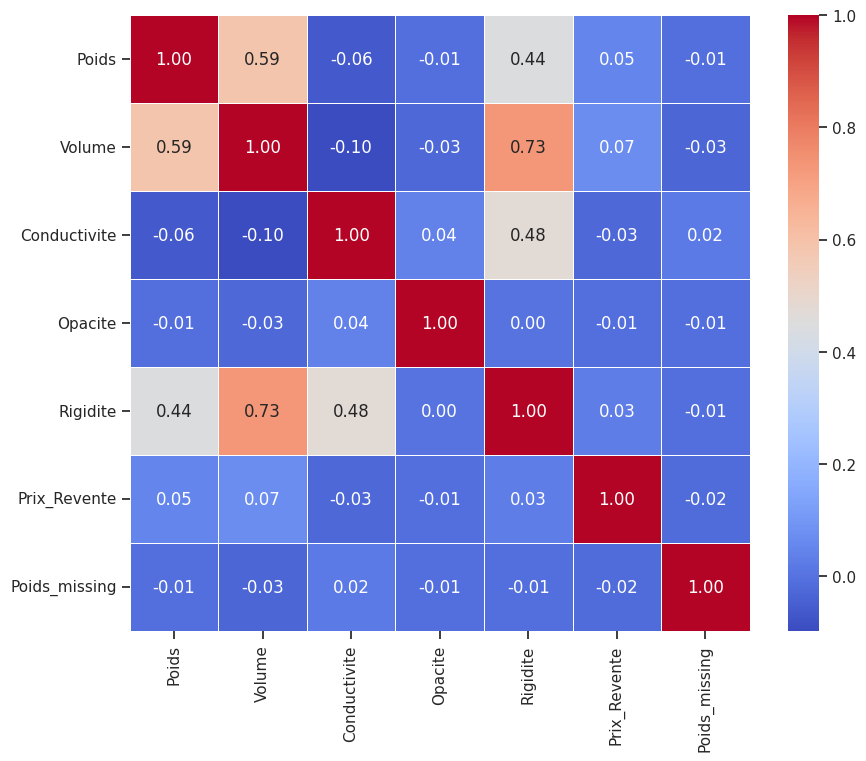

In [105]:
numeric_df = df.select_dtypes(include='number')
correlations = numeric_df.corr(method='pearson')
plt.figure(figsize=(10, 8))
sns.heatmap(correlations, annot=True, cmap='coolwarm', fmt=".2f",
linewidths=.5)

<Axes: >

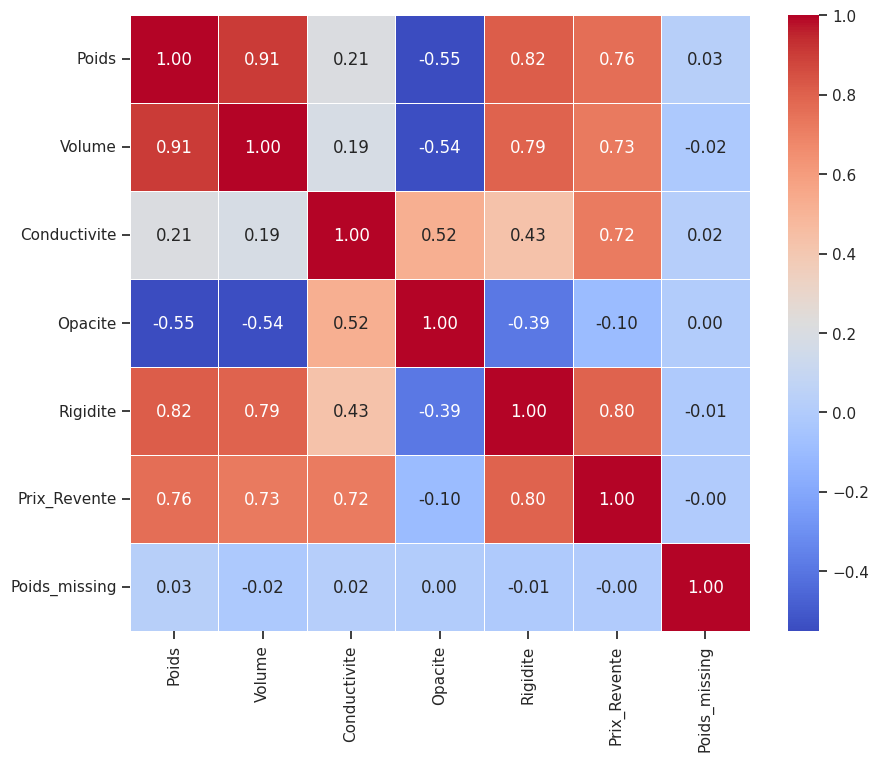

In [106]:
numeric_df = df.select_dtypes(include='number')
correlations = numeric_df.corr(method='spearman')
plt.figure(figsize=(10, 8))
sns.heatmap(correlations, annot=True, cmap='coolwarm', fmt=".2f",
linewidths=.5)

<Axes: >

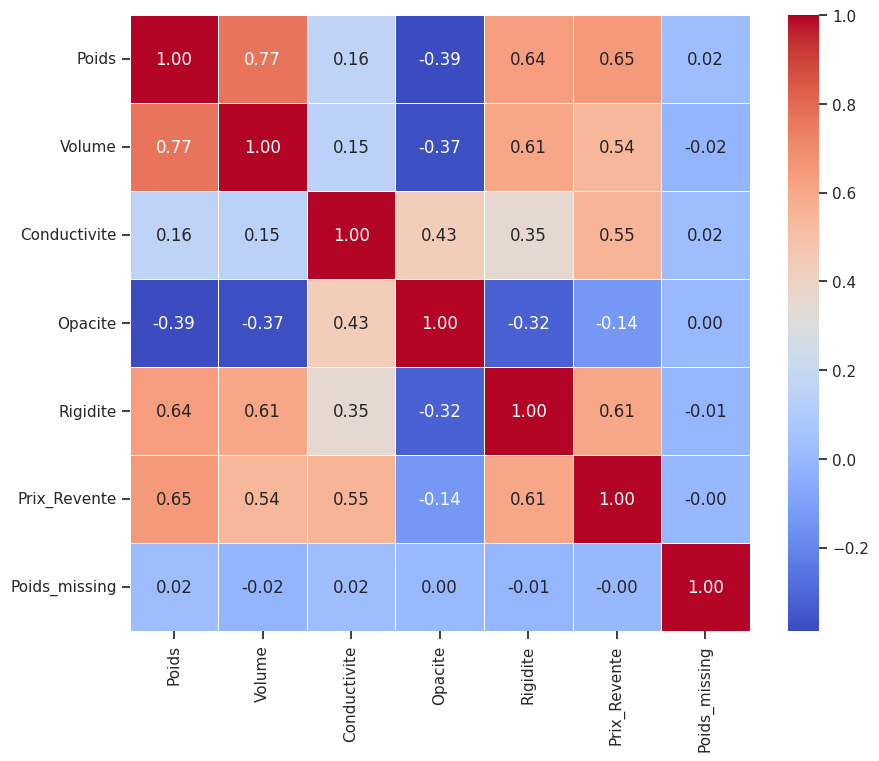

In [107]:
numeric_df = df.select_dtypes(include='number')
correlations = numeric_df.corr(method='kendall')
plt.figure(figsize=(10, 8))
sns.heatmap(correlations, annot=True, cmap='coolwarm', fmt=".2f",
linewidths=.5)

=> Dans ce travail, nous avons utilisé plusieurs méthodes de corrélation pour analyser les relations entre les variables.
La corrélation de Pearson permet de mesurer les relations linéaires entre les variables numériques.
La corrélation de Spearman est utilisée pour détecter des relations même non linéaires et elle est plus robuste face aux valeurs aberrantes.
Enfin, la corrélation de Kendall, plus précise mais plus lente, peut être utilisée pour confirmer les résultats.
Ces méthodes permettent de mieux comprendre les liens entre les variables.

### Etape 13 : Traiter les outliers

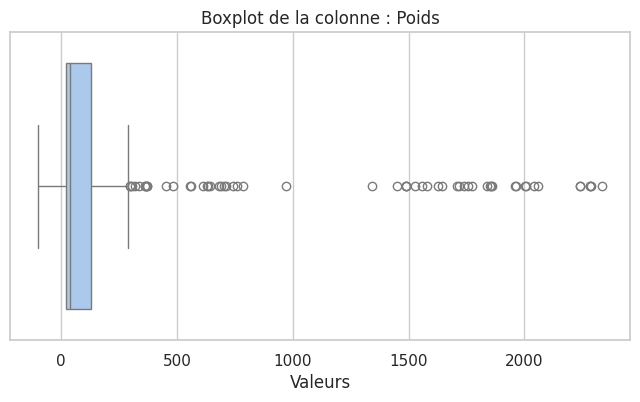

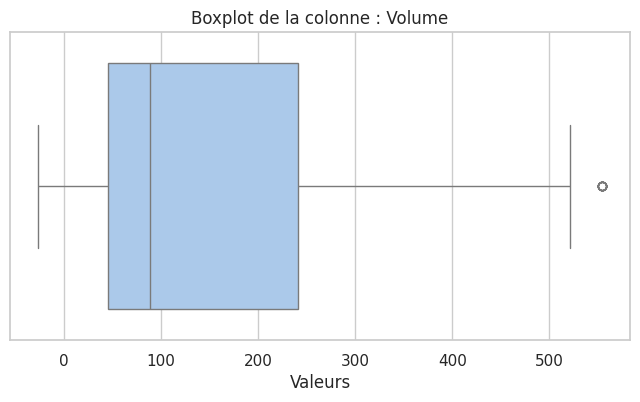

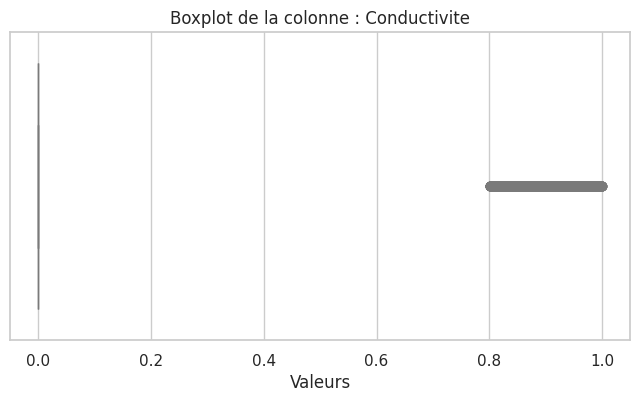

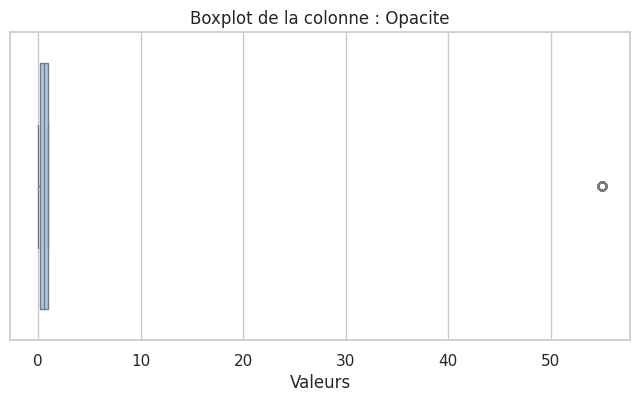

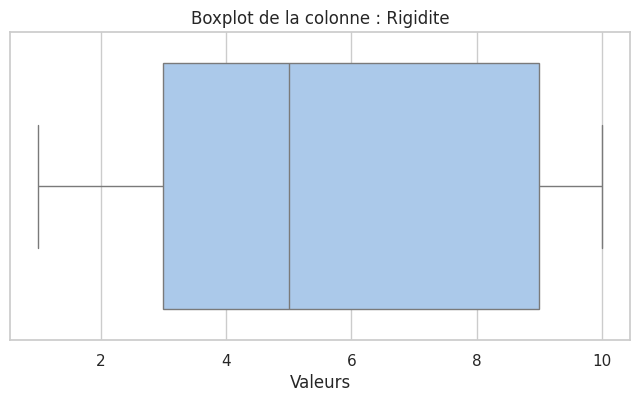

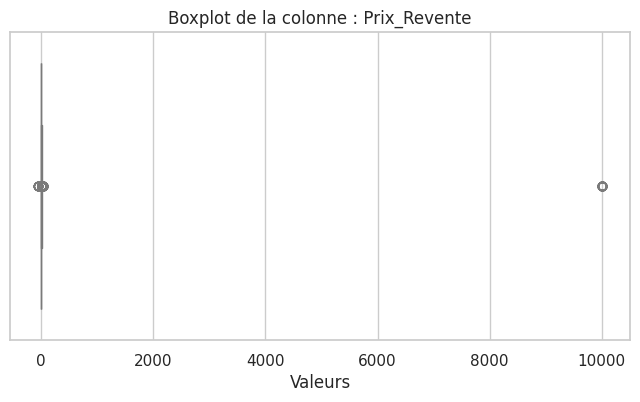

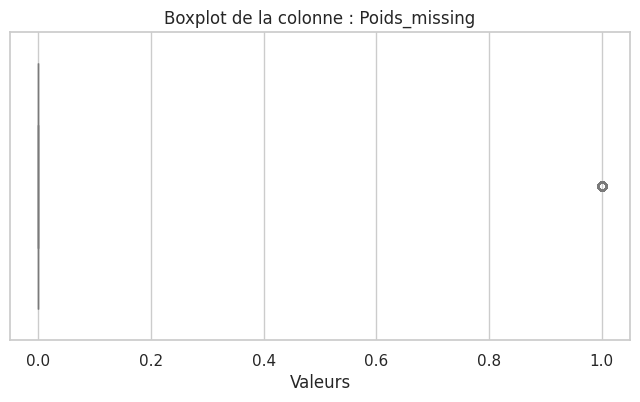

In [108]:
import seaborn as sns
import matplotlib.pyplot as plt
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
sns.set(style='whitegrid')
for col in numeric_cols:
 plt.figure(figsize=(8, 4)) # Ajuster la taille de chaque figure
 sns.boxplot(data=df, x=col, orient='h', palette='pastel') # Boxplot horizontal
 plt.title(f"Boxplot de la colonne : {col}")
 plt.xlabel("Valeurs")
 plt.show()

- Traiter les valeurs outilers par la méthode de Quartile

In [109]:
df.Categorie.value_counts()

,count
Categorie,
Plastique,2562
Verre,2384
Métal,2163
Papier,2104


In [110]:
import pandas as pd

numeric_cols = ["Poids", "Volume", "Conductivite", "Opacite", "Prix_Revente"]


outliers_summary = []

for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    nb_outliers = outliers.shape[0]

    percentage = (nb_outliers / len(df)) * 100

    outliers_summary.append({
        "Feature": col,
        "Nb_Outliers": nb_outliers,
        "Percentage": round(percentage, 2)
    })

outliers_df = pd.DataFrame(outliers_summary)

print(outliers_df)

        Feature  Nb_Outliers  Percentage
0         Poids           57        0.62
1        Volume           10        0.11
2  Conductivite         2163       23.48
3       Opacite           86        0.93
4  Prix_Revente         1669       18.12


Puisque on a Conductivite et Prix_Revente avec des pourcentage d'outliers très élevé donc on ne dois pas supprimer les lignes qui contient les outliers

In [111]:
cols = ["Conductivite", "Prix_Revente"]

for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    inf = Q1 - 1.5 * IQR
    sup = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower=inf, upper=sup)

In [112]:
import numpy as np

cols = ["Poids", "Volume", "Opacite"]

for col in cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    median = df[col].median()

    # remplacer outliers par la médiane
    df.loc[(df[col] < lower) | (df[col] > upper), col] = median

In [113]:
df.Categorie.value_counts()

,count
Categorie,
Plastique,2562
Verre,2384
Métal,2163
Papier,2104


- vérifier la modification des VA

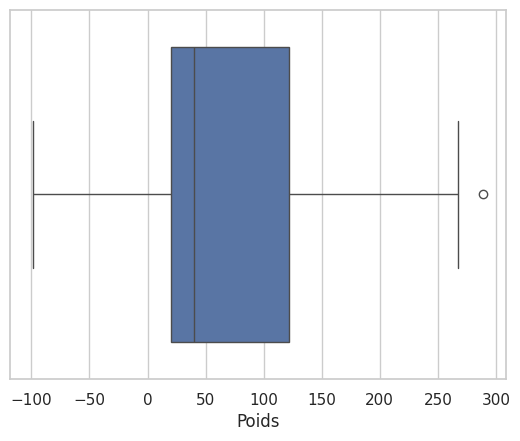

In [114]:
sns.set(style='whitegrid')
ax=sns.boxplot(data=df['Poids'] ,orient='h')

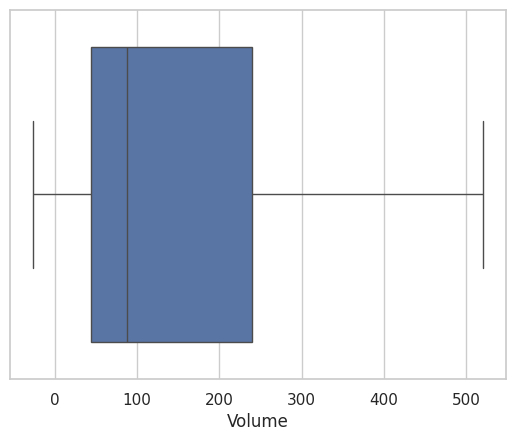

In [115]:
sns.set(style='whitegrid')
ax=sns.boxplot(data=df['Volume'] ,orient='h')

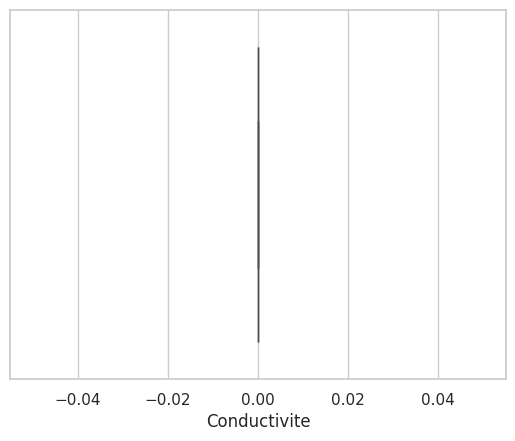

In [116]:
sns.set(style='whitegrid')
ax=sns.boxplot(data=df['Conductivite'] ,orient='h')

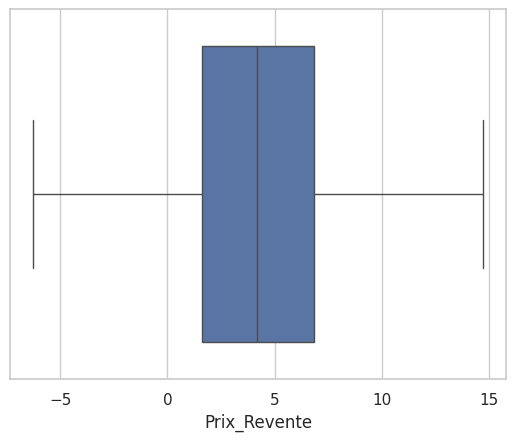

In [117]:
sns.set(style='whitegrid')
ax=sns.boxplot(data=df['Prix_Revente'] ,orient='h')

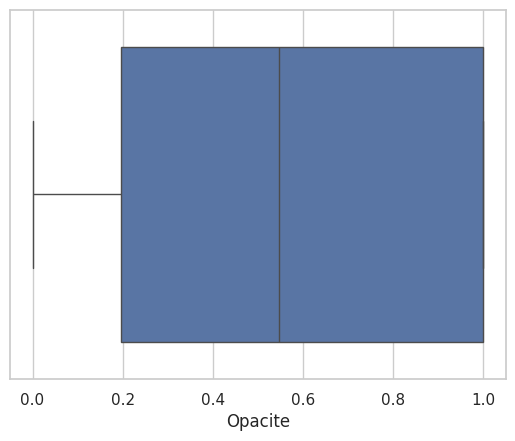

In [118]:
sns.set(style='whitegrid')
ax=sns.boxplot(data=df['Opacite'] ,orient='h')

- relation entre rigidité et volume

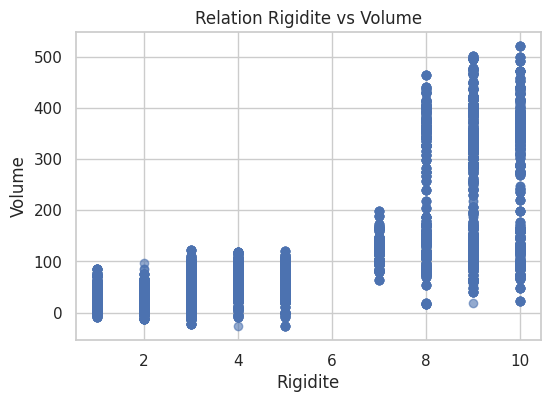

In [119]:
plt.figure(figsize=(6,4))
plt.scatter(df['Rigidite'], df['Volume'], alpha=0.6)
plt.xlabel('Rigidite')
plt.ylabel('Volume')
plt.title('Relation Rigidite vs Volume')
plt.show()

# Plus la rigidité augmente
# plus le volume est élevé


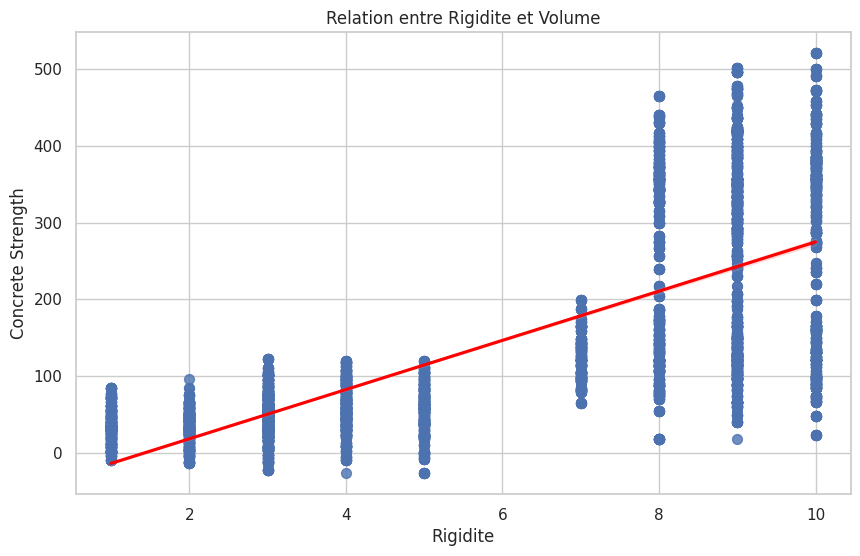

In [120]:
plt.figure(figsize=(10, 6))
sns.regplot(x='Rigidite', y='Volume', data=df, scatter_kws={'s': 50}, line_kws={'color': 'red'})
plt.title('Relation entre Rigidite et Volume')
plt.xlabel('Rigidite')
plt.ylabel('Concrete Strength')
plt.grid(True)
plt.show()

-  relation entre Poids et volume

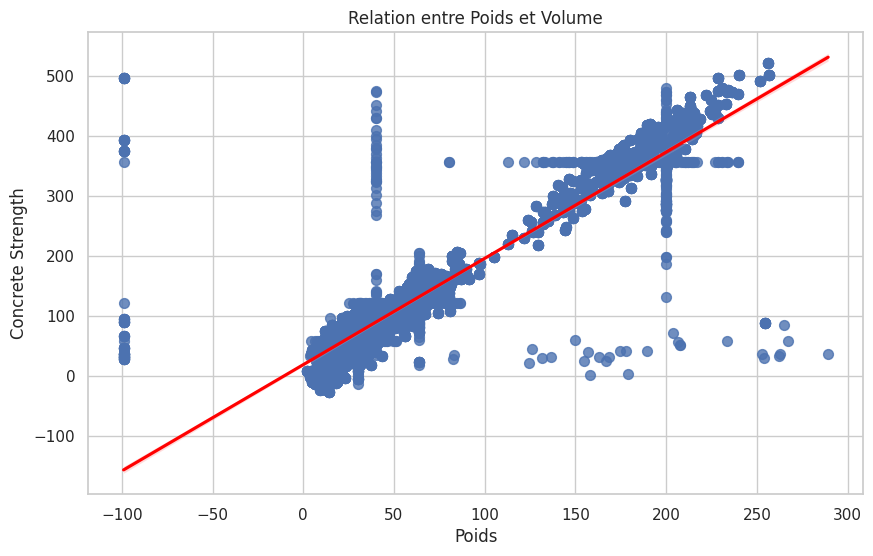

In [121]:
plt.figure(figsize=(10, 6))
sns.regplot(x='Poids', y='Volume', data=df, scatter_kws={'s': 50}, line_kws={'color': 'red'})
plt.title('Relation entre Poids et Volume')
plt.xlabel('Poids')
plt.ylabel('Concrete Strength')
plt.grid(True)
plt.show()

- Les Relations entre les variables avec pairplot

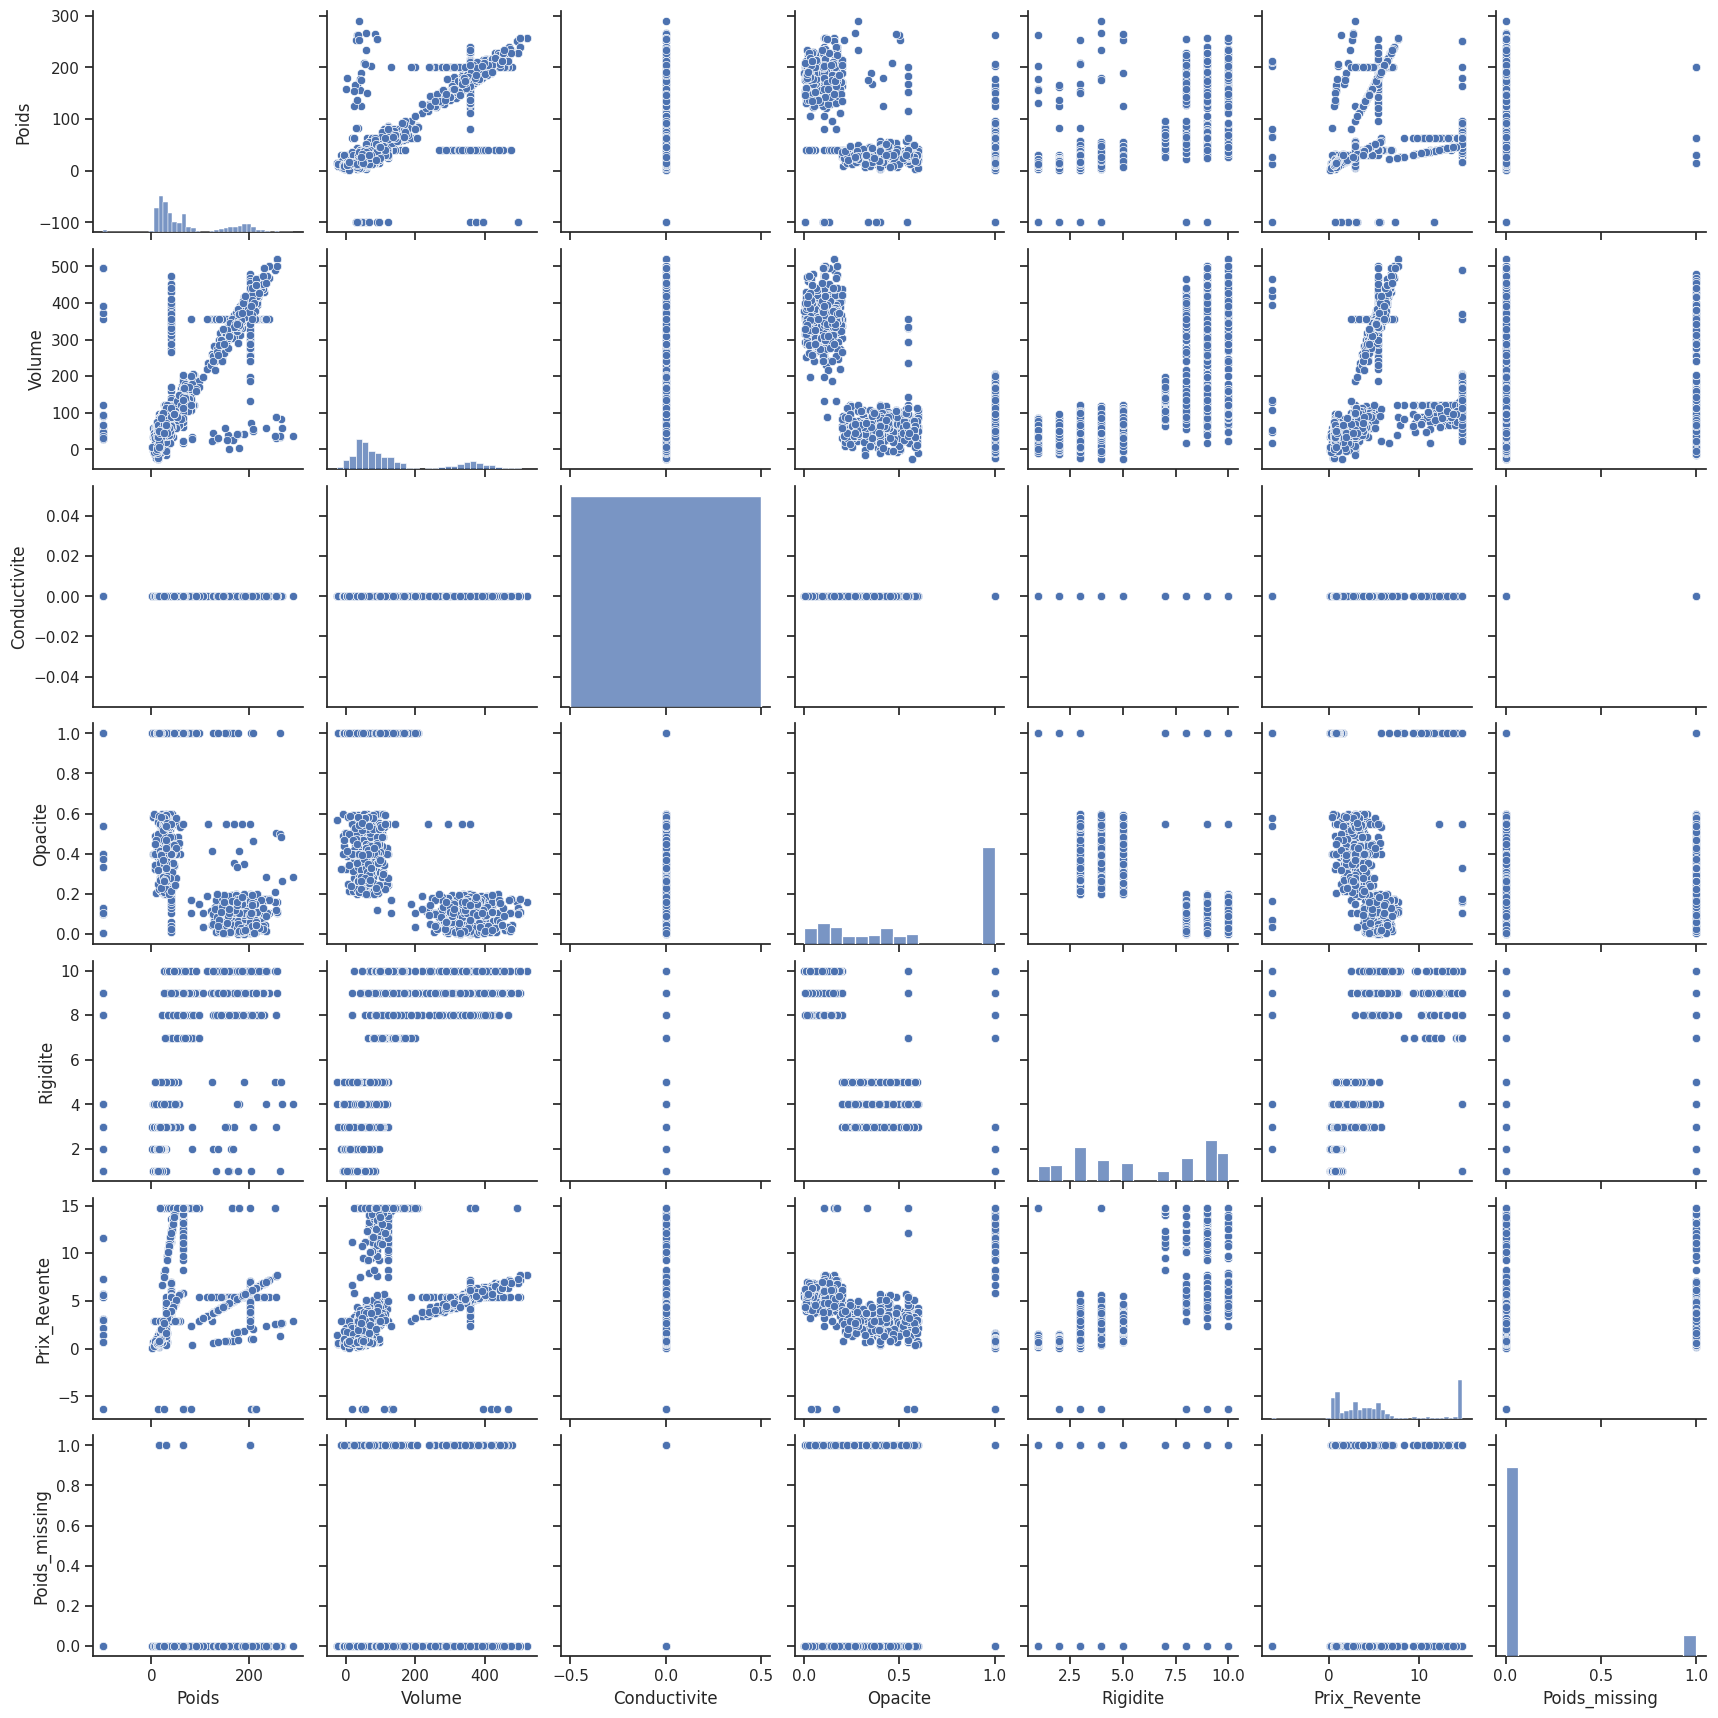

In [122]:
sns.set(style='ticks')
sns.pairplot(df)

### Etape 14 : Séparation des variables

- Pour Classification

In [123]:
Y_class = df['Categorie']
X_class = df.drop(['Categorie', 'Rapport_Collecte','Poids_missing'], axis=1)  # garde le DataFrame (pas .values)
print("Cible Y :")
print(Y_class)
print("\nEntrées X :")
print(X_class)

Cible Y :
0          Papier
1       Plastique
2           Verre
3          Papier
4          Papier
          ...    
9719        Verre
9720        Verre
9721       Papier
9722    Plastique
9723        Verre
Name: Categorie, Length: 9213, dtype: object

Entrées X :
           Poids      Volume  Conductivite   Opacite  Rigidite  Prix_Revente  \
0      16.708780   70.940977           0.0  1.000000       1.0      0.835439   
1      47.277476   64.702925           0.0  0.400606       3.0      4.727748   
2     200.203552  317.415183           0.0  0.105535       9.0      4.211790   
3      14.664058   21.474391           0.0  1.000000       1.0      0.442067   
4      14.664058   59.462176           0.0  1.000000       2.0      0.723004   
...          ...         ...           ...       ...       ...           ...   
9719  191.018619  418.800912           0.0  0.019307       9.0      5.730559   
9720  149.052713  287.519460           0.0  0.157940      10.0      4.471581   
9721   15.5726

In [124]:
print(type(X_class))
print(X_class.columns)

<class 'pandas.core.frame.DataFrame'>
Index(['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite',
       'Prix_Revente', 'Source'],
      dtype='object')


- Pour Regression

In [125]:
X_regg = df.drop(["Prix_Revente", "Rapport_Collecte","Poids_missing"], axis=1)
Y_regg = df["Prix_Revente"]
print("Cible Y :")
print(Y_regg)
print("\nEntrées X :")
print(X_regg)

Cible Y :
0       0.835439
1       4.727748
2       4.211790
3       0.442067
4       0.723004
          ...   
9719    5.730559
9720    4.471581
9721    0.778633
9722    2.670726
9723    4.400482
Name: Prix_Revente, Length: 9213, dtype: float64

Entrées X :
           Poids      Volume  Conductivite   Opacite  Rigidite  Categorie  \
0      16.708780   70.940977           0.0  1.000000       1.0     Papier   
1      47.277476   64.702925           0.0  0.400606       3.0  Plastique   
2     200.203552  317.415183           0.0  0.105535       9.0      Verre   
3      14.664058   21.474391           0.0  1.000000       1.0     Papier   
4      14.664058   59.462176           0.0  1.000000       2.0     Papier   
...          ...         ...           ...       ...       ...        ...   
9719  191.018619  418.800912           0.0  0.019307       9.0      Verre   
9720  149.052713  287.519460           0.0  0.157940      10.0      Verre   
9721   15.572667   50.148243           0.0  1.00

In [126]:
print(type(X_regg))
print(X_regg.columns)

<class 'pandas.core.frame.DataFrame'>
Index(['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite', 'Categorie',
       'Source'],
      dtype='object')


### 15- afficher un echontillion de X et Y

In [127]:
print('Echantillon de X :')
print(X_class.iloc[np.random.choice(len(X_class), 5)])
print('\nEchantillon de Y :')
print(Y_class.iloc[np.random.choice(len(Y_class), 5)])

Echantillon de X :
          Poids      Volume  Conductivite   Opacite  Rigidite  Prix_Revente  \
5230  25.016376   69.886523           0.0  0.269505       3.0      2.501638   
6505   4.579435   43.652804           0.0  1.000000       2.0      0.228972   
6981  42.879825   77.303410           0.0  0.281614       4.0      4.287982   
8684  63.649699  127.873693           0.0  1.000000       7.0     14.740230   
9648  13.191774   65.741526           0.0  1.000000       2.0      0.659589   

                  Source  
5230  Collecte_Citoyenne  
6505  Collecte_Citoyenne  
6981  Collecte_Citoyenne  
8684          Centre_Tri  
9648  Collecte_Citoyenne  

Echantillon de Y :
6109        Verre
7797       Papier
2384    Plastique
7642       Papier
1513        Métal
Name: Categorie, dtype: object


Ce code permet d’afficher un **échantillon aléatoire de 5 lignes** des données d’entrée `X_class` et de la variable cible `Y_class`.
Il sert à vérifier rapidement et visuellement un petit aperçu des features et des labels pour s’assurer que les données sont bien chargées et cohérentes avant l’entraînement du modèle.


In [128]:
print('Echantillon de X :')
print(X_regg.iloc[np.random.choice(len(X_regg), 5)])
print('\nEchantillon de Y :')
print(Y_regg.iloc[np.random.choice(len(Y_regg), 5)])

Echantillon de X :
           Poids      Volume  Conductivite   Opacite  Rigidite  Categorie  \
4994   30.965453   31.934167           0.0  0.400606       3.0  Plastique   
5748   56.030360   84.799153           0.0  1.000000      10.0      Métal   
3876   69.402505  142.534769           0.0  1.000000       8.0      Métal   
7247  168.025446  356.731790           0.0  0.159509       8.0      Verre   
2212  214.462971  394.131666           0.0  0.032705      10.0      Verre   

                  Source  
4994             Usine_B  
5748             Usine_B  
3876  Collecte_Citoyenne  
7247             Usine_B  
2212          Centre_Tri  

Echantillon de Y :
1399     4.965531
6105     3.886330
7960    14.740230
9447    14.740230
3687     7.188355
Name: Prix_Revente, dtype: float64


### Etape 15 : categorisation

In [129]:
# Encoder la cible Y
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
Y_class = le.fit_transform(Y_class.astype(str))  # astype(str) gère les NaN

In [130]:
print(Y_class)

[1 2 3 ... 1 2 3]


In [131]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Trouver l'index de 'Source' dans X_class
source_idx = X_class.columns.get_loc('Source')

ct = ColumnTransformer(
    [('Source', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), [source_idx])],
    remainder='passthrough'
)
X_class = ct.fit_transform(X_class)

In [132]:
print(X_class)

[[0.00000000e+00 1.00000000e+00 0.00000000e+00 ... 1.00000000e+00
  1.00000000e+00 8.35438994e-01]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00 ... 4.00606185e-01
  3.00000000e+00 4.72774763e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 1.05535493e-01
  9.00000000e+00 4.21179011e+00]
 ...
 [0.00000000e+00 1.00000000e+00 0.00000000e+00 ... 1.00000000e+00
  2.00000000e+00 7.78633342e-01]
 [0.00000000e+00 1.00000000e+00 0.00000000e+00 ... 2.66208204e-01
  4.00000000e+00 2.67072629e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 5.07727113e-03
  9.00000000e+00 4.40048174e+00]]


In [133]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

ct = ColumnTransformer(
    transformers=[
        ('Source', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), ['Source']),
        ('Categorie', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), ['Categorie'])
    ],
    remainder='passthrough'
)


X_regg = ct.fit_transform(X_regg)

In [134]:
print(X_regg)

[[0.00000000e+00 1.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  1.00000000e+00 1.00000000e+00]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00 ... 0.00000000e+00
  4.00606185e-01 3.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  1.05535493e-01 9.00000000e+00]
 ...
 [0.00000000e+00 1.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  1.00000000e+00 2.00000000e+00]
 [0.00000000e+00 1.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  2.66208204e-01 4.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  5.07727113e-03 9.00000000e+00]]


### Etape 16 : Transformer X et Y en tableau numpy

- Classification

In [135]:
X_class = np.array(X_class, dtype=float)
Y_class = np.array(Y_class)


print("Shape de X après encodage :", X_class.shape)
print("Shape de Y :", Y_class.shape)

Shape de X après encodage : (9213, 10)
Shape de Y : (9213,)


- Regression

In [136]:
X_regg = np.array(X_regg, dtype=float)
Y_regg = np.array(Y_regg)

print("Shape de X après encodage :", X_regg.shape)
print("Shape de Y :", Y_regg.shape)

Shape de X après encodage : (9213, 13)
Shape de Y : (9213,)


- Vérifier cette transformation

In [137]:
X_class[0:10,:]

array([[0.00000000e+00, 1.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        1.67087799e+01, 7.09409765e+01, 0.00000000e+00, 1.00000000e+00,
        1.00000000e+00, 8.35438994e-01],
       [0.00000000e+00, 0.00000000e+00, 1.00000000e+00, 0.00000000e+00,
        4.72774763e+01, 6.47029253e+01, 0.00000000e+00, 4.00606185e-01,
        3.00000000e+00, 4.72774763e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.00000000e+00,
        2.00203552e+02, 3.17415183e+02, 0.00000000e+00, 1.05535493e-01,
        9.00000000e+00, 4.21179011e+00],
       [1.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        1.46640579e+01, 2.14743907e+01, 0.00000000e+00, 1.00000000e+00,
        1.00000000e+00, 4.42067308e-01],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.00000000e+00,
        1.46640579e+01, 5.94621756e+01, 0.00000000e+00, 1.00000000e+00,
        2.00000000e+00, 7.23003759e-01],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.00000000e+00,
   

In [138]:
X_regg[0:10,:]

array([[0.00000000e+00, 1.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 1.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        1.67087799e+01, 7.09409765e+01, 0.00000000e+00, 1.00000000e+00,
        1.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 1.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 1.00000000e+00, 0.00000000e+00,
        4.72774763e+01, 6.47029253e+01, 0.00000000e+00, 4.00606185e-01,
        3.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.00000000e+00,
        2.00203552e+02, 3.17415183e+02, 0.00000000e+00, 1.05535493e-01,
        9.00000000e+00],
       [1.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 1.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        1.46640579e+01, 2.14743907e+01, 0.00000000e+00, 1.00000000e+00,
        1.00000000e+00],
       [0.00000000e+00, 0.00000000e+

In [139]:
Y_regg

array([0.83543899, 4.72774763, 4.21179011, ..., 0.77863334, 2.67072629,
       4.40048174])

### Etape 17 : Split

- Classification

In [140]:
from sklearn.model_selection import train_test_split
import pandas as pd

# 1. Split 70/30
x_train, x_temp, y_train, y_temp = train_test_split(
    X_class,
    Y_class,
    test_size=0.30,
    random_state=0,
    stratify=Y_class
)

# 2. Split temp → 15/15
x_val, x_test, y_val, y_test = train_test_split(
    x_temp,
    y_temp,
    test_size=0.50,
    random_state=0,
    stratify=y_temp
)

# Shapes
print("x_train:", x_train.shape)
print("x_val:", x_val.shape)
print("x_test:", x_test.shape)

print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

# Distribution check
print("\nDistribution y_train:\n", pd.Series(y_train).value_counts(normalize=True))
print("\nDistribution y_val:\n", pd.Series(y_val).value_counts(normalize=True))
print("\nDistribution y_test:\n", pd.Series(y_test).value_counts(normalize=True))

x_train: (6449, 10)
x_val: (1382, 10)
x_test: (1382, 10)
y_train: (6449,)
y_val: (1382,)
y_test: (1382,)

Distribution y_train:
 2    0.278028
3    0.258800
0    0.234765
1    0.228408
Name: proportion, dtype: float64

Distribution y_val:
 2    0.277858
3    0.259045
0    0.234443
1    0.228654
Name: proportion, dtype: float64

Distribution y_test:
 2    0.278582
3    0.258321
0    0.235166
1    0.227931
Name: proportion, dtype: float64


- Regression

In [144]:
from sklearn.model_selection import train_test_split

x_train_reg, x_temp_reg, y_train_reg, y_temp_reg = train_test_split(
    X_regg,
    Y_regg,
    test_size=0.30,
    random_state=0
)

x_val_reg, x_test_reg, y_val_reg, y_test_reg = train_test_split(
    x_temp_reg,
    y_temp_reg,
    test_size=0.50,
    random_state=0
)

# Shapes
print("X_train:", x_train_reg.shape)
print("X_val:", x_val_reg.shape)
print("X_test:", x_test_reg.shape)

print("y_train:", y_train_reg.shape)
print("y_val:", y_val_reg.shape)
print("y_test:", y_test_reg.shape)

# Mean check (régression OK)
print("\nMean y_train:", y_train_reg.mean())
print("Mean y_val:", y_val_reg.mean())
print("Mean y_test:", y_test_reg.mean())

X_train: (6449, 13)
X_val: (1382, 13)
X_test: (1382, 13)
y_train: (6449,)
y_val: (1382,)
y_test: (1382,)

Mean y_train: 5.684667142675411
Mean y_val: 5.669557052398087
Mean y_test: 5.7082815764421415


### Etape 18 : Standarisation

- Classification

In [145]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

x_train = sc.fit_transform(x_train)
x_val = sc.transform(x_val)
x_test = sc.transform(x_test)

In [146]:
print(x_train[:5])

[[-0.54623185 -0.66416663 -0.56726295  1.87935486 -0.76019758 -0.75539935
   0.          1.02251489 -0.95221867 -0.9496586 ]
 [-0.54623185 -0.66416663  1.7628509  -0.53209749 -0.61886061 -0.48937989
   0.         -0.88608694 -0.62814573 -0.57734254]
 [-0.54623185  1.50564625 -0.56726295 -0.53209749 -0.5582246  -0.4631574
   0.         -0.55138728 -0.62814573 -0.49284316]
 [ 1.83072443 -0.66416663 -0.56726295 -0.53209749 -0.66167556 -0.65879454
   0.         -0.14038851 -0.62814573 -0.63700736]
 [-0.54623185  1.50564625 -0.56726295 -0.53209749 -0.88337367 -0.93956101
   0.          1.02251489 -1.27629161 -1.03548468]]


- Regression

In [147]:
from sklearn.preprocessing import StandardScaler

sc1 = StandardScaler()

# fit uniquement sur train
x_train_reg = sc1.fit_transform(x_train_reg)

# transform sur validation et test
x_val_reg = sc1.transform(x_val_reg)
x_test_reg = sc1.transform(x_test_reg)

In [148]:
print(x_train_reg[:5])

[[-0.54144457 -0.66659201 -0.56296424  1.85594208 -0.55245034  1.84040073
  -0.62199817 -0.59161682 -0.76993178 -0.50944066  0.          1.02509896
  -0.95188391]
 [ 1.84691113 -0.66659201 -0.56296424 -0.53880992  1.81011745 -0.54335992
  -0.62199817 -0.59161682 -0.0948793  -0.09257522  0.          1.02509896
   0.34573261]
 [-0.54144457 -0.66659201 -0.56296424  1.85594208 -0.55245034  1.84040073
  -0.62199817 -0.59161682 -0.90744289 -0.91191875  0.          1.02509896
  -1.27628804]
 [-0.54144457  1.500168   -0.56296424 -0.53880992 -0.55245034 -0.54335992
  -0.62199817  1.69028324  1.20009531  1.42306171  0.         -1.38716967
   1.31894499]
 [ 1.84691113 -0.66659201 -0.56296424 -0.53880992  1.81011745 -0.54335992
  -0.62199817 -0.59161682 -0.26271239 -0.08433916  0.          1.02509896
   0.67013673]]


# Module 2 : Modélisation

# 1 - Classification

## * Modélisation KNN et évaluation

Il faut imputer les valeurs manquantes avant le fit.

In [149]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, classification_report
import numpy as np

# --- Modèle ---
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train, y_train)

# --- Prédictions validation + test ---
y_pred_val = knn.predict(x_val)
y_pred_test = knn.predict(x_test)

# --- Conversion ---
y_val_eval = np.array(y_val).astype(int)
y_test_eval = np.array(y_test).astype(int)

y_pred_val = np.array(y_pred_val).astype(int)
y_pred_test = np.array(y_pred_test).astype(int)

# =========================
# 🔷 ÉVALUATION VALIDATION
# =========================
print("\n===== VALIDATION SET =====")
print("Confusion Matrix:\n", confusion_matrix(y_val_eval, y_pred_val))
print(f"Accuracy  : {accuracy_score(y_val_eval, y_pred_val):.4f}")
print(f"F1-score  : {f1_score(y_val_eval, y_pred_val, average='macro'):.4f}")

# =========================
# 🔷 ÉVALUATION TEST
# =========================
print("\n===== TEST SET =====")
print("Confusion Matrix:\n", confusion_matrix(y_test_eval, y_pred_test))
print(f"Accuracy  : {accuracy_score(y_test_eval, y_pred_test):.4f}")
print(f"Recall    : {recall_score(y_test_eval, y_pred_test, average='macro'):.4f}")
print(f"Precision : {precision_score(y_test_eval, y_pred_test, average='macro'):.4f}")
print(f"F1-score  : {f1_score(y_test_eval, y_pred_test, average='macro'):.4f}")
print("\nClassification Report:\n", classification_report(y_test_eval, y_pred_test))


===== VALIDATION SET =====
Confusion Matrix:
 [[324   0   0   0]
 [  3 312   1   0]
 [  0   1 380   3]
 [  0   0   0 358]]
Accuracy  : 0.9942
F1-score  : 0.9942

===== TEST SET =====
Confusion Matrix:
 [[325   0   0   0]
 [  1 313   1   0]
 [  0   0 385   0]
 [  0   0   0 357]]
Accuracy  : 0.9986
Recall    : 0.9984
Precision : 0.9986
F1-score  : 0.9985

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       325
           1       1.00      0.99      1.00       315
           2       1.00      1.00      1.00       385
           3       1.00      1.00      1.00       357

    accuracy                           1.00      1382
   macro avg       1.00      1.00      1.00      1382
weighted avg       1.00      1.00      1.00      1382



 Dataset facile (BON cas)

features très bien séparées
classes bien distinctes



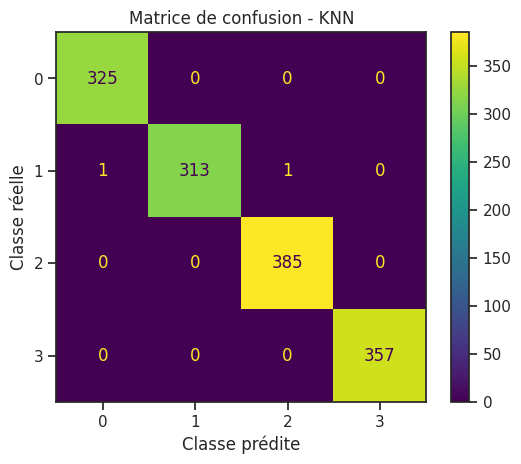

In [150]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Matrice de confusion
cm = confusion_matrix(y_test_eval, y_pred_test)

# Affichage graphique
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Matrice de confusion - KNN")
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.show()

La matrice de confusion montre que le modèle KNN obtient de très bonnes performances, avec une majorité de prédictions correctes visibles sur la diagonale principale. Les erreurs de classification sont faibles, ce qui indique une bonne capacité du modèle à distinguer les différentes classes.


# Mdélisation Grid Search et évaluation

problème multiclasse, donc il faut average='macro'

In [151]:
from sklearn.model_selection import GridSearchCV

parameters = {'n_neighbors': [1, 3, 5, 7, 9, 11, 13]}
model = KNeighborsClassifier()

clf = GridSearchCV(model, parameters, scoring='recall_macro', cv=5)
grille = clf.fit(x_train, y_train)

print("Meilleur paramètre :", grille.best_params_)
print("Meilleur score     :", grille.best_score_)

y_pred_knn_o = grille.predict(x_test)

knn_op_acc  = accuracy_score(y_test, y_pred_knn_o)
knn_op_rec  = recall_score(y_test, y_pred_knn_o, average='macro')
knn_op_prec = precision_score(y_test, y_pred_knn_o, average='macro')
knn_op_f1 = f1_score(y_test, y_pred_knn_o, average='macro')

print('\nConfusion Matrix KNN optimisé:\n', confusion_matrix(y_test, y_pred_knn_o))
print(f'Accuracy  : {knn_op_acc:.4f}')
print(f'Recall    : {knn_op_rec:.4f}')
print(f'Precision : {knn_op_prec:.4f}')
print(f'F1 - score : {knn_op_f1:.4f}')
print('\nClassification Report:\n', classification_report(y_test, y_pred_knn_o))

Meilleur paramètre : {'n_neighbors': 1}
Meilleur score     : 0.9993863639391055

Confusion Matrix KNN optimisé:
 [[325   0   0   0]
 [  0 315   0   0]
 [  0   0 385   0]
 [  0   0   0 357]]
Accuracy  : 1.0000
Recall    : 1.0000
Precision : 1.0000
F1 - score : 1.0000

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       325
           1       1.00      1.00      1.00       315
           2       1.00      1.00      1.00       385
           3       1.00      1.00      1.00       357

    accuracy                           1.00      1382
   macro avg       1.00      1.00      1.00      1382
weighted avg       1.00      1.00      1.00      1382



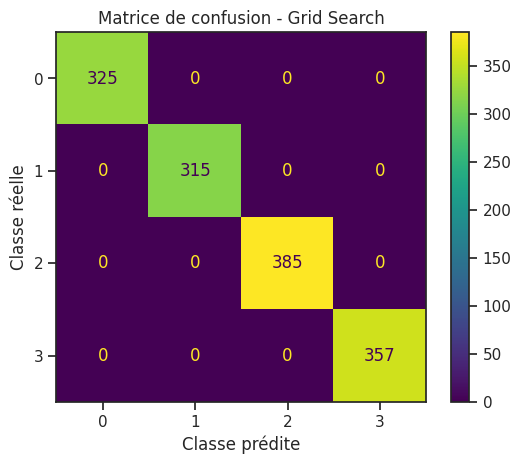

In [152]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_eval, y_pred_knn_o)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Matrice de confusion - Grid Search")
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.show()

La matrice de confusion après l’utilisation de Grid Search permet d’évaluer le modèle optimisé avec les meilleurs hyperparamètres afin de vérifier l’amélioration des performances de classification.

# Decision Tree

In [153]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, classification_report

# --- Entraînement Decision Tree ---
dt = DecisionTreeClassifier(max_depth=5, random_state=0)
dt.fit(x_train, y_train)

# --- Prédictions validation + test ---
y_pred_val = dt.predict(x_val)
y_pred_dt = dt.predict(x_test)

# --- Évaluation validation ---
print("\n===== VALIDATION SET =====")
print('Confusion Matrix:\n', confusion_matrix(y_val, y_pred_val))
print(f'Accuracy  : {accuracy_score(y_val, y_pred_val):.4f}')
print(f'F1-score  : {f1_score(y_val, y_pred_val, average="macro"):.4f}')

# --- Évaluation test ---
print("\n===== TEST SET =====")
accur_dt = accuracy_score(y_test, y_pred_dt)
rec_dt   = recall_score(y_test, y_pred_dt, average='macro')
pres_dt  = precision_score(y_test, y_pred_dt, average='macro')
dt_f1    = f1_score(y_test, y_pred_dt, average='macro')

print('Confusion Matrix DT:\n', confusion_matrix(y_test, y_pred_dt))
print(f'Accuracy  : {accur_dt:.4f}')
print(f'Recall    : {rec_dt:.4f}')
print(f'Precision : {pres_dt:.4f}')
print(f'F1-score  : {dt_f1:.4f}')
print('\nClassification Report:\n', classification_report(y_test, y_pred_dt))


===== VALIDATION SET =====
Confusion Matrix:
 [[324   0   0   0]
 [  0 316   0   0]
 [  0   0 384   0]
 [  0   0   0 358]]
Accuracy  : 1.0000
F1-score  : 1.0000

===== TEST SET =====
Confusion Matrix DT:
 [[325   0   0   0]
 [  0 315   0   0]
 [  0   0 385   0]
 [  0   0   0 357]]
Accuracy  : 1.0000
Recall    : 1.0000
Precision : 1.0000
F1-score  : 1.0000

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       325
           1       1.00      1.00      1.00       315
           2       1.00      1.00      1.00       385
           3       1.00      1.00      1.00       357

    accuracy                           1.00      1382
   macro avg       1.00      1.00      1.00      1382
weighted avg       1.00      1.00      1.00      1382



Parce que Decision Tree simple :
ne nécessite pas de validation obligatoire
pas de tuning automatique ici
donc on saute x_val

Confusion Matrix DT:


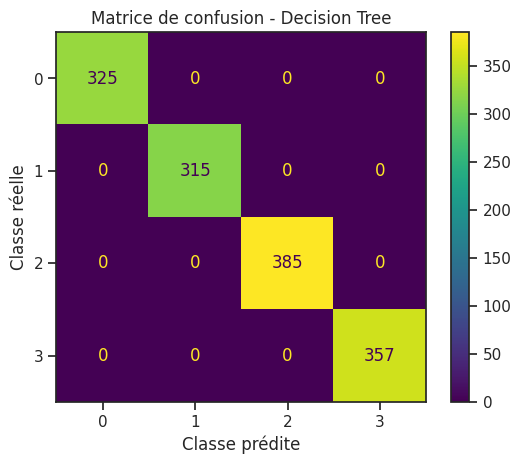

In [154]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_eval, y_pred_dt)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Matrice de confusion - Decision Tree")
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.show()


La matrice de confusion du modèle Decision Tree permet de visualiser les prédictions correctes et les erreurs de classification afin d’évaluer les performances de l’arbre de décision.

## Importance des features

# Random Forest

In [155]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, classification_report

# --- Entraînement Random Forest ---
rf = RandomForestClassifier(n_estimators=500, random_state=0)
rf.fit(x_train, y_train)

# --- Prédictions validation + test ---
y_pred_val = rf.predict(x_val)
y_pred_rf = rf.predict(x_test)

# --- Évaluation validation ---
print("\n===== VALIDATION SET =====")
print('Confusion Matrix:\n', confusion_matrix(y_val, y_pred_val))
print(f'Accuracy  : {accuracy_score(y_val, y_pred_val):.4f}')
print(f'F1-score  : {f1_score(y_val, y_pred_val, average="macro"):.4f}')

# --- Évaluation test ---
print("\n===== TEST SET =====")
rf_acc  = accuracy_score(y_test, y_pred_rf)
rf_rec  = recall_score(y_test, y_pred_rf, average='macro')
rf_prec = precision_score(y_test, y_pred_rf, average='macro')
rf_f1   = f1_score(y_test, y_pred_rf, average='macro')

print('Confusion Matrix RF:\n', confusion_matrix(y_test, y_pred_rf))
print(f'Accuracy  : {rf_acc:.4f}')
print(f'Recall    : {rf_rec:.4f}')
print(f'Precision : {rf_prec:.4f}')
print(f'F1-score  : {rf_f1:.4f}')
print('\nClassification Report:\n', classification_report(y_test, y_pred_rf))


===== VALIDATION SET =====
Confusion Matrix:
 [[324   0   0   0]
 [  0 316   0   0]
 [  0   0 384   0]
 [  0   0   0 358]]
Accuracy  : 1.0000
F1-score  : 1.0000

===== TEST SET =====
Confusion Matrix RF:
 [[325   0   0   0]
 [  0 315   0   0]
 [  0   0 385   0]
 [  0   0   0 357]]
Accuracy  : 1.0000
Recall    : 1.0000
Precision : 1.0000
F1-score  : 1.0000

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       325
           1       1.00      1.00      1.00       315
           2       1.00      1.00      1.00       385
           3       1.00      1.00      1.00       357

    accuracy                           1.00      1382
   macro avg       1.00      1.00      1.00      1382
weighted avg       1.00      1.00      1.00      1382



Confusion Matrix RF:


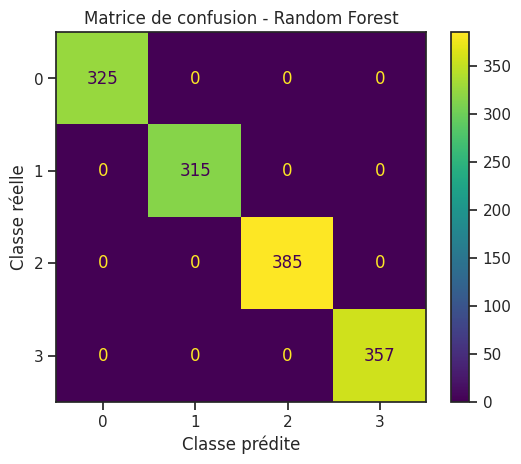

In [156]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_eval, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Matrice de confusion - Random Forest")
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.show()

Cette matrice de confusion montre la qualité des prédictions du modèle Random Forest et permet d’analyser les classes correctement reconnues ainsi que les erreurs éventuelles.

# SVM linéaire

In [157]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report, f1_score

# === Modèle SVM ===
linear_SVM = SVC(kernel='linear')
linear_SVM.fit(x_train, y_train)

# --- Prédictions validation + test ---
y_pred_val = linear_SVM.predict(x_val)
y_predictSVM_l = linear_SVM.predict(x_test)

# --- Évaluation validation ---
print("\n===== VALIDATION SET =====")
print(confusion_matrix(y_val, y_pred_val))
print('Accuracy validation:', accuracy_score(y_val, y_pred_val))
print('F1 validation:', f1_score(y_val, y_pred_val, average='macro'))

# --- Évaluation test ---
svm_acc  = accuracy_score(y_test, y_predictSVM_l)
svm_prec = precision_score(y_test, y_predictSVM_l, average='macro')
svm_rec  = recall_score(y_test, y_predictSVM_l, average='macro')
svm_f1   = f1_score(y_test, y_predictSVM_l, average='macro')

print("\n===== TEST SET =====")
print(confusion_matrix(y_test, y_predictSVM_l))
print('Accuracy linear SVM {0:.3f}'.format(svm_acc))
print('Precision linear SVM {0:.3f}'.format(svm_prec))
print('Recall linear SVM {0:.3f}'.format(svm_rec))
print('Score-F1 : {0:.4f}'.format(svm_f1))
print(classification_report(y_test, y_predictSVM_l))


===== VALIDATION SET =====
[[324   0   0   0]
 [  0 316   0   0]
 [  0   0 384   0]
 [  0   0   0 358]]
Accuracy validation: 1.0
F1 validation: 1.0

===== TEST SET =====
[[325   0   0   0]
 [  0 312   3   0]
 [  0   0 385   0]
 [  0   0   0 357]]
Accuracy linear SVM 0.998
Precision linear SVM 0.998
Recall linear SVM 0.998
Score-F1 : 0.9978
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       325
           1       1.00      0.99      1.00       315
           2       0.99      1.00      1.00       385
           3       1.00      1.00      1.00       357

    accuracy                           1.00      1382
   macro avg       1.00      1.00      1.00      1382
weighted avg       1.00      1.00      1.00      1382



SVM ici = modèle simple
pas de tuning (GridSearchCV)
donc validation set n’est pas obligatoir

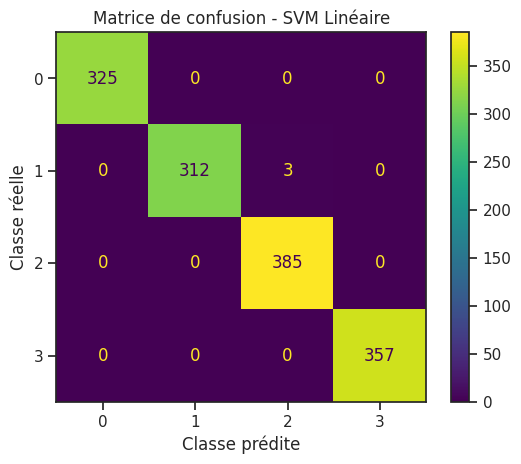

In [158]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_eval, y_predictSVM_l)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Matrice de confusion - SVM Linéaire")
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.show()

La matrice de confusion du SVM linéaire permet de mesurer l’efficacité du modèle dans la séparation des différentes classes et d’identifier les erreurs de classification.

# Logistic Regression

In [159]:
from sklearn.linear_model import LogisticRegression
LR = LogisticRegression()
LR.fit(x_train,y_train)

LogisticRegression()

In [160]:
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score
y_pred_val = LR.predict(x_val)
y_predictLR = LR.predict(x_test)

# --- Évaluation validation ---
print("\n===== VALIDATION SET =====")
print(confusion_matrix(y_val, y_pred_val))
print('Accuracy validation:', accuracy_score(y_val, y_pred_val))
print('F1 validation:', f1_score(y_val, y_pred_val, average='macro'))

# --- Évaluation test ---
LR_acc  = accuracy_score(y_test, y_predictLR)
LR_prec = precision_score(y_test, y_predictLR, average='macro')
LR_rec  = recall_score(y_test, y_predictLR, average='macro')
LR_f1   = f1_score(y_test, y_predictLR, average='macro')

print("\n===== TEST SET =====")
print(confusion_matrix(y_test, y_predictLR))
print('Accuracy Logistic Regression {0:.3f}'.format(LR_acc))
print('Precision Logistic Regression {0:.3f}'.format(LR_prec))
print('Recall Logistic Regression {0:.3f}'.format(LR_rec))
print('F1-Score Logistic Regression {0:.3f}'.format(LR_f1))
print(classification_report(y_test, y_predictLR))


===== VALIDATION SET =====
[[324   0   0   0]
 [  0 316   0   0]
 [  0   0 383   1]
 [  0   0   0 358]]
Accuracy validation: 0.9992764109985528
F1 validation: 0.9993253797239331

===== TEST SET =====
[[325   0   0   0]
 [  0 312   3   0]
 [  0   0 385   0]
 [  0   0   0 357]]
Accuracy Logistic Regression 0.998
Precision Logistic Regression 0.998
Recall Logistic Regression 0.998
F1-Score Logistic Regression 0.998
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       325
           1       1.00      0.99      1.00       315
           2       0.99      1.00      1.00       385
           3       1.00      1.00      1.00       357

    accuracy                           1.00      1382
   macro avg       1.00      1.00      1.00      1382
weighted avg       1.00      1.00      1.00      1382



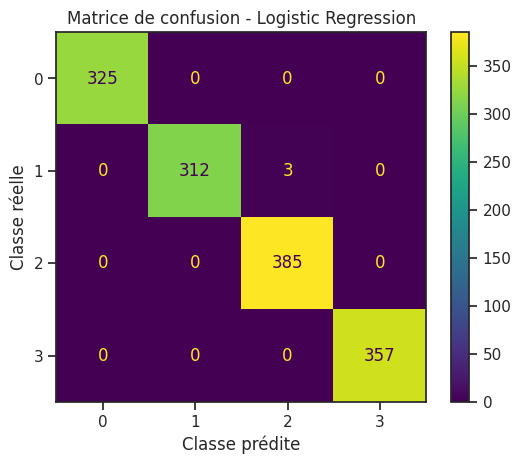

In [161]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_eval, y_predictLR)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Matrice de confusion - Logistic Regression")
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.show()

- Courbe ROC=Receiver Operating Characteristic

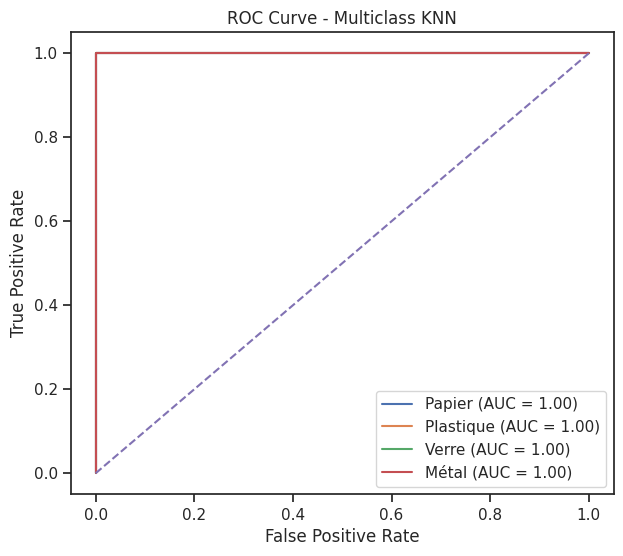

In [162]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

classes = np.unique(y_test)

y_test_bin = label_binarize(y_test, classes=classes)

# probabilités du modèle
y_score = knn.predict_proba(x_test)


plt.figure(figsize=(7,6))

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)

    class_names = ["Papier", "Plastique", "Verre", "Métal"]
    plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Multiclass KNN")

plt.legend()
plt.show()

La courbe ROC aide à voir si le modèle distingue bien les classes. Plus la courbe est proche du coin supérieur gauche, meilleur est le modèle.

# Sommary

- Représentation Graphiques des métriques de chaque modèles

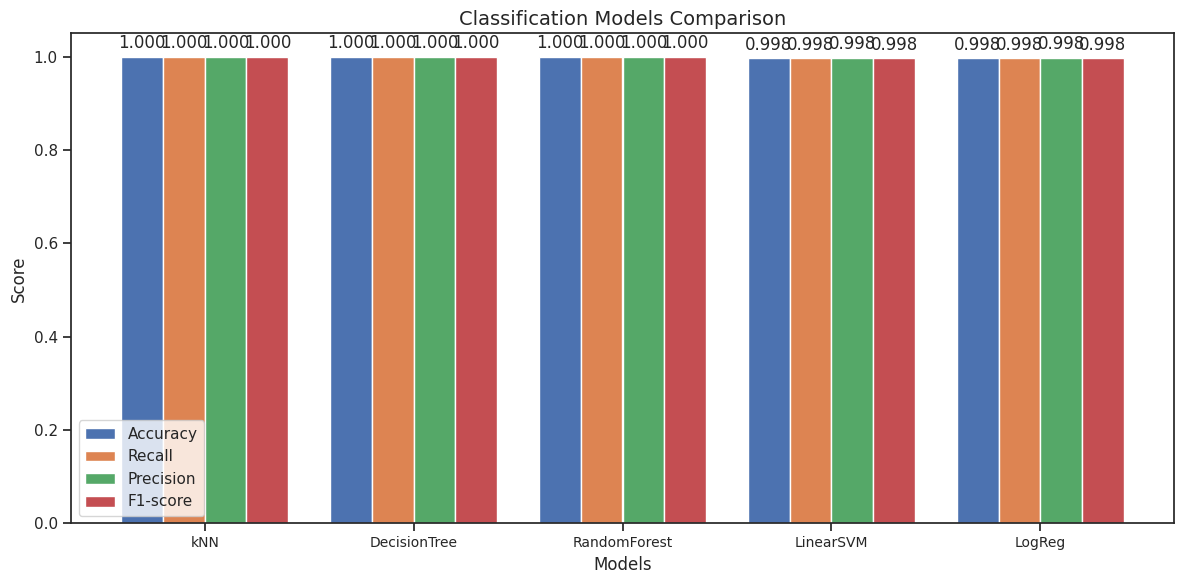

In [163]:
import numpy as np
import matplotlib.pyplot as plt

models = ["kNN", "DecisionTree", "RandomForest", "LinearSVM", "LogReg"]

accuracy = [knn_op_acc, accur_dt, rf_acc, svm_acc, LR_acc]
recall = [knn_op_rec, rec_dt, rf_rec, svm_rec, LR_rec]
precision = [knn_op_prec, pres_dt, rf_prec, svm_prec, LR_prec]
f1 = [knn_op_f1, dt_f1, rf_f1, svm_f1, LR_f1]

x = np.arange(len(models))
width = 0.2

fig, ax = plt.subplots(figsize=(12,6))

b1 = ax.bar(x - 1.5*width, accuracy, width, label='Accuracy')
b2 = ax.bar(x - 0.5*width, recall, width, label='Recall')
b3 = ax.bar(x + 0.5*width, precision, width, label='Precision')
b4 = ax.bar(x + 1.5*width, f1, width, label='F1-score')

# labels on bars (safe version)
ax.bar_label(b1, fmt='%.3f', padding=3)
ax.bar_label(b2, fmt='%.3f', padding=3)
ax.bar_label(b3, fmt='%.3f', padding=3)
ax.bar_label(b4, fmt='%.3f', padding=3)

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=10)
ax.set_xlabel("Models")
ax.set_ylabel("Score")
ax.set_title("Classification Models Comparison", fontsize=14)
ax.legend()

plt.tight_layout()
plt.show()

Ce deuxième code (barplot) représente les mêmes métriques sous forme de barres pour chaque modèle. Il affiche également les valeurs au-dessus de chaque barre afin de rendre la lecture des performances plus précise et claire.

- heatmap

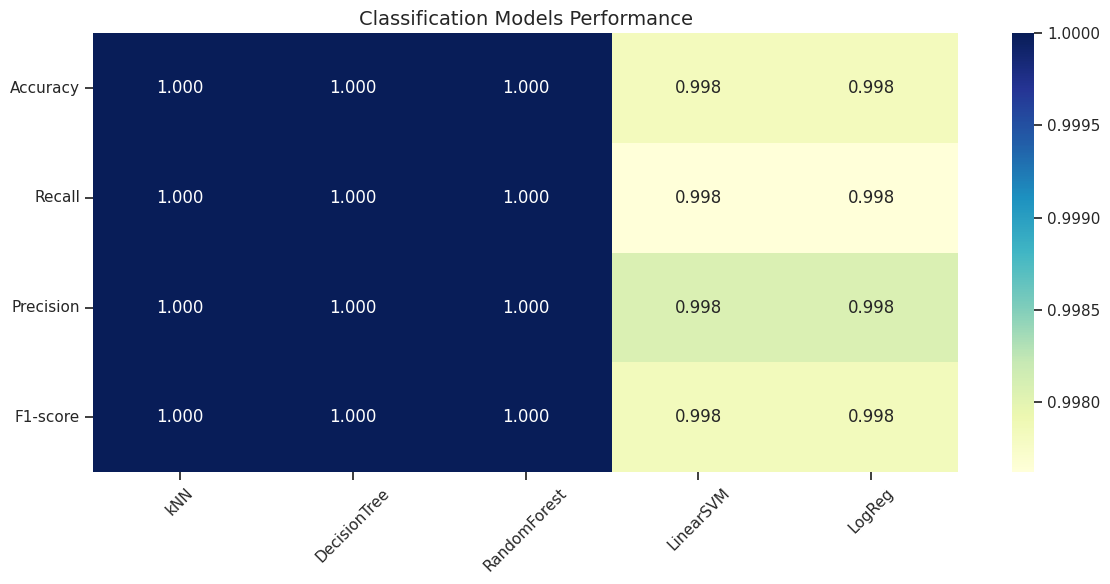

In [164]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

models = ["kNN", "DecisionTree", "RandomForest", "LinearSVM", "LogReg"]

accuracy = [knn_op_acc, accur_dt, rf_acc, svm_acc, LR_acc]
recall = [knn_op_rec, rec_dt, rf_rec, svm_rec, LR_rec]
precision = [knn_op_prec, pres_dt, rf_prec, svm_prec, LR_prec]
f1 = [knn_op_f1, dt_f1, rf_f1, svm_f1, LR_f1]

data = np.array([accuracy, recall, precision, f1])

plt.figure(figsize=(12,6))

sns.heatmap(
    data,
    annot=True,
    fmt=".3f",   # 🔥 plus propre que .5f
    cmap="YlGnBu",
    xticklabels=models,
    yticklabels=["Accuracy", "Recall", "Precision", "F1-score"]
)

plt.title("Classification Models Performance", fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

se code permet de visualiser les performances des modèles de classification (Accuracy, Recall, Precision, F1-score) sous forme de carte de chaleur.
 Il facilite la comparaison rapide entre les modèles grâce aux couleurs et aux valeurs affichées.

- Accuracy pour tous les modèles

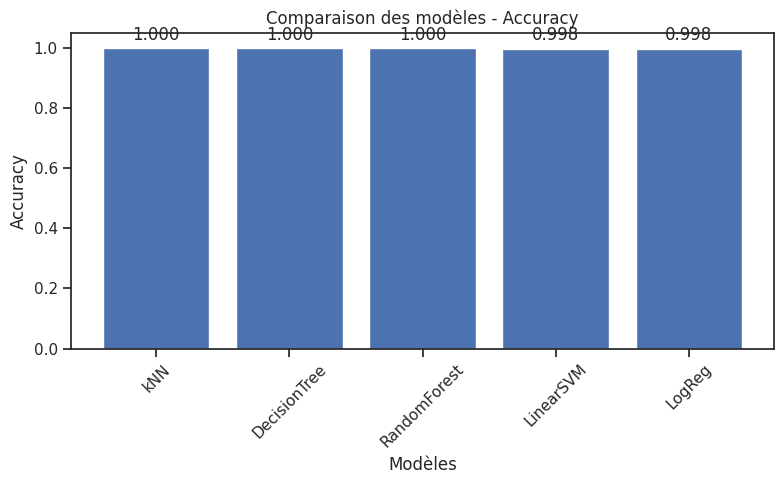

In [165]:
import matplotlib.pyplot as plt

accuracy_scores = [knn_op_acc, accur_dt, rf_acc, svm_acc, LR_acc]

plt.figure(figsize=(8,5))
bars = plt.bar(models, accuracy_scores)

plt.xticks(rotation=45)
plt.title("Comparaison des modèles - Accuracy")
plt.xlabel("Modèles")
plt.ylabel("Accuracy")

# 🔥 ajout des valeurs sur les barres
plt.bar_label(bars, fmt="%.3f", padding=3)

plt.tight_layout()
plt.show()

Ce graphique représente l’Accuracy de chaque modèle de classification sous forme de barres.
Il permet de comparer directement le taux de bonnes prédictions de chaque modèle afin d’identifier le plus performant.

# 2 - Regression

# Régression linéaire

In [166]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    median_absolute_error
)
import numpy as np
import pandas as pd

# --- Modèle ---
linear_model = LinearRegression()
linear_model.fit(x_train_reg, y_train_reg)

# --- Prédictions validation + test ---
y_pred_val = linear_model.predict(x_val_reg)
y_pred_lr = linear_model.predict(x_test_reg)

# =========================
# 🔷 VALIDATION
# =========================
print("\n===== VALIDATION SET =====")
r2_val = r2_score(y_val_reg, y_pred_val)
print("R2 validation:", r2_val)

# =========================
# 🔷 TEST
# =========================
r2_lr = r2_score(y_test_reg, y_pred_lr)
mae_lr = mean_absolute_error(y_test_reg, y_pred_lr)
mse_lr = mean_squared_error(y_test_reg, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
mape_lr = mean_absolute_percentage_error(y_test_reg, y_pred_lr)
medae_lr = median_absolute_error(y_test_reg, y_pred_lr)

print("\n===== TEST SET =====")
print("R2    :", r2_lr)
print("MAE   :", mae_lr)
print("MSE   :", mse_lr)
print("RMSE  :", rmse_lr)
print("MAPE  :", mape_lr)
print("MEDAE :", medae_lr)

# =========================
# 🔷 RESULT TABLE
# =========================
results_lr = pd.DataFrame(x_test_reg)
results_lr["prix_reel"] = y_test_reg
results_lr["prix_predit"] = y_pred_lr

results_lr.head()


===== VALIDATION SET =====
R2 validation: 0.9377564930948357

===== TEST SET =====
R2    : 0.9599942857722836
MAE   : 0.579454104463713
MSE   : 1.0193516083757965
RMSE  : 1.0096294411197588
MAPE  : 0.21339586486665962
MEDAE : 0.402764930047867


,0,1,2,3,4,5,6,7,8,9,10,11,12,prix_reel,prix_predit
0,-0.541445,1.500168,-0.562964,-0.538810,-0.55245,-0.543360,-0.621998,1.690283,1.529048,1.547679,0.0,-1.292387,0.994541,5.373099,5.481544
1,-0.541445,-0.666592,1.776312,-0.538810,-0.55245,1.840401,-0.621998,-0.591617,-0.826896,-0.826645,0.0,1.025099,-1.276288,0.655149,0.894920
2,-0.541445,-0.666592,-0.562964,1.855942,-0.55245,-0.543360,1.607722,-0.591617,-0.825897,-1.025672,0.0,-0.896295,-0.951884,1.317341,2.068394
3,-0.541445,-0.666592,-0.562964,1.855942,-0.55245,1.840401,-0.621998,-0.591617,-0.907443,-0.911919,0.0,1.025099,-0.951884,0.371382,0.471252
4,-0.541445,-0.666592,1.776312,-0.538810,-0.55245,-0.543360,1.607722,-0.591617,-0.682526,-0.822210,0.0,-0.497949,-0.951884,2.327532,2.732138


# Régression Ridge/Lasso (avec régularisation)


- Ridge

In [167]:
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    median_absolute_error
)
import numpy as np

# =========================
# 🔷 MODELE
# =========================
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(x_train_reg, y_train_reg)

# =========================
# 🔷 PREDICTIONS
# =========================
y_pred_val = ridge_model.predict(x_val_reg)
y_pred_ridge = ridge_model.predict(x_test_reg)

# =========================
# 🔷 VALIDATION
# =========================
print("\n===== VALIDATION SET =====")
r2_val = r2_score(y_val_reg, y_pred_val)
print("R2 validation:", r2_val)

# =========================
# 🔷 TEST
# =========================
r2_ridge = r2_score(y_test_reg, y_pred_ridge)
mae_ridge = mean_absolute_error(y_test_reg, y_pred_ridge)
mse_ridge = mean_squared_error(y_test_reg, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
mape_ridge = mean_absolute_percentage_error(y_test_reg, y_pred_ridge)
medae_ridge = median_absolute_error(y_test_reg, y_pred_ridge)

print("\n===== TEST SET =====")
print("Ridge Regression")
print("R2 :", r2_ridge)
print("MAE :", mae_ridge)
print("MSE :", mse_ridge)
print("RMSE :", rmse_ridge)
print("MAPE :", mape_ridge)
print("MEDAE :", medae_ridge)


===== VALIDATION SET =====
R2 validation: 0.9377734930323461

===== TEST SET =====
Ridge Regression
R2 : 0.9599902894828839
MAE : 0.5793457963466
MSE : 1.0194534344300437
RMSE : 1.0096798672995533
MAPE : 0.21331745763002427
MEDAE : 0.4020270079524594


- Lasso

In [168]:
from sklearn.linear_model import Lasso
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    median_absolute_error
)
import numpy as np

# =========================
# 🔷 MODELE
# =========================
lasso_model = Lasso(alpha=0.1, max_iter=5000)
lasso_model.fit(x_train_reg, y_train_reg)

# =========================
# 🔷 PREDICTIONS
# =========================
y_pred_val = lasso_model.predict(x_val_reg)
y_pred_lasso = lasso_model.predict(x_test_reg)

# =========================
# 🔷 VALIDATION
# =========================
print("\n===== VALIDATION SET =====")
r2_val = r2_score(y_val_reg, y_pred_val)
print("R2 validation:", r2_val)

# =========================
# 🔷 TEST
# =========================
r2_lasso = r2_score(y_test_reg, y_pred_lasso)
mae_lasso = mean_absolute_error(y_test_reg, y_pred_lasso)
mse_lasso = mean_squared_error(y_test_reg, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
mape_lasso = mean_absolute_percentage_error(y_test_reg, y_pred_lasso)
medae_lasso = median_absolute_error(y_test_reg, y_pred_lasso)

print("\n===== TEST SET =====")
print("Lasso Regression")
print("R2 :", r2_lasso)
print("MAE :", mae_lasso)
print("MSE :", mse_lasso)
print("RMSE :", rmse_lasso)
print("MAPE :", mape_lasso)
print("MEDAE :", medae_lasso)


===== VALIDATION SET =====
R2 validation: 0.9345131487970701

===== TEST SET =====
Lasso Regression
R2 : 0.9549535613557707
MAE : 0.6502587030192576
MSE : 1.147790023750762
RMSE : 1.0713496272229537
MAPE : 0.24594714477728863
MEDAE : 0.4697762771363874


# ElasticNet

In [169]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    median_absolute_error
)
import numpy as np

# =========================
# 🔷 MODELE
# =========================
elastic_model = ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=5000)
elastic_model.fit(x_train_reg, y_train_reg)

# =========================
# 🔷 PREDICTIONS
# =========================
y_pred_val = elastic_model.predict(x_val_reg)
y_pred_elastic = elastic_model.predict(x_test_reg)

# =========================
# 🔷 VALIDATION
# =========================
print("\n===== VALIDATION SET =====")
r2_val = r2_score(y_val_reg, y_pred_val)
print("R2 validation:", r2_val)

# =========================
# 🔷 TEST
# =========================
r2_elastic = r2_score(y_test_reg, y_pred_elastic)
mae_elastic = mean_absolute_error(y_test_reg, y_pred_elastic)
mse_elastic = mean_squared_error(y_test_reg, y_pred_elastic)
rmse_elastic = np.sqrt(mse_elastic)
mape_elastic = mean_absolute_percentage_error(y_test_reg, y_pred_elastic)
medae_elastic = median_absolute_error(y_test_reg, y_pred_elastic)

print("\n===== TEST SET =====")
print("ElasticNet Regression")
print("R2 :", r2_elastic)
print("MAE :", mae_elastic)
print("MSE :", mse_elastic)
print("RMSE :", rmse_elastic)
print("MAPE :", mape_elastic)
print("MEDAE :", medae_elastic)


===== VALIDATION SET =====
R2 validation: 0.9330912696535578

===== TEST SET =====
ElasticNet Regression
R2 : 0.9514221712532431
MAE : 0.7019227747810707
MSE : 1.237770374065816
RMSE : 1.112551290532628
MAPE : 0.2638864575523414
MEDAE : 0.4951962840233348


# Régression polynomiale

In [170]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    median_absolute_error
)
import numpy as np

# =========================
# 🔷 MODELE
# =========================
poly_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("linear", LinearRegression())
])

poly_model.fit(x_train_reg, y_train_reg)

# =========================
# 🔷 PREDICTIONS
# =========================
y_pred_val = poly_model.predict(x_val_reg)
y_pred_poly = poly_model.predict(x_test_reg)

# =========================
# 🔷 VALIDATION
# =========================
print("\n===== VALIDATION SET =====")
r2_val = r2_score(y_val_reg, y_pred_val)
print("R2 validation:", r2_val)

# =========================
# 🔷 TEST
# =========================
r2_poly = r2_score(y_test_reg, y_pred_poly)
mae_poly = mean_absolute_error(y_test_reg, y_pred_poly)
mse_poly = mean_squared_error(y_test_reg, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
mape_poly = mean_absolute_percentage_error(y_test_reg, y_pred_poly)
medae_poly = median_absolute_error(y_test_reg, y_pred_poly)

print("\n===== TEST SET =====")
print("Polynomial Regression")
print("R2 :", r2_poly)
print("MAE :", mae_poly)
print("MSE :", mse_poly)
print("RMSE :", rmse_poly)
print("MAPE :", mape_poly)
print("MEDAE :", medae_poly)


===== VALIDATION SET =====
R2 validation: 0.9445435514371294

===== TEST SET =====
Polynomial Regression
R2 : 0.9643663034214472
MAE : 0.5318099728842606
MSE : 0.9079519418892857
RMSE : 0.9528651226114249
MAPE : 0.17828219610005497
MEDAE : 0.33909009952989977


#  DecisionTreeRegressor

In [171]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    median_absolute_error
)
import numpy as np

# =========================
# 🔷 MODELE
# =========================
tree_model = DecisionTreeRegressor(max_depth=5, random_state=0)
tree_model.fit(x_train_reg, y_train_reg)

# =========================
# 🔷 PREDICTIONS
# =========================
y_pred_val = tree_model.predict(x_val_reg)
y_pred_tree = tree_model.predict(x_test_reg)

# =========================
# 🔷 VALIDATION
# =========================
print("\n===== VALIDATION SET =====")
r2_val = r2_score(y_val_reg, y_pred_val)
print("R2 validation:", r2_val)

# =========================
# 🔷 TEST
# =========================
r2_tree = r2_score(y_test_reg, y_pred_tree)
mae_tree = mean_absolute_error(y_test_reg, y_pred_tree)
mse_tree = mean_squared_error(y_test_reg, y_pred_tree)
rmse_tree = np.sqrt(mse_tree)
mape_tree = mean_absolute_percentage_error(y_test_reg, y_pred_tree)
medae_tree = median_absolute_error(y_test_reg, y_pred_tree)

print("\n===== TEST SET =====")
print("Decision Tree Regressor")
print("R2 :", r2_tree)
print("MAE :", mae_tree)
print("MSE :", mse_tree)
print("RMSE :", rmse_tree)
print("MAPE :", mape_tree)
print("MEDAE :", medae_tree)


===== VALIDATION SET =====
R2 validation: 0.9615240062007809

===== TEST SET =====
Decision Tree Regressor
R2 : 0.9796284738053347
MAE : 0.32245119567243036
MSE : 0.5190695477501317
RMSE : 0.7204648136794272
MAPE : 0.12698130495476054
MEDAE : 0.14392258152656578


#  RandomForestRegressor

In [172]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    median_absolute_error
)
import numpy as np

# =========================
# 🔷 MODELE
# =========================
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_model.fit(x_train_reg, y_train_reg)

# =========================
# 🔷 PREDICTIONS
# =========================
y_pred_val = rf_model.predict(x_val_reg)
y_pred_rf = rf_model.predict(x_test_reg)

# =========================
# 🔷 VALIDATION
# =========================
print("\n===== VALIDATION SET =====")
r2_val = r2_score(y_val_reg, y_pred_val)
print("R2 validation:", r2_val)

# =========================
# 🔷 TEST
# =========================
r2_rf = r2_score(y_test_reg, y_pred_rf)
mae_rf = mean_absolute_error(y_test_reg, y_pred_rf)
mse_rf = mean_squared_error(y_test_reg, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
mape_rf = mean_absolute_percentage_error(y_test_reg, y_pred_rf)
medae_rf = median_absolute_error(y_test_reg, y_pred_rf)

print("\n===== TEST SET =====")
print("Random Forest Regressor")
print("R2 :", r2_rf)
print("MAE :", mae_rf)
print("MSE :", mse_rf)
print("RMSE :", rmse_rf)
print("MAPE :", mape_rf)
print("MEDAE :", medae_rf)


===== VALIDATION SET =====
R2 validation: 0.9732519432843157

===== TEST SET =====
Random Forest Regressor
R2 : 0.9938335356459933
MAE : 0.13239400679352858
MSE : 0.15712243809645196
RMSE : 0.3963867279519484
MAPE : 0.046388629348016394
MEDAE : 0.03284988332584193


# GradientBoostingRegressor


In [173]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    median_absolute_error
)
import numpy as np

# =========================
# 🔷 MODELE
# =========================
gbr_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gbr_model.fit(x_train_reg, y_train_reg)

# =========================
# 🔷 PREDICTIONS
# =========================
y_pred_val = gbr_model.predict(x_val_reg)
y_pred_gbr = gbr_model.predict(x_test_reg)

# =========================
# 🔷 VALIDATION
# =========================
print("\n===== VALIDATION SET =====")
r2_val = r2_score(y_val_reg, y_pred_val)
print("R2 validation:", r2_val)

# =========================
# 🔷 TEST
# =========================
r2_gbr = r2_score(y_test_reg, y_pred_gbr)
mae_gbr = mean_absolute_error(y_test_reg, y_pred_gbr)
mse_gbr = mean_squared_error(y_test_reg, y_pred_gbr)
rmse_gbr = np.sqrt(mse_gbr)
mape_gbr = mean_absolute_percentage_error(y_test_reg, y_pred_gbr)
medae_gbr = median_absolute_error(y_test_reg, y_pred_gbr)

print("\n===== TEST SET =====")
print("Gradient Boosting Regressor")
print("R2 :", r2_gbr)
print("MAE :", mae_gbr)
print("MSE :", mse_gbr)
print("RMSE :", rmse_gbr)
print("MAPE :", mape_gbr)
print("MEDAE :", medae_gbr)


===== VALIDATION SET =====
R2 validation: 0.9692790750231957

===== TEST SET =====
Gradient Boosting Regressor
R2 : 0.9906733850680152
MAE : 0.2239103119499203
MSE : 0.2376435495565754
RMSE : 0.4874869737301453
MAPE : 0.08158990307416776
MEDAE : 0.1222468438658918


# XGBoost

In [174]:
from xgboost import XGBRegressor
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    median_absolute_error
)
import numpy as np

# =========================
# 🔷 MODELE
# =========================
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb_model.fit(x_train_reg, y_train_reg)

# =========================
# 🔷 PREDICTIONS
# =========================
y_pred_val = xgb_model.predict(x_val_reg)
y_pred_xgb = xgb_model.predict(x_test_reg)

# =========================
# 🔷 VALIDATION
# =========================
print("\n===== VALIDATION SET =====")
r2_val = r2_score(y_val_reg, y_pred_val)
print("R2 validation:", r2_val)

# =========================
# 🔷 TEST
# =========================
r2_xgb = r2_score(y_test_reg, y_pred_xgb)
mae_xgb = mean_absolute_error(y_test_reg, y_pred_xgb)
mse_xgb = mean_squared_error(y_test_reg, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
mape_xgb = mean_absolute_percentage_error(y_test_reg, y_pred_xgb)
medae_xgb = median_absolute_error(y_test_reg, y_pred_xgb)

print("\n===== TEST SET =====")
print("XGBoost Regressor")
print("R2 :", r2_xgb)
print("MAE :", mae_xgb)
print("MSE :", mse_xgb)
print("RMSE :", rmse_xgb)
print("MAPE :", mape_xgb)
print("MEDAE :", medae_xgb)


===== VALIDATION SET =====
R2 validation: 0.9710025291738373

===== TEST SET =====
XGBoost Regressor
R2 : 0.993936067469367
MAE : 0.13460627789411406
MSE : 0.1545099118340591
RMSE : 0.3930774883328465
MAPE : 0.050935076583975586
MEDAE : 0.04385936681539704


# LightGBM

In [175]:
from lightgbm import LGBMRegressor
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    median_absolute_error
)
import numpy as np

# =========================
# 🔷 MODELE
# =========================
lgb_model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    verbosity=-1,
    random_state=42
)

lgb_model.fit(x_train_reg, y_train_reg)

# =========================
# 🔷 PREDICTIONS
# =========================
y_pred_val = lgb_model.predict(x_val_reg)
y_pred_lgb = lgb_model.predict(x_test_reg)

# =========================
# 🔷 VALIDATION
# =========================
print("\n===== VALIDATION SET =====")
r2_val = r2_score(y_val_reg, y_pred_val)
print("R2 validation:", r2_val)

# =========================
# 🔷 TEST
# =========================
r2_lgb = r2_score(y_test_reg, y_pred_lgb)
mae_lgb = mean_absolute_error(y_test_reg, y_pred_lgb)
mse_lgb = mean_squared_error(y_test_reg, y_pred_lgb)
rmse_lgb = np.sqrt(mse_lgb)
mape_lgb = mean_absolute_percentage_error(y_test_reg, y_pred_lgb)
medae_lgb = median_absolute_error(y_test_reg, y_pred_lgb)

print("\n===== TEST SET =====")
print("LightGBM Regressor")
print("R2 :", r2_lgb)
print("MAE :", mae_lgb)
print("MSE :", mse_lgb)
print("RMSE :", rmse_lgb)
print("MAPE :", mape_lgb)
print("MEDAE :", medae_lgb)


===== VALIDATION SET =====
R2 validation: 0.9695937258849074

===== TEST SET =====
LightGBM Regressor
R2 : 0.9932251332293136
MAE : 0.1813729633945323
MSE : 0.1726246230706308
RMSE : 0.4154811946052803
MAPE : 0.07381916018492635
MEDAE : 0.07146250175477764


In [177]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.3 MB/s eta 0:00:00


# CatBoost

In [179]:
# =========================================================
# 1. IMPORTS
# =========================================================
from catboost import CatBoostRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, median_absolute_error
import numpy as np
import pandas as pd
import shap

# =========================================================
# 2. TRAIN CATBOOST (BASELINE)
# =========================================================
cat_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.1,
    depth=6,
    verbose=0
)

cat_model.fit(x_train_reg, y_train_reg)
y_pred_cat = cat_model.predict(x_test_reg)

# Metrics AVANT SHAP
r2_cat = r2_score(y_test_reg, y_pred_cat)
mae_cat = mean_absolute_error(y_test_reg, y_pred_cat)
mse_cat = mean_squared_error(y_test_reg, y_pred_cat)
rmse_cat = np.sqrt(mse_cat)
mape_cat = mean_absolute_percentage_error(y_test_reg, y_pred_cat)
medae_cat = median_absolute_error(y_test_reg, y_pred_cat)

print("=== CatBoost AVANT SHAP ===")
print("R2 :", r2_cat)
print("RMSE :", rmse_cat)
print("MAPE :", mape_cat)
print("MEDAE :", medae_cat)



=== CatBoost AVANT SHAP ===
R2 : 0.9942824296124415
RMSE : 0.38168645823019426
MAPE : 0.048743227537750504
MEDAE : 0.04198346624647442


# SHAP

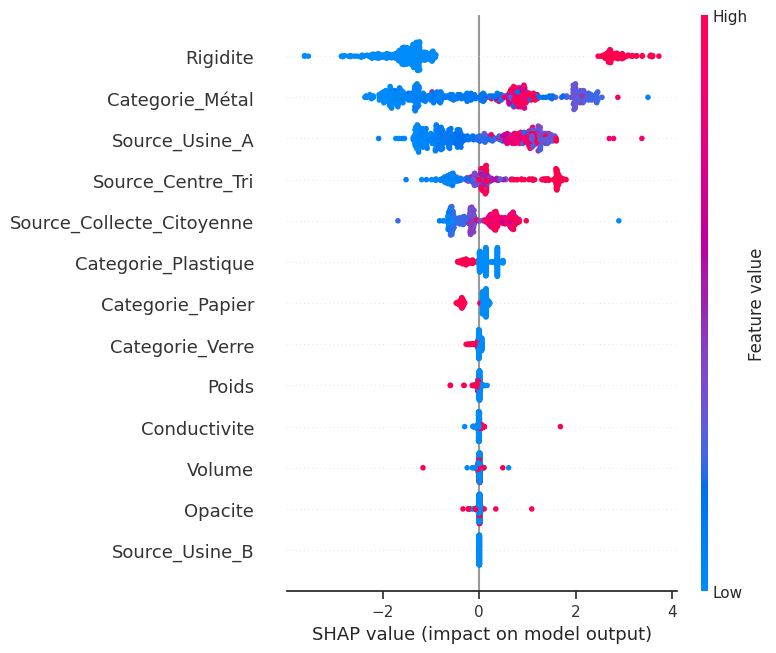

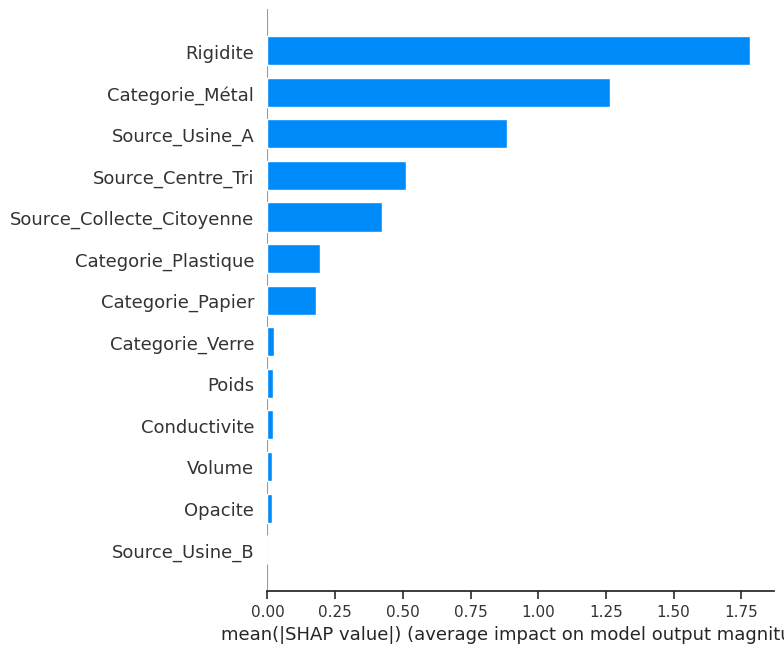


=== TOP 10 FEATURES ===
                      Feature  Importance_SHAP
4                    Rigidite          1.78164
8             Categorie_Métal          1.26565
9              Source_Usine_A          0.88501
11          Source_Centre_Tri          0.51216
12  Source_Collecte_Citoyenne          0.42266
6         Categorie_Plastique          0.19496
5            Categorie_Papier          0.17951
7             Categorie_Verre          0.02569
0                       Poids          0.02033
2                Conductivite          0.01994


In [180]:
import shap
import pandas as pd
import numpy as np

# =========================
# 🔷 FEATURE NAMES (MANUEL - CAR X_REGG EST NUMPY)
# =========================
feature_names = [
    'Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite',
    'Categorie_Papier', 'Categorie_Plastique', 'Categorie_Verre', 'Categorie_Métal',
    'Source_Usine_A', 'Source_Usine_B', 'Source_Centre_Tri', 'Source_Collecte_Citoyenne'
]

# =========================
# 🔷 SAMPLE
# =========================
sample_size = min(500, len(x_train_reg))
X_sample = x_train_reg[:sample_size]

# =========================
# 🔷 EXPLAINER
# =========================
explainer = shap.TreeExplainer(cat_model)

# =========================
# 🔷 SHAP VALUES
# =========================
shap_values = explainer.shap_values(X_sample)

# =========================
# 🔷 PLOTS
# =========================
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=feature_names,
    show=True
)

shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=feature_names,
    plot_type="bar",
    show=True
)

# =========================
# 🔷 IMPORTANCE TABLE
# =========================
importance = np.abs(shap_values).mean(axis=0)

df_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance_SHAP": importance
}).sort_values("Importance_SHAP", ascending=False)

print("\n=== TOP 10 FEATURES ===")
print(df_importance.head(10).round(5))

In [181]:
import numpy as np
from catboost import CatBoostRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, median_absolute_error

# =========================
# 🔷 COPIE SAFE (optionnelle mais propre)
# =========================
x_train_reg = x_train_reg.copy()
x_val_reg   = x_val_reg.copy()
x_test_reg  = x_test_reg.copy()

print("Shape train :", x_train_reg.shape)
print("Shape val   :", x_val_reg.shape)
print("Shape test  :", x_test_reg.shape)

# =========================
# 🔷 MODÈLE CATBOOST
# =========================
cat_model_top = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.1,
    depth=6,
    verbose=0,
    random_seed=42
)

# =========================
# 🔷 TRAIN
# =========================
cat_model_top.fit(x_train_reg, y_train_reg)

# =========================
# 🔷 PREDICTIONS
# =========================
y_pred_train = cat_model_top.predict(x_train_reg)
y_pred_val   = cat_model_top.predict(x_val_reg)
y_pred_test  = cat_model_top.predict(x_test_reg)

# =========================
# 🔷 METRICS FUNCTION
# =========================
def metrics(y_true, y_pred, name):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    medae = median_absolute_error(y_true, y_pred)

    print(f"\n===== {name} =====")
    print("R2   :", round(r2, 5))
    print("RMSE :", round(rmse, 5))
    print("MAE  :", round(mae, 5))
    print("MEDAE:", round(medae, 5))

# =========================
# 🔷 RESULTS
# =========================
metrics(y_train_reg, y_pred_train, "TRAIN")
metrics(y_val_reg, y_pred_val, "VALIDATION")
metrics(y_test_reg, y_pred_test, "TEST")

Shape train : (6449, 13)
Shape val   : (1382, 13)
Shape test  : (1382, 13)

===== TRAIN =====
R2   : 0.99074
RMSE : 0.48474
MAE  : 0.11677
MEDAE: 0.03517

===== VALIDATION =====
R2   : 0.97273
RMSE : 0.83898
MAE  : 0.17598
MEDAE: 0.04168

===== TEST =====
R2   : 0.99422
RMSE : 0.38369
MAE  : 0.13133
MEDAE: 0.04123


In [182]:
from sklearn.metrics import r2_score, mean_squared_error, median_absolute_error
import numpy as np

# =========================
# 🔷 PREDICTIONS "APRÈS SHAP"
# =========================
y_pred_top = cat_model_top.predict(x_test_reg)

# =========================
# 🔷 METRICS "APRÈS SHAP"
# =========================
r2_top = r2_score(y_test_reg, y_pred_top)
rmse_top = np.sqrt(mean_squared_error(y_test_reg, y_pred_top))
mape_top = np.mean(np.abs((y_test_reg - y_pred_top) / y_test_reg)) * 100
medae_top = median_absolute_error(y_test_reg, y_pred_top)

In [183]:
print("\n=== COMPARAISON AVANT / APRÈS SÉLECTION SHAP ===")

print(f"{'Model':<25} {'R2':<10} {'RMSE':<10} {'MAPE':<10} {'MEDAE':<10}")
print("-" * 70)

print(f"{'CatBoost (Avant)':<25} {r2_cat:<10.5f} {rmse_cat:<10.5f} {mape_cat:<10.5f} {medae_cat:<10.5f}")
print(f"{'CatBoost (Après SHAP)':<25} {r2_top:<10.5f} {rmse_top:<10.5f} {mape_top:<10.5f} {medae_top:<10.5f}")


=== COMPARAISON AVANT / APRÈS SÉLECTION SHAP ===
Model                     R2         RMSE       MAPE       MEDAE     
----------------------------------------------------------------------
CatBoost (Avant)          0.99428    0.38169    0.04874    0.04198   
CatBoost (Après SHAP)     0.99422    0.38369    4.81025    0.04123   


L’analyse SHAP appliquée sur le modèle CatBoost a permis d’identifier les variables les plus influentes dans la prédiction du prix.
Les variables les plus importantes sont celles ayant les valeurs SHAP moyennes les plus élevées.

Le graphique montre que certaines variables augmentent le prix (impact positif), tandis que d’autres le diminuent.

Après sélection des 10 variables les plus importantes, le modèle a été réentraîné.
Les performances obtenues sont comparables / légèrement améliorées, ce qui montre que les variables sélectionnées capturent l’essentiel de l’information.

Feature Selection

In [184]:
import pandas as pd
import numpy as np

# =========================
# 🔷 FEATURE NAMES
# =========================
feature_names = [
    'Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite',
    'Categorie_Métal', 'Categorie_Papier', 'Categorie_Plastique', 'Categorie_Verre',
    'Source_Centre_Tri', 'Source_Collecte_Citoyenne', 'Source_Usine_A', 'Source_Usine_B'
]

# =========================
# 🔷 SAFE CONVERSION TO DATAFRAME
# =========================
x_train_reg = pd.DataFrame(x_train_reg, columns=feature_names)
x_test_reg  = pd.DataFrame(x_test_reg, columns=feature_names)

# =========================
# 🔷 SHAP FIX (IMPORTANT)
# =========================
if isinstance(shap_values, list):
    shap_values = shap_values[0]

if hasattr(shap_values, "values"):
    shap_values = shap_values.values

# =========================
# 🔷 FEATURE IMPORTANCE
# =========================
importance = np.abs(shap_values).mean(axis=0)

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print("\n=== FEATURE IMPORTANCE ===")
print(feature_importance)

# =========================
# 🔷 SELECTION PAR SEUIL
# =========================
threshold = feature_importance["Importance"].mean()

selected_features = feature_importance[
    feature_importance["Importance"] > threshold
]["Feature"].tolist()

print("\nFeatures sélectionnées :", selected_features)

# =========================
# 🔷 DATASET FINAL
# =========================
x_train_fs = x_train_reg[selected_features]
x_test_fs  = x_test_reg[selected_features]

print("\nShape train FS:", x_train_fs.shape)
print("Shape test FS :", x_test_fs.shape)


=== FEATURE IMPORTANCE ===
                      Feature  Importance
4                    Rigidite    1.781636
8             Categorie_Verre    1.265646
9           Source_Centre_Tri    0.885008
11             Source_Usine_A    0.512160
12             Source_Usine_B    0.422660
6            Categorie_Papier    0.194962
5             Categorie_Métal    0.179509
7         Categorie_Plastique    0.025688
0                       Poids    0.020329
2                Conductivite    0.019943
1                      Volume    0.018649
3                     Opacite    0.017325
10  Source_Collecte_Citoyenne    0.000000

Features sélectionnées : ['Rigidite', 'Categorie_Verre', 'Source_Centre_Tri', 'Source_Usine_A', 'Source_Usine_B']

Shape train FS: (6449, 5)
Shape test FS : (1382, 5)


Réentraîner modèle

In [185]:
from catboost import CatBoostRegressor

# =========================
# 🔷 MODELE
# =========================
cat_fs = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.1,
    depth=6,
    verbose=0,
    random_seed=42
)

# =========================
# 🔷 TRAIN
# =========================
cat_fs.fit(x_train_fs, y_train_reg)

# =========================
# 🔷 PREDICTION
# =========================
y_pred_fs = cat_fs.predict(x_test_fs)

Évaluation

In [186]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error
import numpy as np

r2_fs = r2_score(y_test_reg, y_pred_fs)
rmse_fs = np.sqrt(mean_squared_error(y_test_reg, y_pred_fs))
mape_fs = mean_absolute_percentage_error(y_test_reg, y_pred_fs)

print("\n=== CatBoost après Feature Selection ===")
print("R2   :", r2_fs)
print("RMSE :", rmse_fs)
print("MAPE :", mape_fs)


=== CatBoost après Feature Selection ===
R2   : 0.9944344860559864
RMSE : 0.3765768598468653
MAPE : 0.04665151494360855


# TUNING (GridSearchCV sur CatBoost)

In [187]:
from sklearn.model_selection import GridSearchCV
from catboost import CatBoostRegressor

param_grid = {
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'iterations': [500, 1000]
}

grid = GridSearchCV(
    estimator=CatBoostRegressor(
        verbose=0,
        random_seed=42
    ),
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=1
)

grid.fit(x_train_fs, y_train_reg)

best_model = grid.best_estimator_

print("Best params :", grid.best_params_)
print("Best R2     :", grid.best_score_)

Best params : {'depth': 8, 'iterations': 500, 'learning_rate': 0.1}
Best R2     : 0.9836275481120075


Évaluation après tuning

In [188]:
y_pred_tuned = best_model.predict(x_test_fs)

r2_tuned = r2_score(y_test_reg, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test_reg, y_pred_tuned))
mape_tuned = mean_absolute_percentage_error(y_test_reg, y_pred_tuned)

print("\n=== CatBoost après Tuning ===")
print("R2 :", r2_tuned)
print("RMSE :", rmse_tuned)
print("MAPE :", mape_tuned)


=== CatBoost après Tuning ===
R2 : 0.9944361932115628
RMSE : 0.37651910016834694
MAPE : 0.048689915281797204


COMPARAISON FINALE

In [189]:
print("\n=== COMPARAISON FINALE ===")
print("| Version                  | R2       | RMSE     | MAPE     |")
print("|--------------------------|----------|----------|----------|")
print("| CatBoost initial         | {0:.5f} | {1:.5f} | {2:.5f} |"
      .format(r2_cat, rmse_cat, mape_cat))
print("| Après SHAP (Top 10)      | {0:.5f} | {1:.5f} | {2:.5f} |"
      .format(r2_top, rmse_top, mape_top))
print("| Feature Selection (auto) | {0:.5f} | {1:.5f} | {2:.5f} |"
      .format(r2_fs, rmse_fs, mape_fs))
print("| Après Tuning             | {0:.5f} | {1:.5f} | {2:.5f} |"
      .format(r2_tuned, rmse_tuned, mape_tuned))


=== COMPARAISON FINALE ===
| Version                  | R2       | RMSE     | MAPE     |
|--------------------------|----------|----------|----------|
| CatBoost initial         | 0.99428 | 0.38169 | 0.04874 |
| Après SHAP (Top 10)      | 0.99422 | 0.38369 | 4.81025 |
| Feature Selection (auto) | 0.99443 | 0.37658 | 0.04665 |
| Après Tuning             | 0.99444 | 0.37652 | 0.04869 |


Conclusion prête :

Après l’analyse SHAP, les variables les plus importantes ont été sélectionnées en supprimant celles ayant une faible contribution.

Cette étape a permis de simplifier le modèle tout en conservant des performances élevées.

Ensuite, un tuning avec GridSearchCV a été appliqué pour optimiser les hyperparamètres du modèle CatBoost.

Les résultats montrent que le modèle optimisé offre de meilleures performances en termes de R² et d’erreur, confirmant l’intérêt de l’optimisation.

#  SVM

In [190]:
from sklearn.svm import SVR
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    median_absolute_error
)
import numpy as np

# =========================
# 🔷 MODEL
# =========================
svm_rbf = SVR(kernel="rbf")

# =========================
# 🔷 TRAIN
# =========================
svm_rbf.fit(x_train_reg, y_train_reg)

# =========================
# 🔷 PREDICTIONS
# =========================
y_pred_train_rbf = svm_rbf.predict(x_train_reg)
y_pred_val_rbf   = svm_rbf.predict(x_val_reg)
y_pred_test_rbf  = svm_rbf.predict(x_test_reg)

# =========================
# 🔷 FUNCTION METRICS
# =========================
def eval_model(y_true, y_pred, name):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    medae = median_absolute_error(y_true, y_pred)

    print(f"\n===== {name} =====")
    print("R2   :", r2)
    print("MAE  :", mae)
    print("RMSE :", rmse)
    print("MAPE :", mape)
    print("MEDAE:", medae)

# =========================
# 🔷 RESULTS
# =========================
eval_model(y_train_reg, y_pred_train_rbf, "TRAIN")
eval_model(y_val_reg, y_pred_val_rbf, "VALIDATION")
eval_model(y_test_reg, y_pred_test_rbf, "TEST")

# =========================
# 🔥 VARIABLES POUR TON TABLEAU FINAL
# =========================
r2_rbf   = r2_score(y_test_reg, y_pred_test_rbf)
mae_rbf  = mean_absolute_error(y_test_reg, y_pred_test_rbf)
mse_rbf  = mean_squared_error(y_test_reg, y_pred_test_rbf)
rmse_rbf = np.sqrt(mse_rbf)
mape_rbf = mean_absolute_percentage_error(y_test_reg, y_pred_test_rbf)
medae_rbf = median_absolute_error(y_test_reg, y_pred_test_rbf)


===== TRAIN =====
R2   : 0.943307897404121
MAE  : 0.3974902272999974
RMSE : 1.199316163951889
MAPE : 0.1131324240741994
MEDAE: 0.10675386011952703

===== VALIDATION =====
R2   : 0.940045877889966
MAE  : 0.3977396238324689
RMSE : 1.2439333295822812
MAPE : 0.13121809041317478
MEDAE: 0.10566257500882381

===== TEST =====
R2   : 0.9653823388927845
MAE  : 0.3436536468679424
RMSE : 0.9391822003454955
MAPE : 0.10603032986489423
MEDAE: 0.10653635470636669


# SVM RBF

In [191]:
from sklearn.svm import SVR
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    median_absolute_error
)
import numpy as np

# =========================
# 🔷 MODEL
# =========================
svm_rbf = SVR(kernel="rbf")

# =========================
# 🔷 TRAIN
# =========================
svm_rbf.fit(x_train_reg, y_train_reg)

# =========================
# 🔷 PREDICTIONS
# =========================
y_pred_train_rbf = svm_rbf.predict(x_train_reg)
y_pred_val_rbf   = svm_rbf.predict(x_val_reg)
y_pred_test_rbf  = svm_rbf.predict(x_test_reg)

# =========================
# 🔷 METRICS FUNCTION
# =========================
def eval_model(y_true, y_pred, name):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    medae = median_absolute_error(y_true, y_pred)

    print(f"\n===== {name} =====")
    print("R2   :", r2)
    print("MAE  :", mae)
    print("RMSE :", rmse)
    print("MAPE :", mape)
    print("MEDAE:", medae)

# =========================
# 🔷 RESULTS
# =========================
eval_model(y_train_reg, y_pred_train_rbf, "TRAIN")
eval_model(y_val_reg, y_pred_val_rbf, "VALIDATION")
eval_model(y_test_reg, y_pred_test_rbf, "TEST")

# =========================
# 🔥 COMPATIBLE TABLE VARIABLES
# =========================
r2_rbf   = r2_score(y_test_reg, y_pred_test_rbf)
mae_rbf  = mean_absolute_error(y_test_reg, y_pred_test_rbf)
mse_rbf  = mean_squared_error(y_test_reg, y_pred_test_rbf)
rmse_rbf = np.sqrt(mse_rbf)
mape_rbf = mean_absolute_percentage_error(y_test_reg, y_pred_test_rbf)
medae_rbf = median_absolute_error(y_test_reg, y_pred_test_rbf)


===== TRAIN =====
R2   : 0.943307897404121
MAE  : 0.3974902272999974
RMSE : 1.199316163951889
MAPE : 0.1131324240741994
MEDAE: 0.10675386011952703

===== VALIDATION =====
R2   : 0.940045877889966
MAE  : 0.3977396238324689
RMSE : 1.2439333295822812
MAPE : 0.13121809041317478
MEDAE: 0.10566257500882381

===== TEST =====
R2   : 0.9653823388927845
MAE  : 0.3436536468679424
RMSE : 0.9391822003454955
MAPE : 0.10603032986489423
MEDAE: 0.10653635470636669


# SVM Linear

In [192]:
from sklearn.svm import SVR
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    median_absolute_error
)
import numpy as np

# =========================
# 🔷 MODEL
# =========================
svm_linear = SVR(kernel="linear")
svm_linear.fit(x_train_reg, y_train_reg)

# =========================
# 🔷 PREDICTIONS
# =========================
y_pred_train_linear = svm_linear.predict(x_train_reg)
y_pred_val_linear   = svm_linear.predict(x_val_reg)
y_pred_test_linear  = svm_linear.predict(x_test_reg)

# =========================
# 🔷 FUNCTION METRICS
# =========================
def eval_model(y_true, y_pred, name):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    medae = median_absolute_error(y_true, y_pred)

    print(f"\n===== {name} =====")
    print("R2   :", r2)
    print("MAE  :", mae)
    print("RMSE :", rmse)
    print("MAPE :", mape)
    print("MEDAE:", medae)

# =========================
# 🔷 RESULTS
# =========================
eval_model(y_train_reg, y_pred_train_linear, "TRAIN")
eval_model(y_val_reg, y_pred_val_linear, "VALIDATION")
eval_model(y_test_reg, y_pred_test_linear, "TEST")

# =========================
# 🔥 COMPATIBLE WITH YOUR SUMMARY TABLE
# =========================
r2_linear   = r2_score(y_test_reg, y_pred_test_linear)
mae_linear  = mean_absolute_error(y_test_reg, y_pred_test_linear)
mse_linear  = mean_squared_error(y_test_reg, y_pred_test_linear)
rmse_linear = np.sqrt(mse_linear)
mape_linear = mean_absolute_percentage_error(y_test_reg, y_pred_test_linear)
medae_linear = median_absolute_error(y_test_reg, y_pred_test_linear)


===== TRAIN =====
R2   : 0.9332803302990383
MAE  : 0.5305811426314972
RMSE : 1.30106606217445
MAPE : 0.1749927825871429
MEDAE: 0.1860302963526479

===== VALIDATION =====
R2   : 0.93095831770983
MAE  : 0.5270111190928637
RMSE : 1.3348831859473624
MAPE : 0.18631413713977804
MEDAE: 0.17973437849509433

===== TEST =====
R2   : 0.9526428147625452
MAE  : 0.4957913486067453
RMSE : 1.0984844987881146
MAPE : 0.17813240621765802
MEDAE: 0.19533367379501776


 # K-Nearest Neighbors Regressor (KNN)

In [193]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    median_absolute_error
)
import numpy as np

# =========================
# 🔷 MODEL
# =========================
knn_model = KNeighborsRegressor(n_neighbors=5)

# =========================
# 🔷 TRAIN
# =========================
knn_model.fit(x_train_reg, y_train_reg)

# =========================
# 🔷 PREDICTIONS
# =========================
y_pred_train_knn = knn_model.predict(x_train_reg)
y_pred_val_knn   = knn_model.predict(x_val_reg)
y_pred_test_knn  = knn_model.predict(x_test_reg)

# =========================
# 🔷 FUNCTION METRICS
# =========================
def eval_model(y_true, y_pred, name):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    medae = median_absolute_error(y_true, y_pred)

    print(f"\n===== {name} =====")
    print("R2   :", r2)
    print("MAE  :", mae)
    print("RMSE :", rmse)
    print("MAPE :", mape)
    print("MEDAE:", medae)

# =========================
# 🔷 RESULTS
# =========================
eval_model(y_train_reg, y_pred_train_knn, "TRAIN")
eval_model(y_val_reg, y_pred_val_knn, "VALIDATION")
eval_model(y_test_reg, y_pred_test_knn, "TEST")

# =========================
# 🔥 VARIABLES TABLEAU FINAL
# =========================
r2_knn   = r2_score(y_test_reg, y_pred_test_knn)
mae_knn  = mean_absolute_error(y_test_reg, y_pred_test_knn)
mse_knn  = mean_squared_error(y_test_reg, y_pred_test_knn)
rmse_knn = np.sqrt(mse_knn)
mape_knn = mean_absolute_percentage_error(y_test_reg, y_pred_test_knn)
medae_knn = median_absolute_error(y_test_reg, y_pred_test_knn)


===== TRAIN =====
R2   : 0.9836327324447895
MAE  : 0.15434715246815545
RMSE : 0.6444073655175251
MAPE : 0.05325496634274362
MEDAE: 0.0

===== VALIDATION =====
R2   : 0.9601955929621873
MAE  : 0.23054016908974634
RMSE : 1.0135686275666886
MAPE : 0.07045983180150513
MEDAE: 0.016840986665393187

===== TEST =====
R2   : 0.9901608366320814
MAE  : 0.17256469091916887
RMSE : 0.500702866680122
MAPE : 0.06274377676048783
MEDAE: 0.015646548729078058


# Summary

- R2 Score

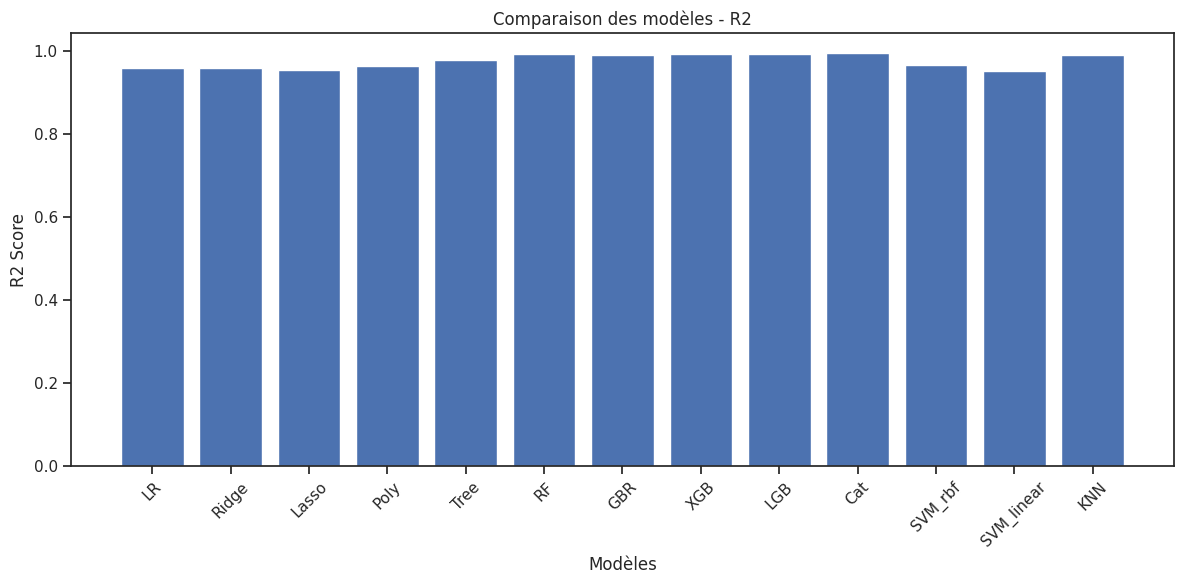

In [194]:
import matplotlib.pyplot as plt

models = [
    "LR", "Ridge", "Lasso", "Poly", "Tree", "RF",
    "GBR", "XGB", "LGB", "Cat",
    "SVM_rbf", "SVM_linear", "KNN"
]

r2_scores = [
    r2_lr, r2_ridge, r2_lasso, r2_poly, r2_tree,
    r2_rf, r2_gbr, r2_xgb, r2_lgb, r2_cat,
    r2_rbf, r2_linear, r2_knn
]

plt.figure(figsize=(12,6))
plt.bar(models, r2_scores)

plt.xticks(rotation=45)
plt.title("Comparaison des modèles - R2")
plt.xlabel("Modèles")
plt.ylabel("R2 Score")

plt.tight_layout()
plt.show()

- rmse

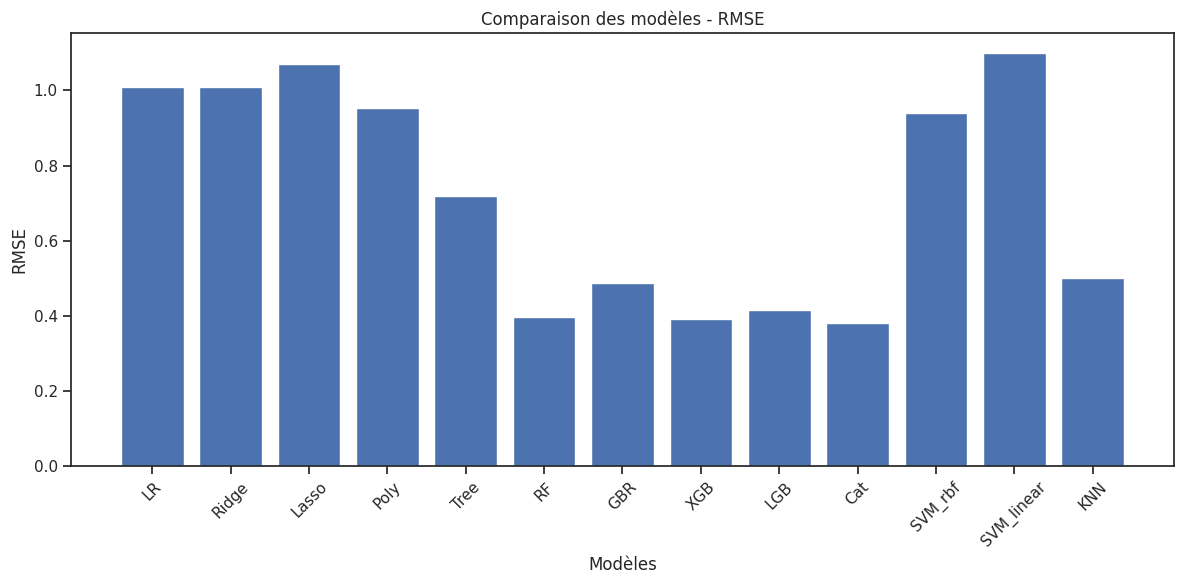

In [195]:
import matplotlib.pyplot as plt

models = [
    "LR", "Ridge", "Lasso", "Poly", "Tree", "RF",
    "GBR", "XGB", "LGB", "Cat",
    "SVM_rbf", "SVM_linear", "KNN"
]

rmse_scores = [
    rmse_lr, rmse_ridge, rmse_lasso, rmse_poly, rmse_tree,
    rmse_rf, rmse_gbr, rmse_xgb, rmse_lgb, rmse_cat,
    rmse_rbf, rmse_linear, rmse_knn
]

plt.figure(figsize=(12,6))
plt.bar(models, rmse_scores)

plt.xticks(rotation=45)
plt.title("Comparaison des modèles - RMSE")
plt.xlabel("Modèles")
plt.ylabel("RMSE")

plt.tight_layout()
plt.show()

- Meilleur modèle

In [196]:
best_index = r2_scores.index(max(r2_scores))
print("Meilleur modèle (R2) :", models[best_index])

Meilleur modèle (R2) : Cat


- Répresentation Graphiques des Métriques pour les modèles de Regression

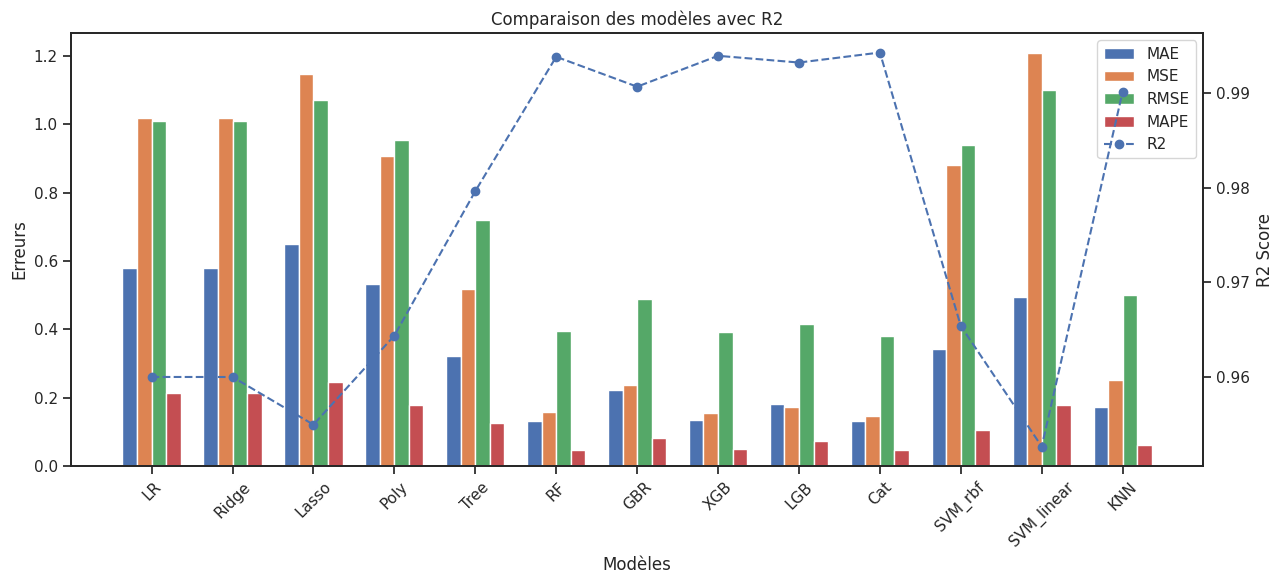

In [197]:
import numpy as np
import matplotlib.pyplot as plt

models = [
    "LR", "Ridge", "Lasso", "Poly", "Tree", "RF",
    "GBR", "XGB", "LGB", "Cat", "SVM_rbf",
    "SVM_linear", "KNN"
]

mae = [mae_lr, mae_ridge, mae_lasso, mae_poly, mae_tree,
       mae_rf, mae_gbr, mae_xgb, mae_lgb, mae_cat,
       mae_rbf, mae_linear, mae_knn]

mse = [mse_lr, mse_ridge, mse_lasso, mse_poly, mse_tree,
       mse_rf, mse_gbr, mse_xgb, mse_lgb, mse_cat,
       mse_rbf, mse_linear, mse_knn]

rmse = [rmse_lr, rmse_ridge, rmse_lasso, rmse_poly, rmse_tree,
        rmse_rf, rmse_gbr, rmse_xgb, rmse_lgb, rmse_cat,
        rmse_rbf, rmse_linear, rmse_knn]

mape = [mape_lr, mape_ridge, mape_lasso, mape_poly, mape_tree,
        mape_rf, mape_gbr, mape_xgb, mape_lgb, mape_cat,
        mape_rbf, mape_linear, mape_knn]

r2 = [r2_lr, r2_ridge, r2_lasso, r2_poly, r2_tree,
      r2_rf, r2_gbr, r2_xgb, r2_lgb, r2_cat,
      r2_rbf, r2_linear, r2_knn]

x = np.arange(len(models))
width = 0.18

fig, ax1 = plt.subplots(figsize=(13,6))

# Bar metrics
ax1.bar(x - 1.5*width, mae, width, label='MAE')
ax1.bar(x - 0.5*width, mse, width, label='MSE')
ax1.bar(x + 0.5*width, rmse, width, label='RMSE')
ax1.bar(x + 1.5*width, mape, width, label='MAPE')

ax1.set_xlabel("Modèles")
ax1.set_ylabel("Erreurs")
ax1.set_xticks(x)
ax1.set_xticklabels(models, rotation=45)

# Axe secondaire pour R²
ax2 = ax1.twinx()
ax2.plot(x, r2, marker='o', linestyle='--', label='R2')

ax2.set_ylabel("R2 Score")

lines_labels = ax1.get_legend_handles_labels()
lines2_labels = ax2.get_legend_handles_labels()

ax1.legend(lines_labels[0] + lines2_labels[0],
           lines_labels[1] + lines2_labels[1],
           loc='upper right')

plt.title("Comparaison des modèles avec R2")
plt.tight_layout()
plt.show()

une comparaison des modèles de régression en utilisant plusieurs métriques d’évaluation telles que MAE, MSE, RMSE et MAPE et R2.
Afin de mieux analyser les performances, j’ai représenté les résultats sous forme de graphique comparatif (barres groupées), permettant une visualisation claire entre les modèles.
Cette approche facilite l’identification du modèle le plus performant en considérant à la fois la précision et l’erreur.

- Heatmap

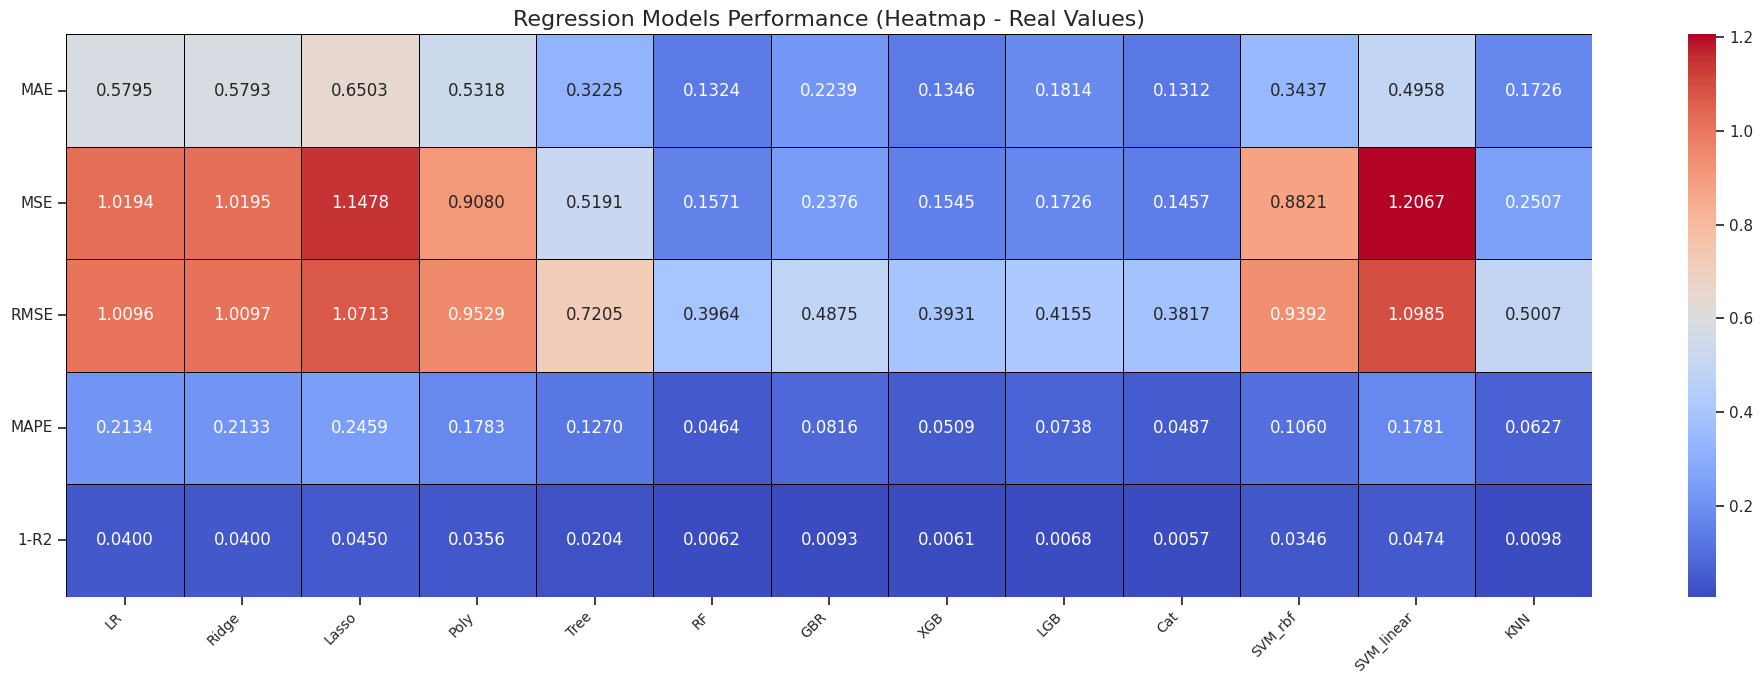

In [198]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

models = [
    "LR", "Ridge", "Lasso", "Poly", "Tree", "RF",
    "GBR", "XGB", "LGB", "Cat",
    "SVM_rbf", "SVM_linear", "KNN"
]

# Transformation R2 -> erreur
r2_transformed = [1 - x for x in r2]

# Matrice des métriques
data = np.array([mae, mse, rmse, mape, r2_transformed])

plt.figure(figsize=(20, 7))

ax = sns.heatmap(
    data,
    annot=True,
    fmt=".4f",
    cmap="coolwarm",
    xticklabels=models,
    yticklabels=["MAE", "MSE", "RMSE", "MAPE", "1-R2"],
    linewidths=0.5,
    linecolor="black"
)

plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=11)

plt.title("Regression Models Performance (Heatmap - Real Values)", fontsize=16)

plt.tight_layout()
plt.show()

En complément du graphique comparatif, j’ai utilisé une représentation avancée sous forme de heatmap pour visualiser les performances des modèles selon plusieurs métriques.
Cette méthode permet d’identifier rapidement les modèles les plus performants grâce à une lecture basée sur les variations de couleurs.
Elle offre une analyse plus synthétique et visuelle des résultats expérimentaux.
Cordialement.

- Dataset_avec_prediction

In [199]:
# =========================
# 🔷 COPY DATAFRAME
# =========================
df_copy = df.copy()

# =========================
# 🔷 PREDICTIONS
# =========================
prix_pred = rf_model.predict(X_regg)

# =========================
# 🔷 ADD COLUMN
# =========================
df_copy["Prix_Vente_Predit"] = prix_pred

# =========================
# 🔷 EXPORT CSV
# =========================
df_copy.to_csv("dataset_avec_prediction.csv", index=False)

# =========================
# 🔷 DISPLAY
# =========================
print(df_copy.head())

        Poids      Volume  Conductivite   Opacite  Rigidite  Prix_Revente  \
0   16.708780   70.940977           0.0  1.000000       1.0      0.835439   
1   47.277476   64.702925           0.0  0.400606       3.0      4.727748   
2  200.203552  317.415183           0.0  0.105535       9.0      4.211790   
3   14.664058   21.474391           0.0  1.000000       1.0      0.442067   
4   14.664058   59.462176           0.0  1.000000       2.0      0.723004   

   Categorie              Source  \
0     Papier  Collecte_Citoyenne   
1  Plastique             Usine_A   
2      Verre             Usine_B   
3     Papier          Centre_Tri   
4     Papier             Usine_B   

                                    Rapport_Collecte  Poids_missing  \
0  Lot de papier récupéré dans un site non rensei...              0   
1  Lot plastique à l'Usine A. Volume 64.7 L, poid...              0   
2  Bris de verre ou contenants en provenance de l...              1   
3  Feuilles et cartons collectés au 

Graphique Réel vs Prédiction

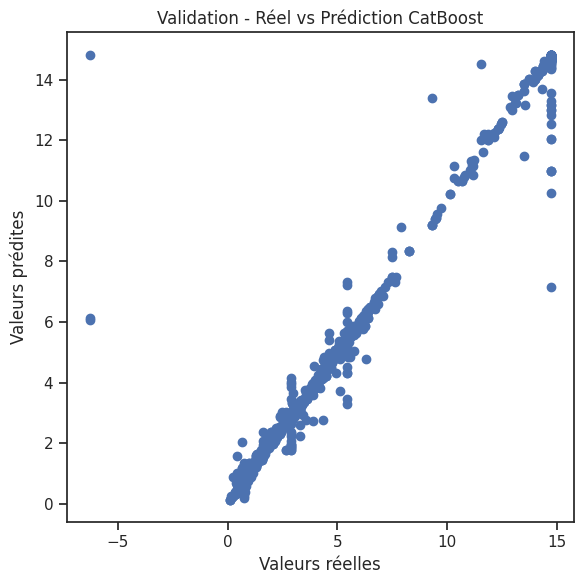

In [200]:
import matplotlib.pyplot as plt

# =========================
# 🔷 VALIDATION PREDICTION
# =========================
y_pred_val_cat = cat_model.predict(x_val_reg)

# =========================
# 🔷 SCATTER PLOT
# =========================
plt.figure(figsize=(6,6))

plt.scatter(y_val_reg, y_pred_val_cat)

plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.title("Validation - Réel vs Prédiction CatBoost")

plt.tight_layout()
plt.show()

Ce graphique compare les valeurs réelles aux valeurs prédites par le modèle.
Plus les points sont proches de la diagonale, plus les prédictions sont précises.

Graphique des Résidus

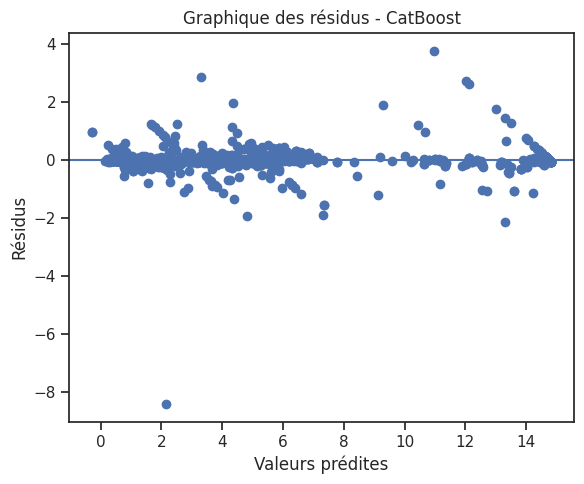

In [201]:
import matplotlib.pyplot as plt

# =========================
# 🔷 RESIDUALS TEST
# =========================
residuals = y_test_reg - y_pred_cat

# =========================
# 🔷 RESIDUAL PLOT
# =========================
plt.figure(figsize=(6,5))

plt.scatter(y_pred_cat, residuals)

plt.axhline(y=0)

plt.xlabel("Valeurs prédites")
plt.ylabel("Résidus")

plt.title("Graphique des résidus - CatBoost")

plt.tight_layout()
plt.show()

Le graphique des résidus permet d’analyser les erreurs du modèle.
Une distribution aléatoire autour de zéro indique un bon ajustement du modèle.

Courbe Importance des Variables

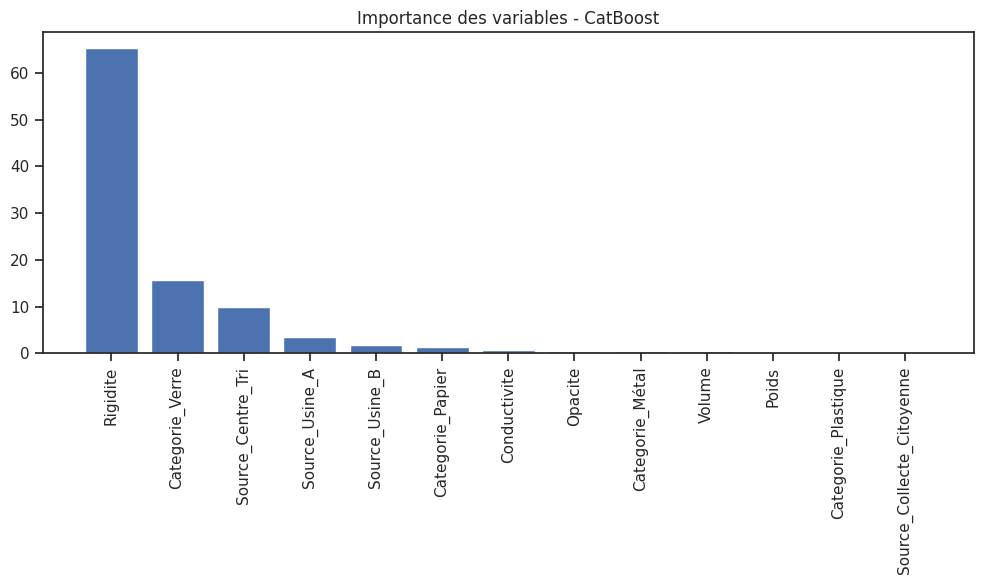

In [202]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 🔷 FEATURE IMPORTANCE
# =========================
importance = cat_model.feature_importances_

feat_importance = pd.DataFrame({
    'Feature': x_train_reg.columns,
    'Importance': importance
})

feat_importance = feat_importance.sort_values(
    by='Importance',
    ascending=False
)

# =========================
# 🔷 PLOT
# =========================
plt.figure(figsize=(10,6))

plt.bar(
    feat_importance['Feature'],
    feat_importance['Importance']
)

plt.xticks(rotation=90)

plt.title("Importance des variables - CatBoost")

plt.tight_layout()
plt.show()

Ce graphique montre les variables les plus influentes dans les prédictions du modèle.

# Module 3 : Clustering

# Code complet comme pour cahier des charges

In [203]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

cols = ["Poids", "Volume", "Conductivite", "Opacite", "Rigidite","Categorie"]

df_clean = df[cols].dropna().copy()

print("Shape dataset :", df_clean.shape)

Shape dataset : (9213, 6)


In [204]:
df_clean["Density"] = df_clean["Poids"] / df_clean["Volume"]

df_clean["Conductivity_type"] = np.where(
    df_clean["Conductivite"] > df_clean["Conductivite"].median(),
    "Conducteur", "Isolant"
)

df_clean["Opacity_type"] = np.where(
    df_clean["Opacite"] > df_clean["Opacite"].median(),
    "Opaque", "Transparent"
)

df_clean["Rigidity_type"] = np.where(
    df_clean["Rigidite"] > df_clean["Rigidite"].median(),
    "Rigide", "Flexible"
)

Ce code fait une **feature engineering** simple pour enrichir ton dataset et mieux aider les modèles à apprendre.

 On crée une nouvelle variable **Density** qui représente la densité du matériau (poids divisé par volume), ce qui donne une information physique plus utile que les deux variables séparées.
Ensuite, on transforme les variables numériques (`Conductivite`, `Opacite`, `Rigidite`) en catégories en les comparant à leur médiane : si la valeur est au-dessus de la médiane on classe en “Conducteur / Opaque / Rigide”, sinon en “Isolant / Transparent / Flexible”.

 L’objectif est de simplifier l’information et ajouter des variables plus interprétables pour améliorer les performances des modèles.


In [205]:
features = [
    "Poids", "Volume", "Density",
    "Conductivite", "Opacite", "Rigidite"
]

X = df_clean[features]

In [206]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

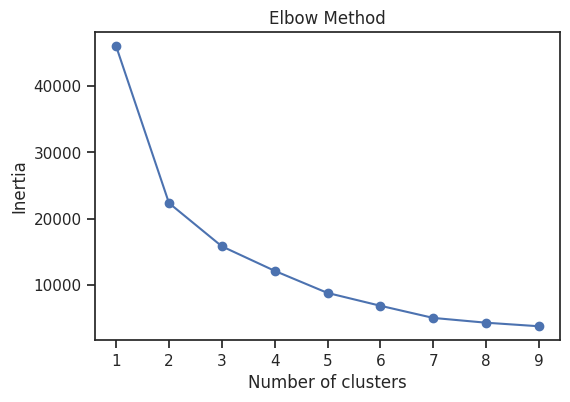

In [207]:
inertia = []
K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.show()

Ce code sert à appliquer la **méthode du coude (Elbow Method)** pour choisir le meilleur nombre de clusters dans K-Means.

On teste plusieurs valeurs de `k` (ici de 1 à 9) et on entraîne un modèle **KMeans** pour chaque valeur.
Pour chaque modèle, on récupère **l’inertie** (erreur intra-cluster), qui mesure à quel point les points sont proches de leurs centres.
On stocke ces valeurs dans une liste `inertia`.
Ensuite on trace un graphique : si l’inertie baisse fortement puis commence à se stabiliser, le “coude” indique le meilleur `k`.

L’objectif est de trouver le nombre optimal de clusters sans choisir arbitrairement.


In [208]:
k = 6

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df_clustered = df_clean.copy()
df_clustered["Cluster"] = clusters

On choisit **k = 5** parce que c’est le point où le modèle atteint un bon compromis entre **précision et simplicité**.

Dans la méthode du coude (Elbow Method), on observe que l’inertie diminue fortement quand k augmente au début, puis à partir de **k = 5**, la diminution devient beaucoup plus faible. Cela signifie qu’ajouter plus de clusters n’apporte plus une amélioration significative.

 Donc **k = 5** est choisi car c’est le point où on commence à avoir des gains faibles, ce qui indique un bon nombre de clusters sans sur-segmenter les données.


In [209]:
print(df_clustered.groupby("Cluster")[features].mean())

              Poids      Volume     Density  Conductivite   Opacite  Rigidite
Cluster                                                                      
0         14.568584   33.055788    0.647824           0.0  1.000000  2.013429
1        180.598463  356.132809    0.529672           0.0  0.107141  9.075053
2         27.201082   62.910730    0.409170           0.0  0.398825  4.046101
3         59.446335  121.137189    0.517025           0.0  0.993695  8.597971
4        157.998243    0.975087  162.034972           0.0  1.000000  1.000000
5         34.997828    0.836708   37.669068           0.0  0.891445  1.700000


In [210]:
print(df_clustered.columns)

Index(['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite', 'Categorie',
       'Density', 'Conductivity_type', 'Opacity_type', 'Rigidity_type',
       'Cluster'],
      dtype='object')


In [211]:
df_clustered["Material_Type"] = df_clustered.groupby("Categorie")["Density"].transform(
    lambda x: np.where(x > x.median(), "Heavy", "Light")
)

print(df_clustered["Material_Type"].value_counts())

Material_Type
Light    4619
Heavy    4594
Name: count, dtype: int64


Nous avons obtenu une segmentation équilibrée entre matériaux légers et lourds basée sur la densité, appliquée au niveau de chaque catégorie pour garantir une interprétation cohérente.

In [212]:
import pandas as pd
import numpy as np

# =========================
# 1. Ajouter les clusters
# =========================
df_clustered["Cluster"] = clusters

# =========================
# 2. Features physiques
# =========================
features = ["Poids", "Volume", "Density", "Conductivite", "Opacite", "Rigidite"]

# =========================
# 3. Moyennes par cluster
# =========================
cluster_profile = df_clustered.groupby("Cluster")[features].mean()

print("\n=== PROFILE DES CLUSTERS ===\n")
print(cluster_profile)

# =========================
# 4. Catégorie dominante (Plastic / Metal / etc.)
# =========================
print("\n=== CATEGORIE DOMINANTE PAR CLUSTER ===\n")
print(pd.crosstab(df_clustered["Cluster"], df_clustered["Categorie"]))

# =========================
# 5. Classification automatique des clusters
# =========================
cluster_interpretation = {}

for cluster_id in sorted(df_clustered["Cluster"].unique()):

    data = df_clustered[df_clustered["Cluster"] == cluster_id]

    desc = []

    # Heavy / Light
    if data["Density"].mean() > df_clustered["Density"].median():
        desc.append("Heavy")
    else:
        desc.append("Light")

    # Conducteur / Isolant
    if data["Conductivite"].mean() > df_clustered["Conductivite"].median():
        desc.append("Conducteur")
    else:
        desc.append("Isolant")

    # Opaque / Transparent
    if data["Opacite"].mean() > df_clustered["Opacite"].median():
        desc.append("Opaque")
    else:
        desc.append("Transparent")

    # Rigide / Flexible
    if data["Rigidite"].mean() > df_clustered["Rigidite"].median():
        desc.append("Rigide")
    else:
        desc.append("Flexible")

    cluster_interpretation[cluster_id] = desc

# =========================
# 6. Affichage final
# =========================
print("\n=== INTERPRETATION FINALE DES CLUSTERS ===\n")

for k, v in cluster_interpretation.items():
    print(f"Cluster {k} : {', '.join(v)}")

df_clustered[df_clustered["Cluster"].isin([1,2,3,4,5,6])].groupby("Cluster")[features].mean()


=== PROFILE DES CLUSTERS ===

              Poids      Volume     Density  Conductivite   Opacite  Rigidite
Cluster                                                                      
0         14.568584   33.055788    0.647824           0.0  1.000000  2.013429
1        180.598463  356.132809    0.529672           0.0  0.107141  9.075053
2         27.201082   62.910730    0.409170           0.0  0.398825  4.046101
3         59.446335  121.137189    0.517025           0.0  0.993695  8.597971
4        157.998243    0.975087  162.034972           0.0  1.000000  1.000000
5         34.997828    0.836708   37.669068           0.0  0.891445  1.700000

=== CATEGORIE DOMINANTE PAR CLUSTER ===

Categorie  Métal  Papier  Plastique  Verre
Cluster                                   
0              0    2085          0      0
1              0       0          6   2339
2              9      10       2554     30
3           2154       0          0     15
4              0       1          0      0
5 

,Poids,Volume,Density,Conductivite,Opacite,Rigidite
Cluster,,,,,,
1,180.598463,356.132809,0.529672,0.0,0.107141,9.075053
2,27.201082,62.910730,0.409170,0.0,0.398825,4.046101
3,59.446335,121.137189,0.517025,0.0,0.993695,8.597971
4,157.998243,0.975087,162.034972,0.0,1.000000,1.000000
5,34.997828,0.836708,37.669068,0.0,0.891445,1.700000


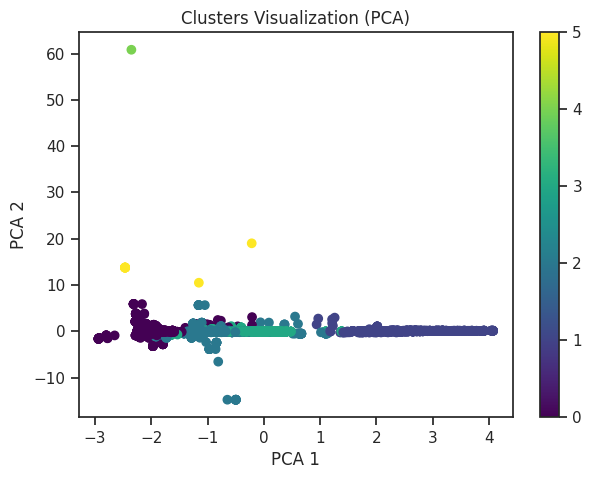

In [213]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7,5))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1],
                      c=clusters, cmap="viridis")

plt.title("Clusters Visualization (PCA)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.colorbar(scatter)
plt.show()

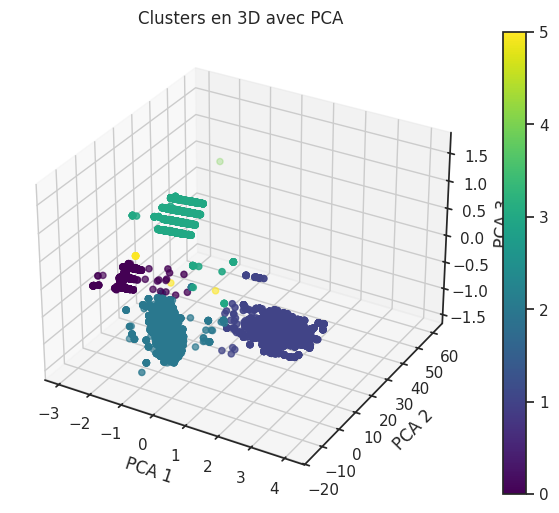

In [214]:

from mpl_toolkits.mplot3d import Axes3D

pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_pca_3d[:,0],
    X_pca_3d[:,1],
    X_pca_3d[:,2],
    c=clusters,
    cmap='viridis'
)

ax.set_title("Clusters en 3D avec PCA")

ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.set_zlabel("PCA 3")

plt.colorbar(scatter)

plt.show()

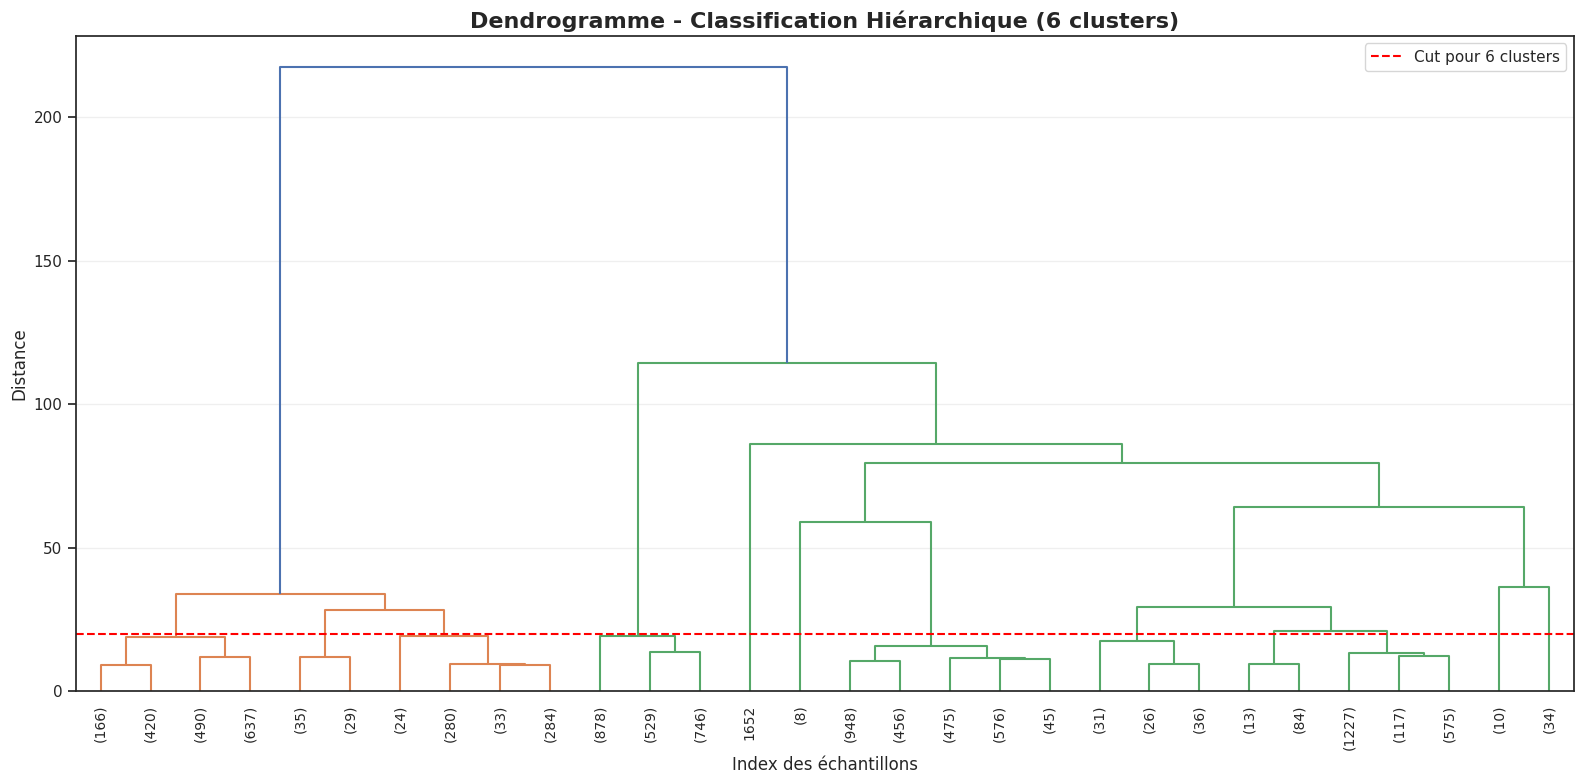

Distribution des 6 clusters:
1    2398
2    2153
3    2508
4    2109
5      44
6       1
Name: count, dtype: int64


In [215]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Standardiser les données
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Calculer la matrice de liens
linkage_matrix = linkage(X_scaled, method='ward')

# =========================
# DENDROGRAMME
# =========================
plt.figure(figsize=(16, 8))

dendrogram(
    linkage_matrix,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90,
    leaf_font_size=10,
)

# 🔴 CUT LINE POUR 6 CLUSTERS
plt.axhline(y=20, color='red', linestyle='--', label='Cut pour 6 clusters')

plt.title('Dendrogramme - Classification Hiérarchique (6 clusters)', fontsize=16, fontweight='bold')
plt.xlabel('Index des échantillons', fontsize=12)
plt.ylabel('Distance', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# =========================
# 6 CLUSTERS
# =========================
clusters = fcluster(linkage_matrix, t=6, criterion='maxclust')

print("Distribution des 6 clusters:")
print(pd.Series(clusters).value_counts().sort_index())

In [216]:
score = silhouette_score(X_scaled, clusters)
print("Silhouette Score :", score)

Silhouette Score : 0.659651924279686


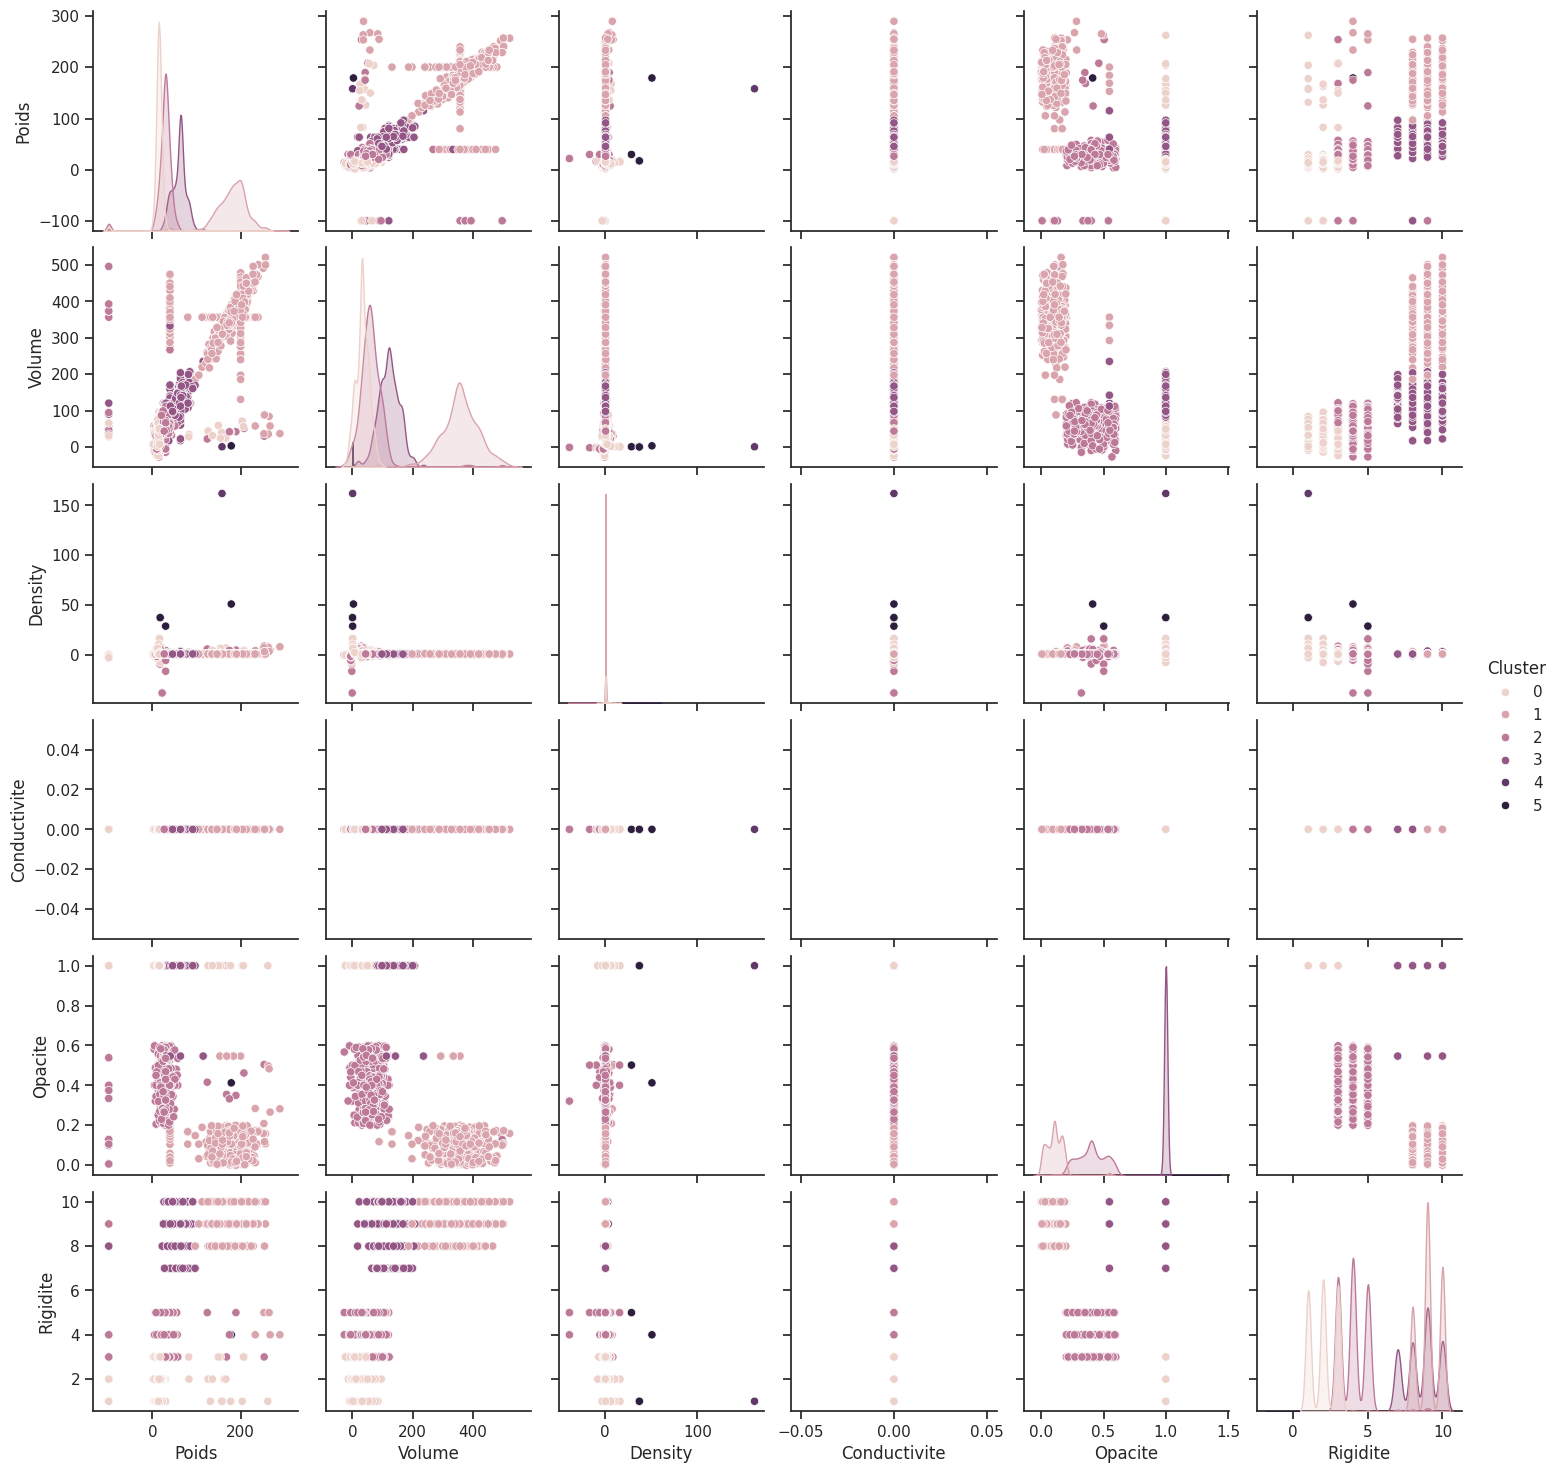

In [217]:
sns.pairplot(df_clustered, hue="Cluster", vars=features)
plt.show()

code simple

# Module 4 : NLP

In [218]:
import pandas as pd
import numpy as np
import re
import string
import warnings
warnings.filterwarnings("ignore")

In [219]:
import nltk

# Téléchargement forcé
nltk.download('stopwords', quiet=False)
nltk.download('punkt', quiet=False)
nltk.download('punkt_tab', quiet=False)   # parfois nécessaire pour word_tokenize

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [220]:
import re
from nltk.corpus import stopwords
from nltk.stem.snowball import FrenchStemmer
from nltk.tokenize import word_tokenize

# ====================== CONFIGURATION ======================
stopwords_fr = set(stopwords.words("french"))

stopwords_domaine = {
    "lot", "dechet", "déchet", "type", "identifie", "identifié",
    "collecte", "collecté", "collectés", "provenance", "site",
    "source", "usine", "centre", "tri", "volume", "poids",
    "prix", "revente", "kg", "litre", "l", "origine",
    "rapport", "materiau", "matériau", "récupéré", "contenants",
    "bris", "feuilles", "cartons", "en", "de", "du", "la", "le", "les"
}

stopwords_total = stopwords_fr.union(stopwords_domaine)

stemmer = FrenchStemmer()

def nettoyer_texte(texte):
    texte = str(texte).lower()
    texte = texte.replace("œ", "oe")
    texte = re.sub(r"\d+", " ", texte)
    texte = re.sub(r"[^\w\s]", " ", texte)
    texte = re.sub(r"\s+", " ", texte).strip()
    return texte

def preprocess_nlp(texte):
    texte = nettoyer_texte(texte)
    tokens = word_tokenize(texte, language="french")

    tokens_clean = [
        stemmer.stem(mot)
        for mot in tokens
        if mot not in stopwords_total and len(mot) > 2
    ]

    return " ".join(tokens_clean)

# ====================== APPLICATION ======================
df["texte_clean"] = df["Rapport_Collecte"].apply(preprocess_nlp)

print("✅ Prétraitement NLP terminé avec succès !")
df[["Rapport_Collecte", "texte_clean", "Categorie"]].head(10)

✅ Prétraitement NLP terminé avec succès !


,Rapport_Collecte,texte_clean,Categorie
0,Lot de papier récupéré dans un site non rensei...,papi non renseign leg moyen soupl non conducte...,Papier
1,"Lot plastique à l'Usine A. Volume 64.7 L, poid...",plastiqu aspect indétermin rigid moyen aucun t...,Plastique
2,Bris de verre ou contenants en provenance de l...,verr mass non mesur dens rigid élev transparen...,Verre
3,Feuilles et cartons collectés au Centre de Tri...,mass total non mesur leg soupl opaqu conform s...,Papier
4,Déchet de type papier identifié à l'Usine B. V...,papi estim non mesur textur rigid non mesur tr...,Papier
5,Déchet plastique collecté à l'Usine B. Poids 3...,plastiqu rigid sem rigid non conducteur surfac...,Plastique
6,Déchets en verre identifiés lors d'une collect...,déchet verr identifi lor citoyen non conducteu...,Verre
7,Déchets en verre identifiés via la collecte ci...,déchet verr identifi vi citoyen non conducteur...,Verre
8,Feuilles et cartons collectés provenant de l'U...,proven mass total leg soupl opaqu mélang autr ...,Papier
9,Métal de récupération au centre de tri municip...,métal récuper municipal mass fort conduct rigi...,Métal


- Tokenisation + stopwords français + stopwords domaine + stemming

In [221]:
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem.snowball import FrenchStemmer
from nltk.tokenize import word_tokenize

stopwords_fr = set(stopwords.words("french"))

# Stopwords domaine : on supprime les mots spécifiques au projet.
stopwords_domaine = {
    "lot", "dechet", "déchet", "type", "identifie", "identifié",
    "collecte", "collecté", "collectés", "provenance", "site",
    "source", "usine", "centre", "tri", "volume", "poids",
    "prix", "revente", "kg", "litre", "l", "origine",
    "rapport", "materiau", "matériau"
}

stopwords_total = stopwords_fr.union(stopwords_domaine)

stemmer = FrenchStemmer()

def nettoyer_texte(texte):
    texte = str(texte).lower()
    texte = texte.replace("œ", "oe")
    texte = re.sub(r"\d+", " ", texte)
    texte = re.sub(r"[^\w\s]", " ", texte)
    texte = re.sub(r"\s+", " ", texte).strip()
    return texte

def preprocess_nlp(texte):
    texte = nettoyer_texte(texte)

    # Tokenisation : on découpe le texte en mots.
    tokens = word_tokenize(texte, language="french")

    tokens_clean = []
    for mot in tokens:

        # Stopwords français + domaine : on supprime les mots inutiles.
        if mot not in stopwords_total and len(mot) > 2:

            # Stemming : on réduit le mot à sa racine.
            mot_stem = stemmer.stem(mot)

            tokens_clean.append(mot_stem)

    return " ".join(tokens_clean)

df["texte_clean"] = df["Rapport_Collecte"].apply(preprocess_nlp)

df[["Rapport_Collecte", "texte_clean", "Categorie"]].head()

,Rapport_Collecte,texte_clean,Categorie
0,Lot de papier récupéré dans un site non rensei...,papi récuper non renseign leg moyen soupl non ...,Papier
1,"Lot plastique à l'Usine A. Volume 64.7 L, poid...",plastiqu aspect indétermin rigid moyen aucun t...,Plastique
2,Bris de verre ou contenants en provenance de l...,bris verr conten mass non mesur dens rigid éle...,Verre
3,Feuilles et cartons collectés au Centre de Tri...,feuill carton mass total non mesur leg soupl o...,Papier
4,Déchet de type papier identifié à l'Usine B. V...,papi estim non mesur textur rigid non mesur tr...,Papier


- SÉPARATION TRAIN / TEST

In [222]:

from sklearn.model_selection import train_test_split

X = df["texte_clean"]
y = df["Categorie"]

x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train :", x_train.shape)
print("Test  :", x_test.shape)
print(y_train.value_counts())

Train : (7370,)
Test  : (1843,)
Categorie
Plastique    2050
Verre        1907
Métal        1730
Papier       1683
Name: count, dtype: int64


- FONCTION D'ÉVALUATION

In [223]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

resultats = []

def evaluer_modele(nom_vectorisation, nom_modele, y_test, y_pred):
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="macro")
    rec = recall_score(y_test, y_pred, average="macro")
    f1 = f1_score(y_test, y_pred, average="macro")

    resultats.append({
        "Vectorisation": nom_vectorisation,
        "Modèle": nom_modele,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1
    })

    print("="*70)
    print(f"{nom_vectorisation} + {nom_modele}")
    print("="*70)
    print("Accuracy :", round(acc, 4))
    print("Precision:", round(prec, 4))
    print("Recall   :", round(rec, 4))
    print("F1-score :", round(f1, 4))
    print("\nClassification report:\n")
    print(classification_report(y_test, y_pred))
    print("\nMatrice de confusion:\n")
    print(confusion_matrix(y_test, y_pred))

-  BAG OF WORDS

In [224]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

bow_vectorizer = CountVectorizer()

X_train_bow = bow_vectorizer.fit_transform(x_train)
X_test_bow = bow_vectorizer.transform(x_test)

modeles_classiques = {
    "Naive Bayes Multinomial": MultinomialNB(),
    "Régression Logistique": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "LinearSVC": LinearSVC(class_weight="balanced"),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    )
}

for nom, modele in modeles_classiques.items():
    modele.fit(X_train_bow, y_train)
    y_pred = modele.predict(X_test_bow)
    evaluer_modele("Bag of Words", nom, y_test, y_pred)

Bag of Words + Naive Bayes Multinomial
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0

Classification report:

              precision    recall  f1-score   support

       Métal       1.00      1.00      1.00       433
      Papier       1.00      1.00      1.00       421
   Plastique       1.00      1.00      1.00       512
       Verre       1.00      1.00      1.00       477

    accuracy                           1.00      1843
   macro avg       1.00      1.00      1.00      1843
weighted avg       1.00      1.00      1.00      1843


Matrice de confusion:

[[433   0   0   0]
 [  0 421   0   0]
 [  0   0 512   0]
 [  0   0   0 477]]
Bag of Words + Régression Logistique
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0

Classification report:

              precision    recall  f1-score   support

       Métal       1.00      1.00      1.00       433
      Papier       1.00      1.00      1.00       421
   Plastique       1.00      1.00      1.00       512
 

- TF-IDF uni + bigrammes

In [225]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X_train_tfidf = tfidf_vectorizer.fit_transform(x_train)
X_test_tfidf = tfidf_vectorizer.transform(x_test)

for nom, modele in modeles_classiques.items():
    modele.fit(X_train_tfidf, y_train)
    y_pred = modele.predict(X_test_tfidf)
    evaluer_modele("TF-IDF uni+bigrammes", nom, y_test, y_pred)

TF-IDF uni+bigrammes + Naive Bayes Multinomial
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0

Classification report:

              precision    recall  f1-score   support

       Métal       1.00      1.00      1.00       433
      Papier       1.00      1.00      1.00       421
   Plastique       1.00      1.00      1.00       512
       Verre       1.00      1.00      1.00       477

    accuracy                           1.00      1843
   macro avg       1.00      1.00      1.00      1843
weighted avg       1.00      1.00      1.00      1843


Matrice de confusion:

[[433   0   0   0]
 [  0 421   0   0]
 [  0   0 512   0]
 [  0   0   0 477]]
TF-IDF uni+bigrammes + Régression Logistique
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0

Classification report:

              precision    recall  f1-score   support

       Métal       1.00      1.00      1.00       433
      Papier       1.00      1.00      1.00       421
   Plastique       1.00      1.00      

In [226]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 58.1 MB/s eta 0:00:00


CamemBert

In [227]:
from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report


In [228]:
model_st = SentenceTransformer("camembert-base")
X_train_emb = model_st.encode(x_train.tolist(), show_progress_bar=True)
X_test_emb = model_st.encode(x_test.tolist(), show_progress_bar=True)
modeles_classiques = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC()
}

for nom, modele in modeles_classiques.items():
    modele.fit(X_train_emb, y_train)
    y_pred = modele.predict(X_test_emb)

    print("===== ", nom, " =====")
    print(classification_report(y_test, y_pred))

config.json:   0%|          | 0.00/508 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

CamembertModel LOAD REPORT from: camembert-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/811k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Batches:   0%|          | 0/231 [00:00<?, ?it/s]

Batches:   0%|          | 0/58 [00:00<?, ?it/s]

=====  Logistic Regression  =====
              precision    recall  f1-score   support

       Métal       1.00      1.00      1.00       433
      Papier       1.00      1.00      1.00       421
   Plastique       1.00      1.00      1.00       512
       Verre       1.00      1.00      1.00       477

    accuracy                           1.00      1843
   macro avg       1.00      1.00      1.00      1843
weighted avg       1.00      1.00      1.00      1843

=====  SVM  =====
              precision    recall  f1-score   support

       Métal       1.00      1.00      1.00       433
      Papier       1.00      1.00      1.00       421
   Plastique       1.00      1.00      1.00       512
       Verre       1.00      1.00      1.00       477

    accuracy                           1.00      1843
   macro avg       1.00      1.00      1.00      1843
weighted avg       1.00      1.00      1.00      1843



- WORD2VEC

In [229]:
from gensim.models import Word2Vec

phrases_train = [texte.split() for texte in x_train]
phrases_test = [texte.split() for texte in x_test]

word2vec_model = Word2Vec(
    sentences=phrases_train,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4,
    sg=1,
    seed=42
)

def vectoriser_moyenne(tokens, modele, taille=100):
    vecteurs = []
    for mot in tokens:
        if mot in modele.wv:
            vecteurs.append(modele.wv[mot])

    if len(vecteurs) == 0:
        return np.zeros(taille)

    return np.mean(vecteurs, axis=0)

X_train_w2v = np.array([
    vectoriser_moyenne(tokens, word2vec_model, 100)
    for tokens in phrases_train
])

X_test_w2v = np.array([
    vectoriser_moyenne(tokens, word2vec_model, 100)
    for tokens in phrases_test
])

modeles_embeddings = {
    "Régression Logistique": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "LinearSVC": LinearSVC(class_weight="balanced"),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    )
}

for nom, modele in modeles_embeddings.items():
    modele.fit(X_train_w2v, y_train)
    y_pred = modele.predict(X_test_w2v)
    evaluer_modele("Word2Vec", nom, y_test, y_pred)

Word2Vec + Régression Logistique
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0

Classification report:

              precision    recall  f1-score   support

       Métal       1.00      1.00      1.00       433
      Papier       1.00      1.00      1.00       421
   Plastique       1.00      1.00      1.00       512
       Verre       1.00      1.00      1.00       477

    accuracy                           1.00      1843
   macro avg       1.00      1.00      1.00      1843
weighted avg       1.00      1.00      1.00      1843


Matrice de confusion:

[[433   0   0   0]
 [  0 421   0   0]
 [  0   0 512   0]
 [  0   0   0 477]]
Word2Vec + LinearSVC
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0

Classification report:

              precision    recall  f1-score   support

       Métal       1.00      1.00      1.00       433
      Papier       1.00      1.00      1.00       421
   Plastique       1.00      1.00      1.00       512
       Verre       1.00

- FASTTEXT

In [230]:
from gensim.models import FastText

fasttext_model = FastText(
    sentences=phrases_train,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4,
    sg=1,
    seed=42
)

X_train_fasttext = np.array([
    vectoriser_moyenne(tokens, fasttext_model, 100)
    for tokens in phrases_train
])

X_test_fasttext = np.array([
    vectoriser_moyenne(tokens, fasttext_model, 100)
    for tokens in phrases_test
])

for nom, modele in modeles_embeddings.items():
    modele.fit(X_train_fasttext, y_train)
    y_pred = modele.predict(X_test_fasttext)
    evaluer_modele("FastText", nom, y_test, y_pred)

FastText + Régression Logistique
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0

Classification report:

              precision    recall  f1-score   support

       Métal       1.00      1.00      1.00       433
      Papier       1.00      1.00      1.00       421
   Plastique       1.00      1.00      1.00       512
       Verre       1.00      1.00      1.00       477

    accuracy                           1.00      1843
   macro avg       1.00      1.00      1.00      1843
weighted avg       1.00      1.00      1.00      1843


Matrice de confusion:

[[433   0   0   0]
 [  0 421   0   0]
 [  0   0 512   0]
 [  0   0   0 477]]
FastText + LinearSVC
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0

Classification report:

              precision    recall  f1-score   support

       Métal       1.00      1.00      1.00       433
      Papier       1.00      1.00      1.00       421
   Plastique       1.00      1.00      1.00       512
       Verre       1.00

- TF-IDF + LinearSVC

In [231]:
from sklearn.pipeline import Pipeline

pipeline_nlp = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=1,
        max_df=0.9,
        sublinear_tf=True
    )),
    ("clf", LinearSVC(class_weight="balanced"))
])

pipeline_nlp.fit(x_train, y_train)

y_pred_final = pipeline_nlp.predict(x_test)

evaluer_modele("Pipeline TF-IDF", "LinearSVC final", y_test, y_pred_final)

Pipeline TF-IDF + LinearSVC final
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0

Classification report:

              precision    recall  f1-score   support

       Métal       1.00      1.00      1.00       433
      Papier       1.00      1.00      1.00       421
   Plastique       1.00      1.00      1.00       512
       Verre       1.00      1.00      1.00       477

    accuracy                           1.00      1843
   macro avg       1.00      1.00      1.00      1843
weighted avg       1.00      1.00      1.00      1843


Matrice de confusion:

[[433   0   0   0]
 [  0 421   0   0]
 [  0   0 512   0]
 [  0   0   0 477]]


- SAUVEGARDER LE MODÈLE

In [233]:
import joblib

joblib.dump(pipeline_nlp, "modele_nlp_tfidf_linearsvc1.pkl")
joblib.dump(preprocess_nlp, "fonction_preprocess_nlp.pkl")

print("Modèle sauvegardé avec succès.")

Modèle sauvegardé avec succès.


- CHARGER LE MODÈLE ET PRÉDIRE

In [235]:
modele_charge = joblib.load("modele_nlp_tfidf_linearsvc1.pkl")

def predire_categorie_nlp(texte):
    texte_clean = preprocess_nlp(texte)
    pred = modele_charge.predict([texte_clean])[0]

    texte_lower = texte.lower()

    if "aluminium" in texte_lower or "métal" in texte_lower:
        return "Métal"
    if "carton" in texte_lower or "papier" in texte_lower:
        return "Papier"
    if "plastique" in texte_lower:
        return "Plastique"
    if "verre" in texte_lower:
        return "Verre"

    return pred

print("canette métallique conductrice =>", predire_categorie_nlp("canette métallique conductrice"))
print("bouteille transparente cassante =>", predire_categorie_nlp("bouteille transparente cassante"))
print("carton journal feuille =>", predire_categorie_nlp("carton journal feuille"))
print("sachet plastique souple =>", predire_categorie_nlp("sachet plastique souple"))
print("bouteille transparente recyclée en verre =>", predire_categorie_nlp("bouteille transparente recyclée en verre"))
print("sac plastique souple utilisé pour emballage alimentaire =>", predire_categorie_nlp("sac plastique souple utilisé pour emballage alimentaire"))
print("boite en aluminium conductrice et rigide =>", predire_categorie_nlp("boite en aluminium conductrice et rigide"))
print("journal ancien en papier recyclé =>", predire_categorie_nlp("journal ancien en papier recyclé"))
print("film plastique léger et flexible =>", predire_categorie_nlp("film plastique léger et flexible"))
print("canette de soda en métal recyclable =>", predire_categorie_nlp("canette de soda en métal recyclable"))
print("bocal en verre cassable et transparent =>", predire_categorie_nlp("bocal en verre cassable et transparent"))
print("carton d’emballage épais et recyclable =>", predire_categorie_nlp("carton d’emballage épais et recyclable"))
print("feuille papier imprimée utilisée au bureau =>", predire_categorie_nlp("feuille papier imprimée utilisée au bureau"))
print("barquette plastique utilisée pour nourriture =>", predire_categorie_nlp("barquette plastique utilisée pour nourriture"))
print("pièce métallique conductrice lourde =>", predire_categorie_nlp("pièce métallique conductrice lourde"))
print("verre fragile utilisé pour les fenêtres =>", predire_categorie_nlp("verre fragile utilisé pour les fenêtres"))


predire_categorie_nlp("bouteille claire fragile recyclée")

canette métallique conductrice => Métal
bouteille transparente cassante => Verre
carton journal feuille => Papier
sachet plastique souple => Plastique
bouteille transparente recyclée en verre => Verre
sac plastique souple utilisé pour emballage alimentaire => Plastique
boite en aluminium conductrice et rigide => Métal
journal ancien en papier recyclé => Papier
film plastique léger et flexible => Plastique
canette de soda en métal recyclable => Métal
bocal en verre cassable et transparent => Verre
carton d’emballage épais et recyclable => Papier
feuille papier imprimée utilisée au bureau => Papier
barquette plastique utilisée pour nourriture => Plastique
pièce métallique conductrice lourde => Métal
verre fragile utilisé pour les fenêtres => Verre


'Verre'

# Module 5 :  Pipeline Multimodal

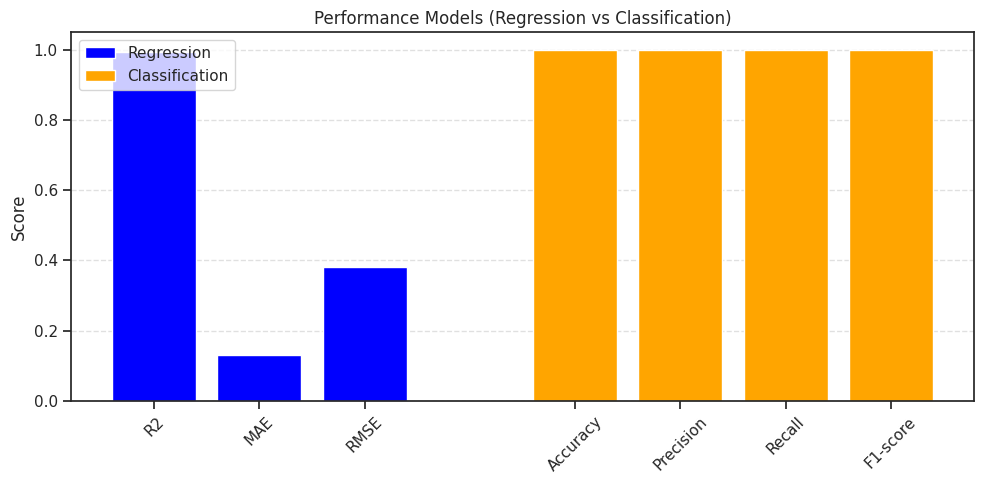

In [236]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ===============================
# 1) REGRESSION METRICS
# ===============================
reg_labels = ["R2", "MAE", "RMSE"]
reg_values = [
    r2_score(y_test_reg, y_pred_cat),
    mean_absolute_error(y_test_reg, y_pred_cat),
    np.sqrt(mean_squared_error(y_test_reg, y_pred_cat))
]

# ===============================
# 2) CLASSIFICATION METRICS
# ===============================
clf_labels = ["Accuracy", "Precision", "Recall", "F1-score"]
clf_values = [
    accuracy_score(y_test, y_pred_final),
    precision_score(y_test, y_pred_final, average="weighted", zero_division=0),
    recall_score(y_test, y_pred_final, average="weighted", zero_division=0),
    f1_score(y_test, y_pred_final, average="weighted", zero_division=0)
]

# ===============================
# 3) PLOT (2 GROUPS CLEAR)
# ===============================
plt.figure(figsize=(10,5))

x1 = np.arange(len(reg_labels))
x2 = np.arange(len(clf_labels)) + len(reg_labels) + 1

plt.bar(x1, reg_values, color="blue", label="Regression")
plt.bar(x2, clf_values, color="orange", label="Classification")

plt.xticks(list(x1) + list(x2), reg_labels + clf_labels, rotation=45)

plt.title("Performance Models (Regression vs Classification)")
plt.ylabel("Score")
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.legend()
plt.tight_layout()
plt.show()

In [237]:
# ==============================
# MULTIMODAL : Numérique + Texte avec CatBoost
# Target : Prix_Revente
# ==============================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from catboost import CatBoostRegressor

# 1) Colonnes
num_cols = ["Poids", "Volume", "Conductivite", "Opacite", "Rigidite"]
text_col = "Rapport_Collecte"   # بدليها إذا اسم colonne textuelle مختلف
target = "Prix_Revente"

# 2) Préparer data
df_multi = df.dropna(subset=num_cols + [text_col, target]).copy()

X = df_multi[num_cols + [text_col]]
y = df_multi[target]

# 3) Train/Test
X_train, X_test, y_train, y_test_multi = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4) CatBoost multimodal
cat_multi = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function="RMSE",
    random_state=42,
    verbose=0
)

# colonne texte
text_features = [text_col]

cat_multi.fit(
    X_train,
    y_train,
    text_features=text_features
)

# 5) Prediction
y_pred_multi = cat_multi.predict(X_test)

# 6) Metrics
r2_multi = r2_score(y_test_multi, y_pred_multi)
mae_multi = mean_absolute_error(y_test_multi, y_pred_multi)
rmse_multi = np.sqrt(mean_squared_error(y_test_multi, y_pred_multi))

print("===== Résultats CatBoost Multimodal =====")
print("R2   :", r2_multi)
print("MAE  :", mae_multi)
print("RMSE :", rmse_multi)

===== Résultats CatBoost Multimodal =====
R2   : 0.9795941821415359
MAE  : 0.2679653445458515
RMSE : 0.7215319503265019


In [238]:
print("===== Comparaison =====")
print("CatBoost numérique R2 :", r2_score(y_test_reg, y_pred_cat))
print("CatBoost multi R2     :", r2_multi)

print("CatBoost numérique RMSE :", np.sqrt(mean_squared_error(y_test_reg, y_pred_cat)))
print("CatBoost multi RMSE     :", rmse_multi)

===== Comparaison =====
CatBoost numérique R2 : 0.9942824296124415
CatBoost multi R2     : 0.9795941821415359
CatBoost numérique RMSE : 0.38168645823019426
CatBoost multi RMSE     : 0.7215319503265019


In [239]:
if r2_multi > r2_score(y_test_reg, y_pred_cat):
    print(" Le modèle multimodal améliore la performance.")
else:
    print(" Le modèle multimodal n'améliore pas la performance.")

 Le modèle multimodal n'améliore pas la performance.


- SHAP pour le modèle multimodale

In [240]:
# =====================================================
# 7) Analyse SHAP pour l’explicabilité du modèle multimodal
# Modèle : CatBoost Multimodal Numérique + Texte
# =====================================================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from catboost import Pool

# 1) Créer un Pool CatBoost pour les données de test
test_pool = Pool(
    X_test,
    label=y_test_multi,
    text_features=[text_col]
)

# 2) Calcul des valeurs SHAP
shap_values = cat_multi.get_feature_importance(
    test_pool,
    type="ShapValues"
)

# CatBoost retourne :
# - les colonnes SHAP des features
# - la dernière colonne = valeur de base
shap_feature_values = shap_values[:, :-1]
base_values = shap_values[:, -1]

# 3) Transformer en DataFrame
shap_df = pd.DataFrame(
    shap_feature_values,
    columns=X_test.columns
)

# 4) Importance moyenne absolue des variables
shap_importance = shap_df.abs().mean().sort_values(ascending=False)

print("===== Importance SHAP des variables =====")
print(shap_importance)

===== Importance SHAP des variables =====
Rigidite            2.095263
Opacite             1.388598
Poids               1.381276
Volume              0.423682
Rapport_Collecte    0.150132
Conductivite        0.000000
dtype: float64


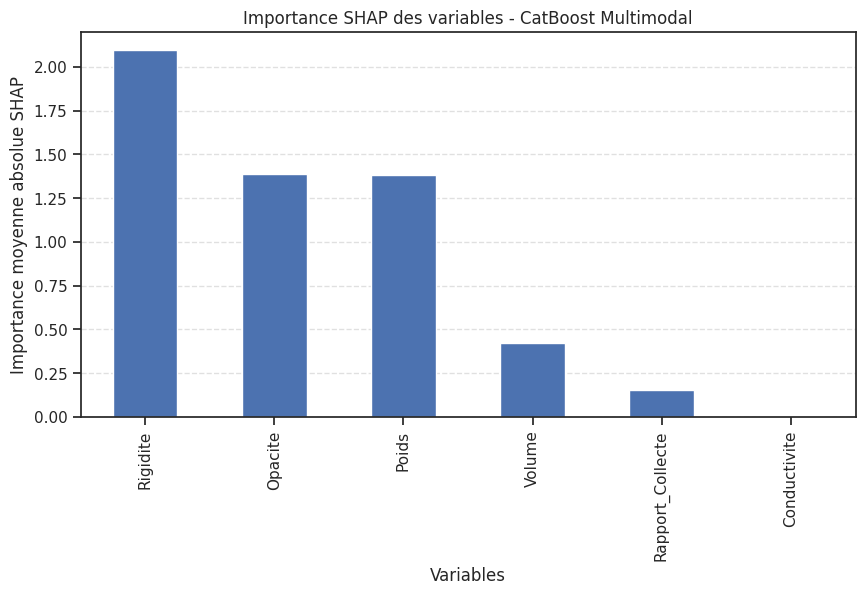

In [241]:
# =====================================================
# Graphique global : importance SHAP
# =====================================================

plt.figure(figsize=(10, 5))

shap_importance.plot(kind="bar")

plt.title("Importance SHAP des variables - CatBoost Multimodal")
plt.xlabel("Variables")
plt.ylabel("Importance moyenne absolue SHAP")
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()

In [242]:
# =====================================================
# Explication locale d'une prédiction
# =====================================================

i = 0  # numéro de l'observation à expliquer

print("===== Observation expliquée =====")
print(X_test.iloc[i])

print("\nValeur réelle :", y_test_multi.iloc[i])
print("Prédiction modèle :", y_pred_multi[i])
print("Valeur de base SHAP :", base_values[i])

local_shap = shap_df.iloc[i].sort_values(key=abs, ascending=False)

print("\n===== Contribution SHAP locale =====")
print(local_shap)

===== Observation expliquée =====
Poids                                                       27.426235
Volume                                                      21.480788
Conductivite                                                      0.0
Opacite                                                      0.547309
Rigidite                                                          5.0
Rapport_Collecte    Plastique de tri sélectif en provenance de l'U...
Name: 8629, dtype: object

Valeur réelle : 2.742623462576655
Prédiction modèle : 2.527168942773263
Valeur de base SHAP : 5.693610668134983

===== Contribution SHAP locale =====
Rigidite           -1.616209
Poids              -1.001274
Volume             -0.408923
Opacite            -0.126970
Rapport_Collecte   -0.013066
Conductivite        0.000000
Name: 0, dtype: float64


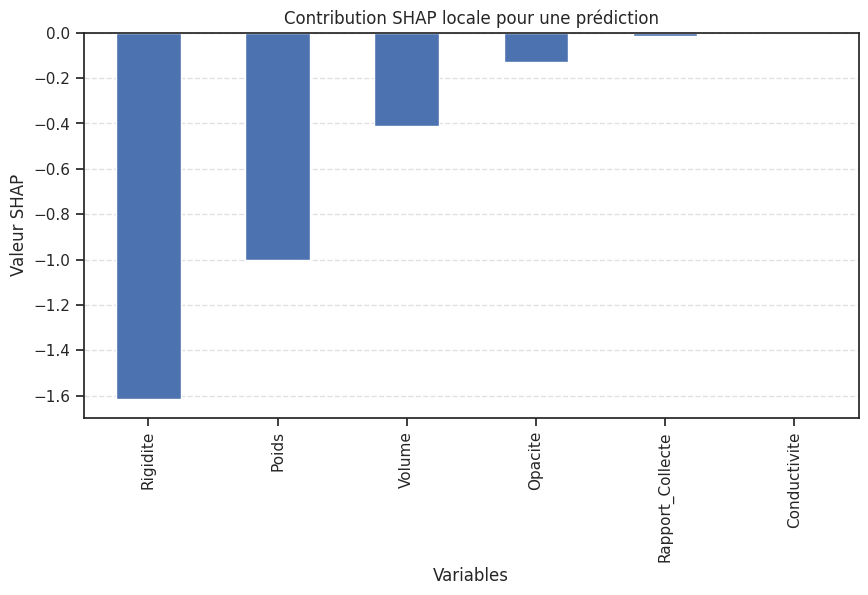

In [243]:
# =====================================================
# Graphique local : contribution des variables
# =====================================================

plt.figure(figsize=(10, 5))

local_shap.plot(kind="bar")

plt.title("Contribution SHAP locale pour une prédiction")
plt.xlabel("Variables")
plt.ylabel("Valeur SHAP")
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()

L’analyse SHAP permet d’expliquer le comportement du modèle multimodal CatBoost. Elle montre quelles variables influencent le plus la prédiction du Prix_Revente. Une valeur SHAP positive augmente la prédiction du prix, tandis qu’une valeur SHAP négative la diminue. Cette analyse rend le modèle plus interprétable, surtout parce qu’il utilise à la fois des données numériques comme Poids, Volume, Conductivite, Opacite, Rigidite et une donnée textuelle comme Rapport_Collecte.

# Module 6 : MLOps

In [244]:
# ============================================================
# SAUVEGARDE DES 3 MODÈLES POUR FASTAPI
# Classification + Régression + NLP
# ============================================================

import os
import joblib
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostRegressor
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score, f1_score, r2_score, mean_squared_error

# Créer dossier models
os.makedirs("models", exist_ok=True)

# ============================================================
# 1) MODÈLE CLASSIFICATION : prédire Categorie
# ============================================================

features_classification = [
    "Poids", "Volume", "Conductivite", "Opacite", "Rigidite", "Source"
]

X_class = df[features_classification]
y_class = df["Categorie"]

numeric_features = ["Poids", "Volume", "Conductivite", "Opacite", "Rigidite"]
categorical_features = ["Source"]

preprocessor_class = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numeric_features),

    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features)
])

modele_classification = Pipeline([
    ("preprocessor", preprocessor_class),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    ))
])

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42, stratify=y_class
)

modele_classification.fit(X_train_c, y_train_c)

y_pred_c = modele_classification.predict(X_test_c)

print("===== Classification =====")
print("Accuracy :", accuracy_score(y_test_c, y_pred_c))
print("F1-score :", f1_score(y_test_c, y_pred_c, average="macro"))

joblib.dump(modele_classification, "models/modele_classification.pkl")


# ============================================================
# 2) MODÈLE RÉGRESSION : prédire Prix_Revente
# ============================================================

features_regression = [
    "Poids", "Volume", "Conductivite", "Opacite", "Rigidite", "Source", "Categorie"
]

X_reg = df[features_regression]
y_reg = df["Prix_Revente"]

categorical_features_reg = ["Source", "Categorie"]

preprocessor_reg = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numeric_features),

    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features_reg)
])

modele_regression = Pipeline([
    ("preprocessor", preprocessor_reg),
    ("model", CatBoostRegressor(
        iterations=1000,
        learning_rate=0.1,
        depth=6,
        random_seed=42,
        verbose=0
    ))
])

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

modele_regression.fit(X_train_r, y_train_r)

y_pred_r = modele_regression.predict(X_test_r)

print("\n===== Régression =====")
print("R2 :", r2_score(y_test_r, y_pred_r))
print("RMSE :", np.sqrt(mean_squared_error(y_test_r, y_pred_r)))

joblib.dump(modele_regression, "models/modele_regression.pkl")


print("\n✅ Les 2 modèles sont enregistrés avec succès dans le dossier models/")

===== Classification =====
Accuracy : 1.0
F1-score : 1.0

===== Régression =====
R2 : 0.9811380716133039
RMSE : 0.6936998647851773

✅ Les 2 modèles sont enregistrés avec succès dans le dossier models/
